# DUV Computational Lithography Pipeline



## The Abbe model

The **Abbe method** is a way to compute the image formed by an *extended, partially coherent* light source — the situation in real lithography, where illumination arrives from a range of angles rather than a single point.

**Core idea:** treat the extended source as a collection of independent point sources. Each point emits light at one angle (a tilted plane wave) and is **mutually incoherent** with every other point — meaning different source points cannot interfere with each other. So the recipe is:

1. For each source point, compute a full **coherent** image (tilt the illumination, pass through the mask and the NA-limited lens).
2. Take that image's **intensity** $|E|^2$.
3. **Sum the intensities** across all source points, weighted by each point's brightness.

$$I(x,y) = \sum_k w_k \,\big|E_k(x,y)\big|^2$$

**The one rule that defines it:** add **intensities, not fields**. Because the source points are incoherent, their optical powers add directly; summing the complex fields instead would wrongly let them interfere. This intensity-summation is the mathematical signature of partial coherence.

**Why it's used:** it's conceptually simple, physically exact (it *is* the ground-truth model of partial coherence), and cost scales linearly with the number of source points. Its trade-off is that changing the mask means redoing every source point's pass — which is why for heavy OPC/ILT inner loops it's later replaced by the Hopkins/SOCS formulation (precompute the optics once, reuse across many masks). Abbe is built first as the reference; Hopkins is added as an accelerator and validated against it.

**In one line:** Abbe = loop over incoherent source points, do a coherent imaging pass for each, and sum their intensities to get the partially-coherent aerial image.

## Libraries

`xp` is our array module. S

Everything downstream imports `xp`, never `numpy` directly.

`to_cpu` copies array back to host memory as a NumPy array, so it can be handed to plotting code (matplotlib only understands host NumPy arrays,

In [1]:
# --- Backend selection -------------------------------------------------------
# To move to GPU later, change this one block. Nothing else should import numpy.
import numpy as _np

BACKEND = "cupy"   # "numpy" | "cupy" | "jax"

if BACKEND == "numpy":
    import numpy as xp
    def to_cpu(a):           # bring an xp array back to host numpy for plotting
        return _np.asarray(a)
elif BACKEND == "cupy":
    import cupy as xp                      # noqa
    def to_cpu(a):
        return xp.asnumpy(a)
elif BACKEND == "jax":
    import jax.numpy as xp                 # noqa
    def to_cpu(a):
        return _np.asarray(a)
else:
    raise ValueError(BACKEND)

import matplotlib.pyplot as plt
print(f"Backend = {BACKEND}, xp = {xp.__name__}")


CDTYPE = xp.complex64    # global complex precision
RDTYPE = xp.float32      # matching real dtype

Backend = cupy, xp = cupy


## 1 · Physical constants & global grid

Everything is in **SI units (metres)**. We fix the physics first, then *derive*
the grid sampling from it — the grid is never "just pixels."

The being said, the grid size of the wafer that we will work on is set here. The reticle and wafer size (in "pixels") is set here as

* 512 - Fast mode
* 1024 - Prototyping mode
* 2028 - Release mode

The computation time will increase exponentially as we move from fast to release mode.

**ArF system parameters (idealized):**

| Symbol | Meaning | Value |
|--------|---------|-------|
| λ | ArF wavelength | 193 nm |
| NA | projection numerical aperture | 0.85 (dry) |
| M | reduction ratio (reticle→wafer) | 4× |
| N | grid size (power of 2) | 512, 1024, 2048 supported by this sim |

The wafer-plane sampling `dx_wafer` and the pupil radius in pixels are derived

from λ, NA and N below.

<br>

$\sin\theta_m = m\lambda/p$

<br>

- **$m$** — the *diffraction order* (an integer: 0, ±1, ±2, …). It labels the discrete directions the mask splits light into. $m=0$ is the undeflected beam; $m=\pm1$ are the first orders that carry the pattern information, and so on.
- **$\lambda$** — the *wavelength* of the illuminating light. Here $\lambda = 193$ nm (the ArF excimer line).
- **$p$** — the *pitch* of the periodic mask feature: one full period (line + space) of the grating. In the notebook $p = 250$ nm at the wafer.

The lens can only collect angles up to its NA. By definition

$\mathrm{NA} = n\sin\theta_{max}$

the sine of the largest ray angle the aperture accepts ($n=1$ dry). Any ray steeper than $\theta_{max}$ misses the lens and is lost.

<br>

**Combining the two gives the cutoff:**
$$\sin\theta = \lambda f \le \mathrm{NA} \quad\Longrightarrow\quad f \le \frac{\mathrm{NA}}{\lambda}$$

The lens passes every spatial frequency up to $\mathrm{NA}/\lambda$ and rejects the rest — exactly a low-pass filter.

<br>

**In the notebook this cutoff *is* the pupil radius: diffraction orders inside the circle pass, orders outside are clipped.**

<br>

**Consequence — the resolution limit.** Reproducing a grating needs at least the 0th and ±1st orders through the pupil. Below that pitch the pattern-carrying orders fall outside the lens and the feature cannot be imaged.

<br>


**Pupil radius** — the projection lens acts as a low-pass filter, passing spatial frequencies only up to `NA/λ`.Converted into grid units via the frequency step `df = 1/FOV_WAFER`, this cutoff lands at 17.6 pixels from the center of the frequency plane. Anything beyond it (higher diffraction orders) is clipped and lost. The "1024 max" is the Nyquist limit (N//2), so the pupil comfortably fits inside the grid.


###1.1 Derivation — pupil radius in pixels

**1. Physical cutoff frequency.** The lens passes spatial frequencies only up to

<br>

$$f_c = \frac{\mathrm{NA}}{\lambda}$$
With $\mathrm{NA}=0.85$, $\lambda=193\,\text{nm}$:

<br>

$$f_c = \frac{0.85}{193\times10^{-9}\,\text{m}} \approx 4.40\times10^{6}\ \text{cycles/m} = 4.40\ \text{cyc/µm}$$

<br>

**2. Frequency-grid spacing.** The image is sampled on an $N$-point grid spanning a physical field of view FOV_WAFER

We don't have a continuous image — we have samples over a finite window. The aerial image is stored as $N$ samples spanning a physical length $L = \mathrm{FOV\_WAFER}$, spaced $\mathrm{dx} = L/N$ apart. The FFT is the only Fourier transform available for this: it takes $N$ real-space samples and returns $N$ frequency samples.

A finite window can only "see" whole numbers of cycles. A discrete transform implicitly treats the window as one period of a repeating pattern. The only sinusoids that fit cleanly into a window of length $L$ are those completing an integer number of cycles across it: 0, 1, 2, … full cycles. Their frequencies are
$$f_k = \frac{k}{L}, \qquad k = 0, 1, 2, \dots$$
A wave at, say, 1.5 cycles across the window wouldn't be periodic in $L$, so the FFT simply has no bin for it — it lands between bins. The allowed frequencies are therefore *quantised*, and the gap between consecutive ones is

<br>

$$\mathrm{d}f = f_{k+1}-f_k = \frac{1}{L} = \frac{1}{\mathrm{FOV\_WAFER}}.$$

<br>

A discrete FFT of such a grid has frequency bins spaced by

<br>

$$\mathrm{d}f = \frac{1}{N\,\mathrm{d}x_\text{wafer}} = \frac{1}{\mathrm{FOV\_WAFER}}$$

<br>

since $N\,\mathrm{d}x_\text{wafer} = \mathrm{FOV\_WAFER}$. With $\mathrm{FOV\_WAFER}=4\,\text{µm}$:

<br>

$$\mathrm{d}f = \frac{1}{4\times10^{-6}\,\text{m}} = 2.5\times10^{5}\ \text{cycles/m} = 0.25\ \text{cyc/µm}$$

<br>

Note $\mathrm{d}f$ depends only on the physical FOV — **not** on $N$. Raising $N$ adds finer real-space sampling and more padding, not more diffraction orders.

<br>

**3. Convert the cutoff to pixels.** The pupil radius is the cutoff frequency measured in frequency-bins (pixels):

<br>

$$r_\text{pupil} = \frac{f_c}{\mathrm{d}f} = \frac{\mathrm{NA}/\lambda}{1/\mathrm{FOV\_WAFER}} = \frac{\mathrm{NA}\cdot\mathrm{FOV\_WAFER}}{\lambda}$$

<br>

$$r_\text{pupil} = \frac{4.40\times10^{6}}{2.5\times10^{5}} \approx 17.6\ \text{px}$$

<br>

**4. Fits inside the grid.** The FFT resolves frequencies up to the Nyquist limit at $\pm N/2$ pixels. The assertion `pupil_radius_px < N//2` guarantees the pupil sits inside the grid.
* At `RESOLUTION="fast"`, $N=512 \Rightarrow N/2=256$;
* At `"RESOLUTION=final"`, $N=2048 \Rightarrow N/2=1024$

Either way $17.6 \ll N/2$, so the pupil comfortably fits.

**Key point:** which diffraction orders pass is set by the *physical* condition $f \le \mathrm{NA}/\lambda$. $N$ only changes how many pixels sample that fixed pupil, never its physical size.

In [2]:
# @title 1.2 Physical constants & global grid (SET MASK RESOLUTION HERE)
from dataclasses import dataclass, replace

# --- ArF system constants (idealized, all SI / metres) ----------------------
WAVELENGTH    = 193e-9    # m   ArF excimer line
NA            = 0.85      # operating projection NA (settable, see bound below)
NA_MAX_DRY    = 0.93      # hardware ceiling for a dry ArF lens; immersion ~1.35
M_REDUCTION   = 4         # reticle is 4x larger than wafer

# --- Sampling resolution (numerical knob — does NOT change the physical scene)
# N only controls how finely we sample. Raising it = smoother FFTs + more
# padding, NOT more diffraction orders inside the NA. FIX(#9): whether grating
# order m is collected is the physical condition m/pitch <= NA/lambda —
# independent of BOTH N and FOV_WAFER.
RESOLUTION = "final"                                    # "fast"|"normal"|"final"
N = {"fast": 512, "normal": 1024, "final": 2048}[RESOLUTION]

# --- Physical scene (authored in metres — independent of N) ------------------
FOV_WAFER     = 4e-6      # m   field of view at the wafer
GRATING_PITCH = 250e-9    # m   demo grating pitch at the WAFER (single source of truth)

# --- Derived sampling (pixels are derived, never authored) -------------------
dx_wafer   = FOV_WAFER / N
dx_reticle = dx_wafer * M_REDUCTION          # reticle features are M x larger

# Pupil radius: lens passes spatial frequencies up to NA/lambda.
# df depends only on the physical FOV (= 1/FOV_WAFER), so the pupil radius in
# pixels tracks FOV and NA — NOT N. FIX(#9): raising FOV does NOT admit more
# orders — it shrinks df, putting more PIXELS across the same pupil (finer
# frequency sampling). Which orders pass is m/pitch <= NA/lambda, full stop.
df_wafer        = 1.0 / (N * dx_wafer)       # = 1 / FOV_WAFER
pupil_radius_px = (NA / WAVELENGTH) / df_wafer

# --- Sanity / physical bounds ------------------------------------------------
assert NA <= NA_MAX_DRY, f"NA={NA} exceeds dry-ArF hardware max {NA_MAX_DRY}"
assert pupil_radius_px < N//2, "Pupil overfills grid — raise N or shrink FOV_WAFER."

print(f"RESOLUTION      = {RESOLUTION} (N={N})")
print(f"dx_wafer        = {dx_wafer*1e9:.3f} nm/pixel")
print(f"dx_reticle      = {dx_reticle*1e9:.3f} nm/pixel")
print(f"grating pitch   = {GRATING_PITCH*1e9:.1f} nm  ({GRATING_PITCH/dx_wafer:.1f} px at wafer)")
print(f"pupil radius    = {pupil_radius_px:.1f} px (of {N//2} max)")
print(f"Rayleigh k1=0.5 half-pitch = {0.5*WAVELENGTH/NA*1e9:.1f} nm")

RESOLUTION      = final (N=2048)
dx_wafer        = 1.953 nm/pixel
dx_reticle      = 7.812 nm/pixel
grating pitch   = 250.0 nm  (128.0 px at wafer)
pupil radius    = 17.6 px (of 1024 max)
Rayleigh k1=0.5 half-pitch = 113.5 nm


## 2 · The `Field` container & FFT convention

`Field` bundles the complex array with everything a stage needs to interpret it:

* the sampling `dx`
* the `wavelength`, and
* the `domain` (`'real'` or `'pupil'`).

Each stage **asserts** the domain it expects — this catches "applied a real-space
op to a pupil-space array" instantly.

`to_pupil` / `to_real` are the **only** place `np.fft` is called.

The convention <br>(centred spectra via `fftshift`, unitary `norm='ortho'`) is fixed here once.

### 2.1 `to_pupil` vs `to_real`

`to_pupil`

**FFT:** Forward 2-D discrete Fourier transform (`fft2`)

**Purpose:** Propagates the field from the object/mask plane to the far field (Fraunhofer diffraction). Under Fraunhofer propagation, the field in the lens pupil is the Fourier transform of the field leaving the mask — so real → pupil *is* a forward FT. Each mask spatial frequency becomes a diffraction order at a definite pupil position, ready for the NA aperture to clip.

**Continuous theory:**

$$U_{\text{pupil}}(f_x,f_y)=\iint U_{\text{real}}(x,y)\,e^{-i2\pi(f_xx+f_yy)}\,dx\,dy$$

**Discrete (unitary) form:**

$$U[k_x,k_y]=\frac{1}{N}\sum_{x,y} u[x,y]\,e^{-i2\pi(k_xx+k_yy)/N}$$

`to_real`

**FFT:** Inverse 2-D discrete Fourier transform (`ifft2`)

**Purpose:** Propagates the (pupil-filtered) field back from the pupil to the image/wafer plane. The lens performs a second Fourier transform; the net object → image relationship is an inverse FT of the pupil field. This reconstructs the complex aerial image from the diffraction orders the pupil let through.

**Continuous theory:**

$$U_{\text{real}}(x,y)=\iint U_{\text{pupil}}(f_x,f_y)\,e^{+i2\pi(f_xx+f_yy)}\,df_x\,df_y$$

**Discrete (unitary) form:**

$$u[x,y]=\frac{1}{N}\sum_{k_x,k_y} U[k_x,k_y]\,e^{+i2\pi(k_xx+k_yy)/N}$$

---

*The only difference between the two kernels is the sign of the exponent — $-i2\pi$ forward, $+i2\pi$ inverse — which encodes the propagation direction.*

**Continuous transforms** — standard Fourier-optics. The two continuous integrals are the ordinary 2-D forward and inverse Fourier transforms, exactly as they appear in Goodman's Introduction to Fourier Optics.


### 2.2  What the shift-FFT-shift sandwich does

The reason for the `ifftshift(...)` → transform → `fftshift(...)` wrapping is a **coordinate-origin mismatch** between how we store the data and where the FFT expects the origin.

**The mismatch**
- **How we store arrays:** we want the zero point — DC / optical axis / grid centre — in the *middle* of the array, at index `N/2`. That's the natural way to view an image or a pupil (centre of the frame = centre of the physics).
- **What the FFT assumes:** `fft2` expects the origin at index `[0,0]` (the top-left corner), and it produces output with the zero-frequency also at `[0,0]`.

Feed a centre-origin array straight into `fft2` and every result comes out with a checkerboard of sign flips / half-array wraparound — technically correct but scrambled, and any pupil mask you apply lands on the wrong pixels.

**The fix, in three steps**

<br>

$$\text{centred input} \;\xrightarrow{\ \text{ifftshift}\ }\; \text{corner-origin} \;\xrightarrow{\ \text{fft2}\ }\; \text{corner-origin spectrum} \;\xrightarrow{\ \text{fftshift}\ }\; \text{centred spectrum}$$

<br>

1. **`ifftshift(f.data)`** — moves the centre-origin to the corner, so the array is now in the layout `fft2` expects. (`ifftshift` is used, not `fftshift`, because it's the correct inverse for both even and odd `N` — it's the true "un-shift".)
2. **`fft2(..., norm='ortho')`** — the actual transform. `norm='ortho'` makes it unitary (scales by $1/\sqrt{N^2}$) so energy is preserved and forward/inverse are symmetric.
3. **`fftshift(...)`** — moves the zero-frequency of the *result* back to the array centre, giving a spectrum with DC in the middle — ready to display and, crucially, to multiply by the centred circular pupil mask.


### 2.3 `intensity(f)` and `Field` Class

`intensity(f)` function turns the complex electromagnetic field into the real, physically measurable **intensity**, and hands it back as a plain NumPy array for plotting or metrics.

<br>


**The physics: `|E|²`.** Throughout the pipeline the field `f.data` is a complex array — it carries both amplitude *and* phase (`complex64`), because diffraction and imaging depend on phase. But no detector, resist, or eye responds to the complex field directly; they respond to **intensity**, the squared magnitude of the field:

<br>

$$I = |E|^2 = E \cdot E^{*} = (\text{Re}\,E)^2 + (\text{Im}\,E)^2$$

<br>

> [!NOTE] This is the time-averaged optical power hitting the wafer. Taking `|·|²` collapses amplitude+phase down to a single real, non-negative number per pixel — and discards the phase, which is why this step is done `*only*` at the very end (the wafer), never mid-pipeline.

<br>

`intensity` is the single point where the simulation stops treating light as a complex wave and starts treating it as measurable power on the wafer — `|E|²`, brought home to NumPy.

In [3]:
# @title 2.4 The Field container & FFT/IFFT transforms
# source = array of shape (P, 3): rows of (kx, ky, weight)
#   kx, ky : source-point position in PUPIL coordinates, normalized so the
#            projection-NA edge = 1.0  (so kx²+ky² = σ² for a point at radius σ)
#   weight : relative intensity of that point (enables graded/apodized fills + SMO)
# σ-constructors (conventional/annular/dipole) EMIT this object.
# A free-form DOE / SMO writes this object directly. Same type either way.


@dataclass
class Field:
    data: object        # complex array (xp), shape (N, N)
    dx: float           # real-space sampling, metres
    wavelength: float   # metres
    domain: str         # 'real' | 'pupil'

    def copy_with(self, **kw):
        return replace(self, **kw)

# --- Centralised FFT helpers (the ONLY fft calls in the codebase) -----------
def to_pupil(f):
    "Real space -> pupil (far field). Centred, unitary."
    assert f.domain == "real", f"to_pupil expects real, got {f.domain}"
    spec = xp.fft.fftshift(xp.fft.fft2(xp.fft.ifftshift(f.data), norm="ortho"))
    return f.copy_with(data=spec, domain="pupil")

def to_real(f):
    "Pupil -> real space. Inverse of to_pupil."
    assert f.domain == "pupil", f"to_real expects pupil, got {f.domain}"
    img = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(f.data), norm="ortho"))
    return f.copy_with(data=img, domain="real")

def intensity(f):
    "|E|^2 as host numpy, for measurement/plotting."
    return to_cpu(xp.abs(f.data)**2)

### 2.5 References — FFT-based Abbe forward model + gradient SMO

1. **The FFT forward model = standard Abbe / Fourier-optics imaging**

> In the Fraunhofer regime the pupil-plane field is the Fourier transform of the field
leaving the mask, and the image is the inverse transform of the pupil-filtered
spectrum. This is Abbe's diffraction theory of imaging; the FFT is its discrete
implementation. Partial coherence is handled by summing over source points.

- **E. Abbe (1873)**, "Beiträge zur Theorie des Mikroskops und der mikroskopischen
  Wahrnehmung," *Archiv für mikroskopische Anatomie* **9**, 413–468.
  → Original theory: image formation by diffraction (object spectrum → pupil →
  image). Foundation of the two-transform imaging chain.

- **H. H. Hopkins (1951)**, "The concept of partial coherence in optics," *Proc. R.
  Soc. Lond. A* **208**(1093), 263–277. DOI: 10.1098/rspa.1951.0158
  → Establishes the partial-coherence framework for extended sources — the basis for
  the σ / effective-source model.

- **J. W. Goodman**, *Introduction to Fourier Optics*, 4th ed., W. H. Freeman (2017).
  → Standard textbook derivation that Fraunhofer diffraction is a Fourier transform
  and a lens performs an optical FT — the direct justification for `fft2`/`ifft2` as
  the propagation operators and the pupil as an NA/λ low-pass filter.

- **A. K. Wong**, *Optical Imaging in Projection Microlithography*, SPIE Press (2005).
  DOI: 10.1117/3.612961
  → Applies Fourier-optics imaging specifically to projection lithography
  (illumination, pupil, partial coherence, aerial image). Lithography-specific
  reference for the exact model implemented here.

<br>

2. **The Abbe source-point-sum method (what `forward()` does)**

> Abbe's method computes the partially-coherent aerial image as the incoherent sum of
intensities from each mutually-incoherent source point, each imaged coherently via
an FFT — exactly the `forward()` loop (illuminator → reticle → pupil-FFT → |·|²,
summed over source points).

- Verified statement of the method (Springer, *Recent advances in computational
  lithography technology*, 2025): the Abbe imaging formula "considers spatial images
  as the incoherent sum of imaging results for each source point," each source
  point's contribution "calculated independently and then summed." Confirms the
  incoherent-sum-of-FFTs structure.

- Verified cost characterization (stacked-pupil-shift-operator paper, 2009): "Abbe's
  method uses Fast Fourier transform (FFT) algorithm to compute each component image
  arising from an effective point source … the speed of Abbe's method solely depends
  on the number of illumination source points." Matches this project's P-source-point
  cost scaling.

- **Hopkins/SOCS alternative** — the TCC eigendecomposition (SOCS) is the accelerated
  method the project cites as future work; the literature treats Abbe as the accuracy
  reference against which SOCS/Hopkins are matched (e.g. "Hopkins versus Abbe: a
  lithography simulation matching study," Proc. SPIE 4691, 2002).

<br>

3. **Gradient-based Source–Mask Optimization on this forward model**

> The inverse problem minimizes a pattern-error functional over mask (and source)
variables; the gradient is derived analytically through the imaging chain and a
smooth (sigmoid) resist threshold, then descended. This is the project's
`smo()` / `pattern_error` design.

- **A. Poonawala and P. Milanfar (2007)**, "Mask design for optical microlithography
  — an inverse imaging problem," *IEEE Trans. Image Process.* **16**(3), 774–788,
  March 2007. DOI: 10.1109/TIP.2006.891332
  → The canonical gradient-based ILT/OPC paper: poses mask design as an inverse
  problem, uses a **sigmoid** to make the resist threshold differentiable, and
  derives the analytic gradient for steepest descent. Direct template for the mask
  step here.

- **A. Poonawala and P. Milanfar (2007)**, "A pixel-based regularization approach to
  inverse lithography," *Microelectronic Engineering* **84**(12), 2837–2852.
  DOI: 10.1016/j.mee.2007.02.005
  → Pixel-based mask optimization with regularization (the pixel/continuous-relaxation
  view used here; also motivates manufacturability penalties).

- **X. Ma and G. R. Arce (2009)**, "Pixel-based simultaneous source and mask
  optimization for resolution enhancement in optical lithography," *Optics Express*
  **17**(7), 5783–5793. DOI: 10.1364/OE.17.005783
  → The direct reference for **simultaneous SMO**: co-optimizing a *pixelated source*
  and *pixelated mask* by gradient methods on the partially-coherent model. Closest
  published analogue to this project's alternating mask-step / source-step engine and
  its freeform (pixelated) source. (Note: this paper uses a Fourier-series-expansion /
  SOCS approximation of the partially-coherent system; this project uses the direct
  Abbe sum. Same optimization principle, different image-model accelerator.)

- **A. E. Rosenbluth et al. (2002)**, "Optimum mask and source patterns to print a
  given shape," *J. Microlith. Microfab. Microsyst. (JM3)* **1**(1), 13–30, April
  2002. DOI: 10.1117/1.1448500  (first presented: Proc. SPIE 4346, 2001,
  DOI: 10.1117/12.435748)
  → The foundational SMO paper: introduces joint source+mask optimization to print a
  target and notes optimized sources/masks "fall well outside the realm of known
  design forms" — the conceptual origin of freeform source–mask co-design.

- **X. Ma and G. R. Arce (2010)**, *Computational Lithography*, Wiley Series in Pure
  and Applied Optics, John Wiley & Sons.
  → Book-length treatment tying together the FFT forward model, partial coherence,
  OPC/PSM, and gradient SMO. Best single umbrella reference — covers both halves of
  this project in one place.

4. Mapping each project component to its citation

| Project component | Established by |
|---|---|
| `to_pupil`/`to_real` = FFT propagation; pupil = NA/λ low-pass | Goodman (2017); Abbe (1873) |
| Partial coherence via σ / effective source of points | Hopkins (1951); Wong (2005) |
| `forward()` = incoherent sum of per-source-point FFT images | Abbe method (Springer 2025; stacked-pupil-shift 2009); Wong (2005) |
| Sigmoid resist + analytic gradient; mask step (OPC/ILT) | Poonawala & Milanfar (2007, IEEE TIP) |
| Pixelated / continuous mask relaxation + manufacturability penalties | Poonawala & Milanfar (2007, Microelec. Eng.) |
| Simultaneous source+mask gradient optimization; freeform source | Ma & Arce (2009, Opt. Express); Rosenbluth et al. (2002) |
| Whole-project umbrella (imaging + SMO) | Ma & Arce, *Computational Lithography* (2010) |

<br>

* The forward model is the standard discrete implementation of Abbe/Hopkins (partially-coherent Fourier-optics imaging (Abbe 1873; Hopkins 1951; Goodman 2017; > Wong 2005),

* The optimizer is the established gradient-based ILT/SMO method built on a differentiable sigmoid resist and analytic gradients over that model (Poonawala & Milanfar 2007; Rosenbluth et al. 2002; Ma & Arce 2009, 2010).





## 3 · Visualisation helpers

We want each stage's wavefront to be *viewable*. A complex field has two parts,
so we show **amplitude** (or intensity) and **phase** side by side, plus an
optional log view for the pupil (where energy spans many orders of magnitude).

### 3.1 `show_field`

Shows a **complex `Field` as two panels side by side: amplitude and phase** — the two independent halves of a complex wave. Used at intermediate stages where phase still matters (before the wafer).

- **Amplitude panel** plots $|E|$ per pixel, from `xp.abs(f.data)`. With `log_amp=True` it instead plots $\log_{10}(|E| + \varepsilon)$ (a small floor $\varepsilon$ avoids $\log 0$), compressing a huge dynamic range so faint diffraction orders become visible next to the bright DC.
- **Phase panel** plots $\arg(E) = \operatorname{atan2}(\operatorname{Im}E, \operatorname{Re}E)$, from `xp.angle(f.data)`, on a cyclic colormap fixed to $[-\pi, \pi]$ so the phase wrap is displayed honestly.

Math executed: $|E| = \sqrt{(\operatorname{Re}E)^2 + (\operatorname{Im}E)^2}$ and $\arg(E)=\operatorname{atan2}(\operatorname{Im}E,\operatorname{Re}E)$.



### 3.2 `show_intensity`

Shows a **single intensity panel** — the physically measurable quantity at the wafer plane, where phase has been discarded. This is the "what the resist sees" view.

It calls `intensity(f)`, i.e. it computes $I = |E|^2$ per pixel, then displays it. The optional `extent_um` argument labels the axes in microns (mapping the pixel grid to the physical field of view) so the image reads in real wafer dimensions rather than pixel indices.

Math executed: $I = |E|^2 = (\operatorname{Re}E)^2 + (\operatorname{Im}E)^2$.



### 3.3 `show_source_pupil`

Shows the **effective source as a continuous pupil intensity map** — where the illumination power sits in the pupil (conventional disc, annular ring, dipole poles, or a free-form SMO-designed DOE). It renders the source as an *image*, not a scatter, so any source type looks the same way.

The source is a list of points `(kx, ky, weight)` in normalized pupil coordinates (NA edge = radius 1). The function **bins those points onto a 2-D pupil grid**, accumulating `weight` into each cell — a weighted 2-D histogram:
$$\text{img}[i,j] = \sum_{p \,\in\, \text{cell}(i,j)} w_p$$
So each grid cell holds the total power fraction landing in that patch of pupil. It then overlays the σ = 1 NA-edge circle ($\cos\theta,\sin\theta$) for reference. The `interp="nearest"` default draws one solid square per point (honest for a binary aperture where every "on" point has equal weight); smoothing is avoided because it would invent intermediate brightness that isn't physically there.

The bin count is auto-inferred from the source's own spacing (the smallest gap between unique `kx` values → one bin per source point) so the display faithfully matches the source's real sampling.

<br>

>Ideally the pupil would be a intensity map. but we are showing a iris because in real life, the last intensity is flat and cannot be shaped.

<br>

`show_source_pupil` works in `(kx, ky)` coordinates *normalized so the projection-NA edge = 1.0*. The source points satisfy $k_x^2 + k_y^2 = \sigma^2$, and the plotted dashed circle is the "σ = 1" NA edge. The axes literally run from −1.1 to +1.1 in σ units.


### 3.4 `show_source_pupil_ax`

**Identical computation to `show_source_pupil`, but drawn into a caller-supplied axis** (`ax`) instead of creating and showing its own figure. It exists so the source pupil can be placed as one panel inside a larger multi-panel figure (e.g. a "DOE before / after" comparison in the SMO section).

Same math: the weighted 2-D histogram $\text{img}[i,j] = \sum_{p \in \text{cell}(i,j)} w_p$ over the `(kx, ky, weight)` points, plus the NA-edge circle overlay. The only differences are plumbing: it returns the image handle and optionally attaches a colorbar, leaving figure creation and layout to the caller.

In [4]:
# @title 3.5 Visualisation helpers
def show_field(f, title="", log_amp=False):
    "Plot amplitude/intensity and phase of a complex Field."
    a = to_cpu(xp.abs(f.data))
    p = to_cpu(xp.angle(f.data))
    amp = _np.log10(a + a.max()*1e-6 + 1e-12) if log_amp else a

    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    im0 = ax[0].imshow(amp, cmap="inferno")
    ax[0].set_title(f"{title}  |  {'log amplitude' if log_amp else 'amplitude'}  ({f.domain})")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(p, cmap="twilight", vmin=-_np.pi, vmax=_np.pi)
    ax[1].set_title(f"{title}  |  phase (rad)")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)
    for a_ in ax:
        a_.set_xticks([]); a_.set_yticks([])
    plt.tight_layout(); plt.show()

def show_intensity(f, title="", extent_um=None):
    "Single intensity panel — used for the wafer plane."
    I = intensity(f)
    plt.figure(figsize=(5.2, 4.6))
    ext = None
    if extent_um is not None:
        ext = [-extent_um/2, extent_um/2, -extent_um/2, extent_um/2]
    plt.imshow(I, cmap="viridis", extent=ext)
    plt.title(title)
    plt.colorbar(fraction=0.046, label="intensity (a.u.)")
    if ext:
        plt.xlabel("µm"); plt.ylabel("µm")
    plt.tight_layout(); plt.show()

def show_source_pupil(src, title="Effective source (DOE pupil)",
                      bins=None, interp="nearest", cmap="inferno"):
    """Render a source as a continuous pupil INTENSITY MAP (not a scatter).
    Bins the (kx, ky, weight) points onto a pupil grid and shows it as an image.
    Works for any source — parametric σ-shapes or a free-form / SMO-designed DOE.

    bins   : pupil-grid resolution for display. None = infer from the source's
             own sampling (one bin per source point ≈ faithful). Raise for a
             smoother display ONLY if the source itself is finely sampled.
    interp : imshow interpolation. 'nearest' (default) shows one solid square
             per source point — HONEST for a binary aperture where every "on"
             point has the same weight. 'gaussian' or 'bilinear' smooth
             between bins and INVENT intermediate brightness that isn't
             actually there — a binary source rendered with 'gaussian' looks
             like a smooth "flame" of varying intensity, which will mislead
             anyone reading the plot. Only use smoothing when the source is
             genuinely multi-level (mirror-array, source_levels ≥ 5).
    """
    kx, ky, w = src[:, 0], src[:, 1], src[:, 2]
    if bins is None:
        ukx = _np.unique(_np.round(kx, 6))
        if len(ukx) > 1:
            pitch = _np.min(_np.diff(ukx))
            bins = int(round(2.0 / pitch)) + 1
        else:
            bins = 64
    edges = _np.linspace(-1.0, 1.0, bins + 1)
    img, _, _ = _np.histogram2d(ky, kx, bins=[edges, edges], weights=w)  # row=ky
    plt.figure(figsize=(5.0, 4.6))
    plt.imshow(img, extent=[-1, 1, -1, 1], origin="lower",
               cmap=cmap, interpolation=interp)
    th = _np.linspace(0, 2 * _np.pi, 200)
    plt.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5, label="NA edge (σ=1)")
    plt.gca().set_aspect("equal"); plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.title(f"{title}  ({len(src)} pts, {bins}×{bins} grid)")
    plt.xlabel("kx (σ)"); plt.ylabel("ky (σ)"); plt.legend(loc="upper right")
    plt.colorbar(fraction=0.046, label="power fraction"); plt.tight_layout(); plt.show()

def show_source_pupil_ax(src, ax, title="DOE AFTER  (designed source)",
                         bins=None, interp="nearest", cmap="inferno",
                         add_colorbar=True):
    """Rasterized DOE pupil image drawn INTO an existing axis `ax`
    (for use inside a multi-panel figure). Mirrors show_source_pupil but
    does not create or show its own figure."""
    kx, ky, w = src[:, 0], src[:, 1], src[:, 2]
    if bins is None:
        ukx = _np.unique(_np.round(kx, 6))
        bins = int(round(2.0/_np.min(_np.diff(ukx)))) + 1 if len(ukx) > 1 else 64
    edges = _np.linspace(-1.0, 1.0, bins + 1)
    img, _, _ = _np.histogram2d(ky, kx, bins=[edges, edges], weights=w)  # row=ky
    im = ax.imshow(img, extent=[-1, 1, -1, 1], origin="lower",
                   cmap=cmap, interpolation=interp)
    th = _np.linspace(0, 2*_np.pi, 200)
    ax.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5)
    ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(f"{title}  ({len(src)} pts, {bins}×{bins})")
    ax.set_xlabel("kx (σ)"); ax.set_ylabel("ky (σ)")
    if add_colorbar:
        import matplotlib.pyplot as _plt
        _plt.colorbar(im, ax=ax, fraction=0.046, label="power fraction")
    return im

### 3.6 · Targets & error metrics

The **target** is the pattern we want printed (the ideal print equals the drawn mask geometry). `pattern_error` is the differentiable MSE loss SMO minimizes; `edge_error_px` is a human-readable area-mismatch in pixels.

In [5]:
# --- Targets and error metrics for optimization ------------------------------
# The target is the pattern we WANT printed at the wafer (binary, 1 = resist).
# We build it from the same reticle library: the "ideal" printed result is just
# the mask pattern itself (what we'd get from a perfect, aberration-free system).
#
# Two error measures:
#   pattern_error  : mean-squared difference between printed and target (the loss
#                    SMO minimizes; smooth, differentiable).
#   edge_error     : an EPE-like proxy = total area mismatch along edges, in
#                    pixels^2, for human-readable "how far off" reporting.

def make_target(name):
    """Target printed pattern (binary, host numpy) for a library reticle name.
    The ideal print equals the drawn mask geometry."""
    m = make_reticle(name)
    return (to_cpu(xp.abs(m)) > 0.5).astype(_np.float64)

def pattern_error(printed, target):
    "Mean-squared pattern error (the differentiable SMO loss)."
    d = printed - target
    return float(_np.mean(d * d))

def edge_error_px(printed, target, level=0.5):
    "Area mismatch (XOR) between thresholded print and target, in pixels."
    p = (printed >= level).astype(_np.float64)
    return float(_np.sum(_np.abs(p - target)))

def show_compare(target, printed_before, printed_after, title=""):
    "Three-panel: target | printed before SMO | printed after SMO."
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.6))
    for a_, img, t in zip(
        ax, [target, printed_before, printed_after],
        ["Target (desired print)", "Printed BEFORE SMO", "Printed AFTER SMO"]):
        im = a_.imshow(img, cmap="gray_r", vmin=0, vmax=1)
        a_.set_title(t); a_.set_xticks([]); a_.set_yticks([])
    eb = edge_error_px(printed_before, target)
    ea = edge_error_px(printed_after,  target)
    plt.suptitle(f"{title}   edge mismatch: {eb:.0f}px → {ea:.0f}px "
                 f"({100*(eb-ea)/max(eb,1):.0f}% better)", y=1.02)
    plt.tight_layout(); plt.show()

## 4 · The laser cabinet output (idealized ArF source)

>[!NOTE] For this pipeline everything upstream of the illuminator is treated as **ideal**.



The cabinet delivers a clean, monochromatic, spatially-uniform wavefront. We still
characterise it the way you would on a real tool — spectrum and beam profile — so
the notebook documents what "ideal" means here.

The two graphs below are **illustrative characterisation** of the source, not the
propagating field itself:
- **Spectrum:** a narrow line at 193 nm. Real ArF lasers are line-narrowed to a
  fraction of a pm; we show an idealized narrow Gaussian and mark its FWHM.
- **Beam profile:** a flat-top intensity cross-section (ideal uniform illumination).

In [6]:
def make_source_field():
    "Ideal cabinet output: uniform amplitude, flat phase, at the reticle plane."
    data = xp.ones((N, N), dtype=CDTYPE)   # unit amplitude, zero phase
    return Field(data=data, dx=dx_reticle, wavelength=WAVELENGTH, domain="real")

### 4.1 Photon energy of the 193 nm ArF laser

The formula is the **Planck–Einstein relation**, written in terms of wavelength and then converted from joules to electron-volts:
$$E_\text{photon} = \frac{hc}{\lambda} \times \frac{1}{q_e}$$

**Term by term (matching the code):**

- $h = 6.626\times10^{-34}\ \text{J·s}$ — Planck's constant.
- $c = 2.998\times10^{8}\ \text{m/s}$ — speed of light. Together $hc/\lambda$ gives the photon energy in **joules**.
- $\lambda = 193\times10^{-9}\ \text{m}$ — the ArF exposure wavelength.
- $q_e = 1.602\times10^{-19}\ \text{C}$ — the elementary charge. Dividing joules by this converts the energy into **electron-volts** (1 eV = the energy of one electron moved through 1 volt = $1.602\times10^{-19}$ J).

> [!NOTE] 6.42 eV is a high per-photon energy — this is what makes 193 nm "deep-UV" and gives it the resolution and the photochemistry that drives the CAR (chemically amplified resist). It's above the bond energies of many organic materials, which is both why it exposes resist efficiently and why the optics must be fused silica / CaF₂ (ordinary glass absorbs strongly at this energy). The eV form is the convenient unit for comparing against material band gaps and bond energies.

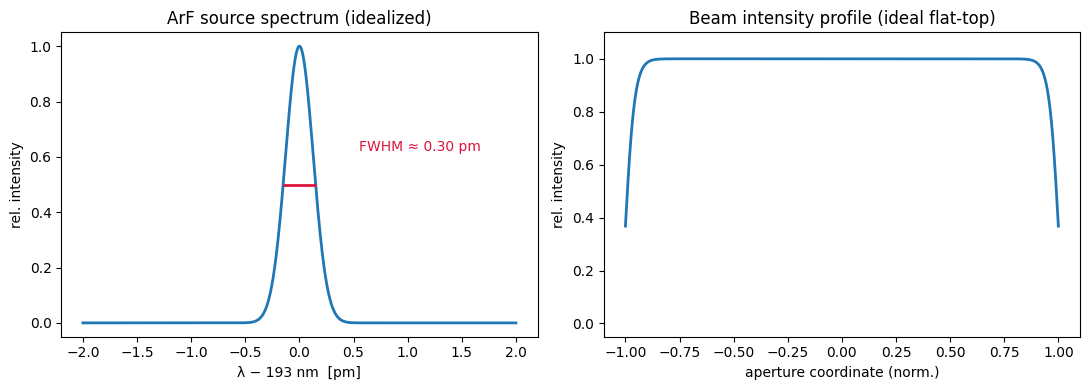

Centre wavelength : 193.000 nm
Spectral FWHM     : 0.3 pm (idealized, line-narrowed)
Photon energy     : 6.425 eV


In [7]:
# @title 4.2 Laser cabinet output (193nm ArF 3pm FPHW with Flat power spread head)
def plot_source_characterisation():
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    # --- (a) Spectrum: narrow line at 193 nm, FWHM marked --------------------
    lam0_pm = 193_000.0                      # 193 nm expressed in picometres
    fwhm_pm = 0.3                            # ~0.3 pm idealized line-narrowed width
    sigma   = fwhm_pm / (2*_np.sqrt(2*_np.log(2)))
    lam = _np.linspace(lam0_pm - 2, lam0_pm + 2, 2000)
    S   = _np.exp(-0.5*((lam - lam0_pm)/sigma)**2)
    ax[0].plot(lam - lam0_pm, S, lw=2)
    ax[0].hlines(0.5, -fwhm_pm/2, fwhm_pm/2, color="crimson", lw=2)
    ax[0].annotate(f"FWHM ≈ {fwhm_pm:.2f} pm", xy=(0, 0.5),
                   xytext=(0.55, 0.62), color="crimson")
    ax[0].set_title("ArF source spectrum (idealized)")
    ax[0].set_xlabel("λ − 193 nm  [pm]"); ax[0].set_ylabel("rel. intensity")

    # --- (b) Beam profile: ideal flat-top -----------------------------------
    x = _np.linspace(-1, 1, 1000)
    n = 20                                   # super-Gaussian order -> flat top
    beam = _np.exp(-(x**2)**n)
    ax[1].plot(x, beam, lw=2)
    ax[1].set_title("Beam intensity profile (ideal flat-top)")
    ax[1].set_xlabel("aperture coordinate (norm.)"); ax[1].set_ylabel("rel. intensity")
    ax[1].set_ylim(-0.05, 1.1)

    plt.tight_layout(); plt.show()
    E_photon = 6.626e-34 * 2.998e8 / 193e-9 / 1.602e-19
    print("Centre wavelength : 193.000 nm")
    print(f"Spectral FWHM     : {fwhm_pm} pm (idealized, line-narrowed)")
    print(f"Photon energy     : {E_photon:.3f} eV")

plot_source_characterisation()

## 5 · Pipeline stages (pure functions)

Each stage is `field_out = stage(field_in, params)`. Minimal working physics:
- **illuminator** — applies the source/beam envelope (here: pass-through ideal
  flat-top; the partial-coherence *source shape* will live in its params later).
- **reticle** — multiplies by a mask transmission (real diffraction starts here).
- **projection_lens** — Fourier transform → clip by the NA pupil → inverse
  transform. This is the diffraction-limited imaging step.
- **wafer** — takes intensity; resist threshold/contour comes later.

> Partial coherence is deliberately **absent**: it's the orchestrator that would
> call `reticle`→`projection_lens` once per source point and sum intensities. The
> hook `partial_coherent_image()` is stubbed in section 7.

### 5.1 illuminator simulator

**Stage 1 of the pipeline.** It applies **one source point** to the incoming field by tilting the incident plane wave to the angle `(kx, ky)`. A tilted plane wave is what a single off-axis illumination point produces, and it is the basic unit the partial-coherence (Abbe) sum is built from.

**What it does physically.** In Fourier optics, tilting a plane wave in real space = shifting its spectrum in the pupil. So instead of hitting the mask straight-on, the light arrives at an angle, `which slides all the diffraction orders sideways in the pupil.` Different source points push different orders into (or out of) the NA aperture — this is exactly how off-axis illumination (annular, dipole, etc.) improves resolution.

**The math it executes.** It multiplies the field by a linear phase ramp:
$$f_\text{out}(x,y) = f_\text{in}(x,y)\cdot e^{\,i2\pi(f_x x + f_y y)}$$
where the spatial frequency of the tilt is
$$(f_x, f_y) = \frac{\mathrm{NA}}{M\lambda}\,(k_x, k_y)$$
`(kx, ky)` are the source point's position in normalized pupil coords (NA edge = 1). The factor `NA/(M·λ)` is the *reticle-side* frequency: because the system demagnifies by M (≈4×), the mask-side illumination NA is NA/M.

**The on-axis shortcut.** If `kx == ky == 0` (centre source point, no tilt), it returns the field unchanged — an ideal flat-top pass-through.

**Why the loop lives elsewhere.** This function applies only *one* point. `forward()` calls it once per source point and sums the resulting intensities — keeping the loop outside makes this stage a pure function (SMO/autodiff-friendly). `params` is a reserved slot (polarization, etc.), currently unused.

In [8]:
# @title 5.1.1 Stage 1: Illuminator
# --- Stage 1: Illuminator ----------------------------------------------------
# Applies ONE source point as a tilt (a linear phase ramp across the field).
# The SET of source points lives in the `source` object (see source constructors);
# forward() iterates the set and calls this once per point. Keeping the loop in
# forward() — not here — is what keeps this stage pure and SMO-ready.
#
# Convention: (kx, ky) are in pupil coordinates normalized so the projection-NA
# edge = 1.0. A point at radius sigma therefore satisfies kx^2 + ky^2 = sigma^2.
# The matching spatial frequency AT THE RETICLE PLANE is (NA/(M*lambda))*(kx,ky):
# an M x reduction system demagnifies the illumination cone to NA/M on the mask
# side. After the lens's x M demagnification these tilts correspond to
# (NA/lambda)*(kx,ky) at the wafer — which is what the pupil bookkeeping uses.

# Precompute real-space coordinate axes once (metres), centred on the grid.
_coord = (xp.arange(N) - N // 2) * dx_reticle          # 1-D axis, metres
_YY, _XX = xp.meshgrid(_coord, _coord, indexing="ij")  # 2-D real-space coords

def illuminator(f, kx=0.0, ky=0.0, params=None):
    """Tilt the incident plane wave by one source point (kx, ky).

    kx, ky : this source point's position in pupil coords (NA edge = 1.0).
             (0, 0) = on-axis = no tilt (ideal flat-top pass-through).
    params : reserved (polarization, etc.); schema TBD, unused for now.

    A tilted plane wave is exp(i 2pi (fx x + fy y)) with spatial frequency
    (fx, fy) = (NA/(M*lambda)) * (kx, ky) at the reticle plane (the mask-side
    illumination NA is NA/M). xp-clean: pure functional phase ramp, no
    in-place mutation, so it traces under JAX autodiff.
    """
    assert f.domain == "real"
    if kx == 0.0 and ky == 0.0:
        return f.copy_with(data=f.data * 1.0)          # on-axis: untouched
    # FIX(#1): _coord is built from dx_reticle, so the ramp must use the
    # RETICLE-side frequency NA/(M*lambda) — not the wafer-side NA/lambda.
    # The old value made every tilt M x too steep (sigma_eff = M*sigma): a
    # kx=1 point shifted the spectrum ~4 pupil radii instead of exactly 1,
    # so any source point with sigma > 1/M = 0.25 threw its 0th order
    # outside the pupil, corrupting every partially-coherent result.
    fx = (NA / (M_REDUCTION * WAVELENGTH)) * kx
    fy = (NA / (M_REDUCTION * WAVELENGTH)) * ky
    ramp = xp.exp(2j * xp.pi * (fx * _XX + fy * _YY))
    return f.copy_with(data=f.data * ramp)

### 5.2 Reticle (mask) Simulator

 This stage introduces the **photomask**: the patterned plate that imprints the design onto the light. Two functions — one *builds* a demo mask, the other *applies* any mask to the field.

<br>

`make_demo_mask()`

<br>

Builds a **binary amplitude grating** (equal lines and spaces) to use as a test pattern. "Binary amplitude" means each pixel is either fully transmitting (1) or fully opaque (0) — a chrome-on-glass mask.

The pitch is defined **physically (250 nm at the wafer)**, never as a hardcoded pixel count, so the pattern stays 250 nm regardless of grid size N. The conversion:

$$\text{period_per_px} = \frac{\text{GRATING_PITCH}\times M}{\mathrm{dx\_reticle}} = \frac{\text{GRATING\_PITCH}}{\mathrm{dx\_wafer}}$$
The mask lives at the **reticle plane**, where features are M× larger (the lens demagnifies by M≈4×).

<br>

`reticle(f, mask)`

<br>

Applies a mask to the field — **this is where diffraction begins.** Under the thin-mask (Kirchhoff) approximation, a mask simply multiplies the incident field by its transmission function, pixel by pixel:

<br>

$$f_\text{out}(x,y) = f_\text{in}(x,y)\cdot t_\text{mask}(x,y)$$

<br>

Where the mask is opaque (t = 0) the field is zeroed; where it's clear (t = 1) the field passes. That abrupt spatial modulation is exactly what creates the diffraction orders that the projection lens will later filter.

`Transmission functions used in the reticle code`

Across the whole notebook the reticle uses **one transmission model: binary amplitude (chrome-on-glass)**. Every mask is a complex array (`complex64`) but the values used are only **0 and 1** — the complex type is there to carry phase *if* a phase-shift mask were added, but none of the built-in patterns use it.

The `complex64` dtype leaves the door open for transmission functions this code does *not* currently implement:

- **Phase-shift masks (PSM):** would use complex values like $t = e^{i\pi} = -1$ (alternating-aperture PSM) or an attenuated value like $t = 0.06\,e^{i\pi}$ (6% attenuated PSM). These modulate phase as well as amplitude to sharpen edges. Not used by any built-in pattern.
- **Grayscale / continuous transmission:** the SMO section can produce a continuous mask $t\in[0,1]$ during grayscale ILT, but its **default** output is re-binarized to strict {0,1} (the straight-through estimator), and the code comment stresses the deliverable is "ready for chrome-on-glass — no phase-shift, no attenuator, no grayscale."

In [9]:
# @title 5.2.1 Stage 2: Reticle (mask)

# --- Stage 2: Reticle (mask) ------------------------------------------------
def make_demo_mask():
    """Binary amplitude grating, pitch = GRATING_PITCH (defined at the wafer).
    The mask lives at the reticle plane, so the pitch in mask pixels uses
    dx_reticle. Built from the physical pitch — never a hardcoded pixel count —
    so it stays 250 nm regardless of N."""
    # pitch in reticle-plane pixels: wafer pitch scaled up by M, then / dx_reticle
    period_px = (GRATING_PITCH * M_REDUCTION) / dx_reticle      # = GRATING_PITCH/dx_wafer
    period_px = int(round(period_px))
    duty_px   = period_px // 2                                  # 1:1 lines:spaces

    m = xp.zeros((N, N), dtype=CDTYPE)
    c = N // 2
    half = N // 4                                              # patterned window half-width
    cols = xp.arange(N)
    line = ((cols % period_px) < duty_px)
    m[c-half:c+half, :] = line[None, :].astype(CDTYPE)
    m[:, :c-half] = 0; m[:, c+half:] = 0                       # restrict to central window
    return m

def reticle(f, mask):
    "Thin binary mask: multiply field by transmission. Diffraction begins here."
    assert f.domain == "real"
    assert mask.shape == f.data.shape
    return f.copy_with(data=f.data * mask)

### 5.3 Projection Lens

This stage models the projection lens, whose defining action is **band-limiting**: it can only collect diffraction orders that fall within its numerical aperture, and it discards everything outside. This is where the resolution limit physically lives.

<br>

`_pupil_mask(radius_px)`

<br>

Builds the **pupil aperture** — a circular binary mask in the frequency (pupil) plane that marks which spatial frequencies the lens passes.

It creates a grid of radial distance from the centre,

<br>

$$r(i,j) = \sqrt{(i - N/2)^2 + (j - N/2)^2}$$

<br>

then returns 1 where $r \le \text{radius\_px}$ and 0 outside — a filled disc of radius `radius_px` (= 17.6 px for this NA). Physically this circle is the boundary $f \le \mathrm{NA}/\lambda$: frequencies inside are collected, frequencies outside miss the lens. The result is computed once and stored as the module-level `PUPIL` so it isn't rebuilt every call.

<br>

`projection_lens(f, pupil=None)`

<br>

Performs **diffraction-limited imaging** in three steps — a Fourier transform, an aperture clip, and an inverse transform:

1. **`to_pupil(f)`** — forward-FFT the field to the pupil plane, giving the diffraction spectrum (each mask spatial frequency now sits at its pupil position).
2. **`spec.data * pupil`** — multiply by the pupil mask. This is the **NA low-pass filter**: orders inside the disc survive (×1), orders outside are zeroed (×0) and permanently lost. Physically, high-frequency detail that diffracts past the lens edge is thrown away.
3. **`to_real(spec)`** — inverse-FFT back to the wafer plane, yielding the **complex aerial image** (amplitude + phase) reconstructed from only the orders that got through.

>The net operation is the textbook Abbe two-step: $\text{FT} \to$ aperture $\to \text{FT}^{-1}$. Passing a mask through this is exactly what blurs sharp mask edges into the smooth aerial image — the missing high orders are the missing sharpness. If `pupil` is omitted it defaults to the standard NA disc, but a custom pupil can be passed to model defocus, aberrations, or apodization later.

In [10]:
# @title 5.3.1 Stage 3: Projection lens (NA-limited imaging)
# --- Stage 3: Projection lens (NA-limited imaging) --------------------------
def _pupil_mask(radius_px):
    yy, xx = xp.meshgrid(xp.arange(N) - N//2, xp.arange(N) - N//2, indexing="ij")
    rr = xp.sqrt(xx**2 + yy**2)
    return (rr <= radius_px).astype(RDTYPE)

PUPIL = _pupil_mask(pupil_radius_px)

def projection_lens(f, pupil=None):
    "Diffraction-limited imaging: FT -> clip by NA pupil -> inverse FT."
    assert f.domain == "real"
    if pupil is None:
        pupil = PUPIL
    spec = to_pupil(f)                                 # diffraction spectrum
    spec = spec.copy_with(data=spec.data * pupil)      # NA low-pass filter
    img  = to_real(spec)                               # complex aerial image
    return img



### 5.4 Wafer (without threshold)

returns the incoming field unchanged. Its only job is to let the per-stage walkthrough call intensity() and show ∣E∣2|E|^2
∣E∣2. The real model can't live here yet because it needs forward() and the dose normalization defined later.

redefination in section 8 overrides `def wafer(f, threshold=None)`



In [11]:
# --- Stage 4: Wafer (CAR resist) --------------------------------------------
# NOTE: the REAL resist threshold model (sigmoid dose-to-clear) is defined in
# §8 (Resist & SMO), because it needs forward() and the dose normalization. This
# placeholder keeps the per-stage walkthrough runnable; §8 overrides wafer().


def wafer(f, threshold=None):
    """Placeholder: returns the field so the per-stage view can show |E|^2.
    Overridden in §8 by the sigmoid resist model that maps intensity -> print."""
    assert f.domain == "real"
    return f

## 5a · Effective source constructors (σ / DOE)

The illuminator's tunable freedom is the **effective source shape** in the pupil. These constructors emit the free-form source object — an `(P,3)` array of `(kx, ky, weight)` points — that `forward()` iterates. Parametric σ-shapes (conventional/annular/dipole) are convenience builders; a free-form DOE or SMO writes the same object directly, so nothing downstream changes.

### 5a.1 `_source_grid` and `_emit` — the two shared source helpers

Lays a **square grid of candidate illumination points** over the whole unit pupil, $[-1,1]\times[-1,1]$ in σ coordinates.

```
g = linspace(-1, 1, n)      # n evenly spaced values per axis
KX, KY = meshgrid(g, g)     # n×n grid of (kx, ky) pairs
return KX.ravel(), KY.ravel()
```
It produces $n^2$ candidate points as flat arrays. These are *potential* source points covering the entire pupil square — no shape has been applied yet. The parameter `n` is the **sampling density**: too low → grainy source and dose error, too high → slow. (The comments recommend converging by refining `n` until the wafer image stops changing.)

`_emit(KX, KY, keep)`

Takes the candidate points plus a boolean mask `keep` (which points fall inside the requested shape) and **packs the survivors into the standard `(P, 3)` source object** with uniform, normalized weights.

**normalize to sum 1** — so the *total* source power is fixed regardless of how many points survived. This keeps dose consistent across different source shapes/densities (a dipole with 40 points and a disc with 300 points both integrate to the same total illumination).


### 5a.2 Standar DOE Params

## Effective source constructors — parameters

All constructors share the same `(P,3)` output and the same `n` sampling argument. The **parameters that appear across them** are:

- **`sigma`** — radius of a filled disc source, in σ units (NA edge = 1). Used by `conventional`.
- **`sigma_in` / `sigma_out`** — inner and outer radii of a ring, in σ units. Used by `annular`.
- **`sigma_c`** — the *centre radius* of the poles: how far each pole sits from the pupil centre, in σ units. Used by all pole sources.
- **`sigma_r`** — the *radius of each individual pole* (how big each pole blob is), in σ units.
- **`sigma_x` / `sigma_y`** — the semi-axes of an ellipse along x and y, in σ units. Used by `elliptical`.
- **`angle_deg`** — orientation angle in degrees for the pole(s).
- **`n`** — grid sampling density (an `n × n` candidate grid over the pupil); higher = finer/smoother source but slower.

### Constructor reference

| Function | Shape-defining params | What it produces |
|---|---|---|
| `conventional` | `sigma` | Filled disc of radius σ |
| `annular` | `sigma_in`, `sigma_out` | Ring between the two radii |
| `dipole` | `sigma_c`, `sigma_r`, `angle_deg` | Two poles at radius σ_c, along the angle |
| `y_dipole` | `sigma_c`, `sigma_r` | Vertical dipole (= dipole at 90°) |
| `quadrupole` | `sigma_c`, `sigma_r` | Four poles at 0/90/180/270° |
| `cquad` | `sigma_c`, `sigma_r` | Four poles at 45/135/225/315° |
| `hexapole` | `sigma_c`, `sigma_r` | Six poles at 60° intervals |
| `elliptical` | `sigma_x`, `sigma_y` | Anisotropic disc (ellipse) |
| `off_axis` | `sigma_c`, `sigma_r`, `angle_deg` | Single pole at radius σ_c and angle |

*(Every function also takes `n` for sampling density; defaults are `n=21`.)*

### Per-function parameter meaning

**`conventional(sigma=0.7, n=21)`**
- `sigma` — disc radius (partial-coherence factor). 0.7 fills 70% of the pupil.
- `n` — sampling density.

**`annular(sigma_in=0.5, sigma_out=0.8, n=21)`**
- `sigma_in` — inner radius (hole); light below this is removed.
- `sigma_out` — outer radius (ring edge).
- `n` — sampling density.

**`dipole(sigma_c=0.7, sigma_r=0.2, angle_deg=0.0, n=21)`**
- `sigma_c` — distance of each pole from centre.
- `sigma_r` — radius (size) of each pole.
- `angle_deg` — axis the two poles lie along (0° = horizontal). Poles resolve lines *perpendicular* to this axis.
- `n` — sampling density.

**`y_dipole(sigma_c=0.7, sigma_r=0.2, n=21)`**
- Same as `dipole` but hard-wired to 90° (vertical). `sigma_c`, `sigma_r`, `n` as above.

**`quadrupole(sigma_c=0.7, sigma_r=0.2, n=21)`**
- `sigma_c` — pole distance from centre.
- `sigma_r` — pole size.
- Four poles fixed at 0/90/180/270° (Manhattan). `n` as above.

**`cquad(sigma_c=0.7, sigma_r=0.2, n=21)`**
- Same params as `quadrupole`, but poles fixed at 45/135/225/315° (diagonal). Good for 45° content.

**`hexapole(sigma_c=0.7, sigma_r=0.2, n=21)`**
- `sigma_c`, `sigma_r` as above; six poles at 60° intervals (hexagonal symmetry).

**`elliptical(sigma_x=0.8, sigma_y=0.3, n=21)`**
- `sigma_x` — semi-axis along x (here wider).
- `sigma_y` — semi-axis along y (here narrower).
- Elongated disc; biases resolution toward y-oriented lines. `n` as above.

**`off_axis(sigma_c=0.7, sigma_r=0.3, angle_deg=45.0, n=21)`**
- `sigma_c` — pole distance from centre.
- `sigma_r` — pole size.
- `angle_deg` — direction of the single pole.
- `n` — sampling density.

In [12]:
# @title 5a.3 Standard DOEs
# --- Effective source constructors -------------------------------------------
# The source is a free-form object: an array of shape (P, 3), rows (kx, ky, w).
#   kx, ky : pupil coords, NA edge = 1.0  (so radius = partial-coherence sigma)
#   w      : relative weight (uniform here; graded fills + SMO write w directly)
# Parametric sigma-shapes below are CONVENIENCE CONSTRUCTORS that emit this same
# object. A free-form DOE / SMO writes the (P,3) array directly — identical type,
# so forward() never needs to know how the source was made.
#
# Implementation note: we lay a square grid over the pupil, keep only points
# whose (kx,ky) fall inside the requested shape. `n` sets sampling density of the
# source — too few -> grainy/dose error, too many -> slow. Converge by refining.

def _source_grid(n):
    "Square grid of candidate (kx, ky) points spanning the unit pupil [-1,1]^2."
    g = _np.linspace(-1.0, 1.0, n)
    KX, KY = _np.meshgrid(g, g)
    return KX.ravel(), KY.ravel()

def _emit(KX, KY, keep):
    "Pack kept points into the (P,3) source object with uniform weights."
    kx, ky = KX[keep], KY[keep]
    w = _np.ones_like(kx)
    src = _np.stack([kx, ky, w], axis=1)
    src[:, 2] /= src[:, 2].sum()            # normalize weights to sum = 1
    return src

def conventional(sigma=0.7, n=21):
    "Disk source of radius sigma (partial coherence)."
    KX, KY = _source_grid(n)
    keep = (KX**2 + KY**2) <= sigma**2
    return _emit(KX, KY, keep)

def annular(sigma_in=0.5, sigma_out=0.8, n=21):
    "Annular source between sigma_in and sigma_out."
    KX, KY = _source_grid(n)
    r2 = KX**2 + KY**2
    keep = (r2 >= sigma_in**2) & (r2 <= sigma_out**2)
    return _emit(KX, KY, keep)

def dipole(sigma_c=0.7, sigma_r=0.2, angle_deg=0.0, n=21):
    "Two poles centred at radius sigma_c, each of radius sigma_r, along `angle`."
    KX, KY = _source_grid(n)
    a = _np.deg2rad(angle_deg)
    cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
    d1 = (KX - cx)**2 + (KY - cy)**2
    d2 = (KX + cx)**2 + (KY + cy)**2
    keep = (d1 <= sigma_r**2) | (d2 <= sigma_r**2)
    return _emit(KX, KY, keep)


# --- Additional pupil shapes (v10) -------------------------------------------
# All share the (P,3) source format. All take an `n` grid-sampling argument.
# Same convergence guidance as the originals: n too low = coarse/grainy, n
# too high = slow. For the smo_sweep() runner below, n=11 is fixed.

def y_dipole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Vertical dipole — two poles at (0, ±sigma_c). Equivalent to dipole(angle_deg=90)."
    return dipole(sigma_c, sigma_r, angle_deg=90.0, n=n)

def quadrupole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Four Manhattan poles at 0°, 90°, 180°, 270° at radius sigma_c. Balances x-y for mixed-orientation targets like contact arrays and Manhattan logic."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for angle in (0, 90, 180, 270):
        a = _np.deg2rad(angle)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def cquad(sigma_c=0.7, sigma_r=0.2, n=21):
    "CQuad — four diagonal poles at 45°, 135°, 225°, 315° (rotated quadrupole). Good for patterns with strong 45°-diagonal content."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for angle in (45, 135, 225, 315):
        a = _np.deg2rad(angle)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def hexapole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Six poles at 60° intervals. Useful for hexagonal-symmetry targets (some DRAM cell architectures)."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for i in range(6):
        a = _np.deg2rad(i * 60)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def elliptical(sigma_x=0.8, sigma_y=0.3, n=21):
    "Elliptical (Elongated Traditional-Symmetric) source — anisotropic disk elongated along x. Biases resolution toward y-oriented lines/spaces."
    KX, KY = _source_grid(n)
    keep = (KX/sigma_x)**2 + (KY/sigma_y)**2 <= 1.0
    return _emit(KX, KY, keep)

def off_axis(sigma_c=0.7, sigma_r=0.3, angle_deg=45.0, n=21):
    "Single off-axis pole — asymmetric bias for edge-of-die layouts or targets with a preferred direction."
    KX, KY = _source_grid(n)
    a = _np.deg2rad(angle_deg)
    cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
    keep = (KX - cx)**2 + (KY - cy)**2 <= sigma_r**2
    return _emit(KX, KY, keep)

def show_source(src, title="Effective source"):
    "Scatter the source points in the pupil, with the NA edge (unit circle)."
    plt.figure(figsize=(4.6, 4.6))
    plt.scatter(src[:, 0], src[:, 1], c=src[:, 2], cmap="viridis", s=18)
    th = _np.linspace(0, 2*_np.pi, 200)
    plt.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5, label="NA edge (σ=1)")
    plt.gca().set_aspect("equal"); plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.title(f"{title}  ({len(src)} points)")
    plt.xlabel("kx (σ)"); plt.ylabel("ky (σ)"); plt.legend(loc="upper right")
    plt.colorbar(fraction=0.046, label="weight"); plt.tight_layout(); plt.show()

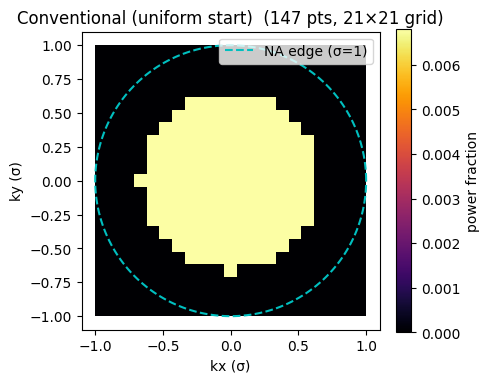

In [13]:
show_source_pupil(conventional(0.7),             title="Conventional (uniform start)", interp="nearest")

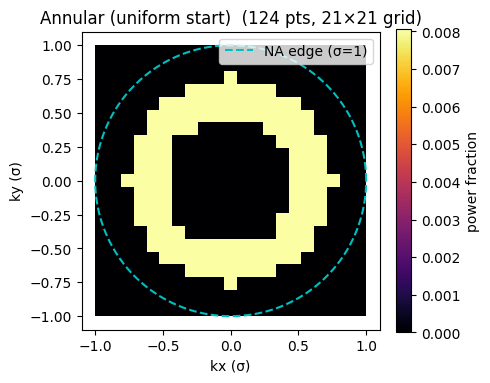

In [14]:
show_source_pupil(annular(0.5, 0.8),             title="Annular (uniform start)",      interp="nearest")

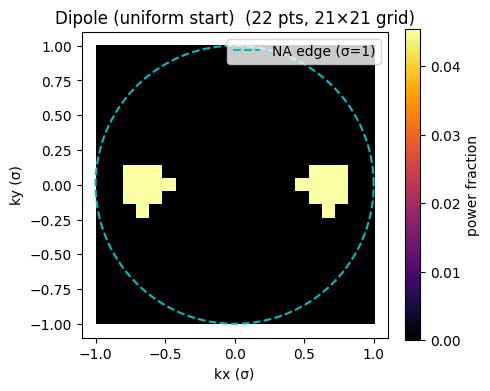

In [15]:
show_source_pupil(dipole(0.7, 0.2, angle_deg=0), title="Dipole (uniform start)",       interp="nearest")

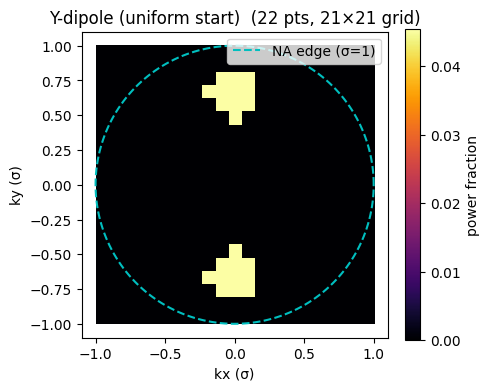

In [16]:
show_source_pupil(y_dipole(0.7, 0.2),                  title="Y-dipole (uniform start)",         interp="nearest")

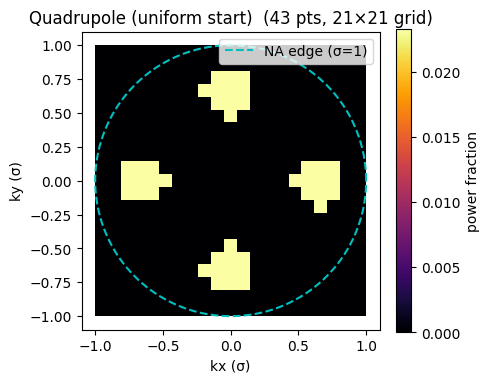

In [17]:
show_source_pupil(quadrupole(0.7, 0.2),                title="Quadrupole (uniform start)",       interp="nearest")

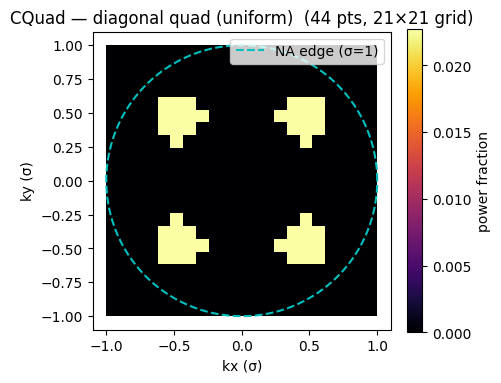

In [18]:
show_source_pupil(cquad(0.7, 0.2),                     title="CQuad — diagonal quad (uniform)",  interp="nearest")

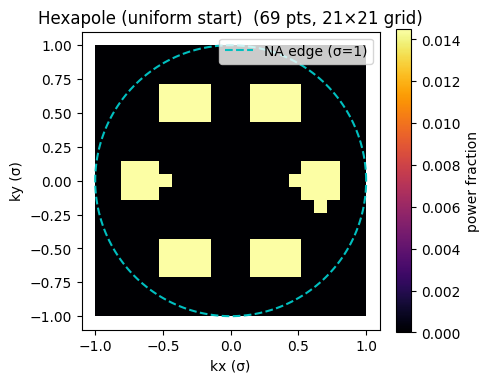

In [19]:
show_source_pupil(hexapole(0.7, 0.2),                  title="Hexapole (uniform start)",         interp="nearest")

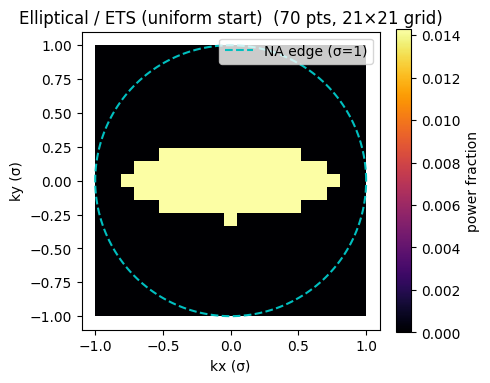

In [20]:
show_source_pupil(elliptical(0.8, 0.3),                title="Elliptical / ETS (uniform start)", interp="nearest")

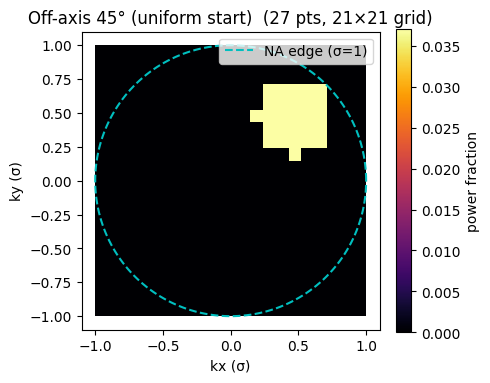

In [21]:
show_source_pupil(off_axis(0.7, 0.3, angle_deg=45),    title="Off-axis 45° (uniform start)",     interp="nearest")

## 5b · Reticle pattern library

Parametric lithography **test patterns**, each standing in for an IC feature and exercising a specific optical effect (iso/dense bias, contact printing, corner rounding, line-end pullback). Authored in physical units, so they stay fixed across `N`. Pick one with the `RETICLE` constant (survives Run All) or the optional dropdown. Add patterns by registering a generator in `RETICLE_LIBRARY` — the selector and gallery pick it up automatically.

In [22]:
# @title 5b.1 Reticle pattern library
# --- Reticle pattern library -------------------------------------------------
# Parametric lithography TEST PATTERNS. Each stands in for a real IC feature and
# exercises a specific optical effect (iso/dense bias, contact printing, corner
# rounding, line-end pullback, dense-to-iso transitions, pad geometry). All are
# authored in PHYSICAL UNITS (metres) and derive pixels from dx_reticle, so they
# stay fixed regardless of N.
#
# Each generator returns an (N,N) complex binary amplitude mask (1 = clear).
# To add a pattern: write a make_*() that returns such a mask, then register it
# in RETICLE_LIBRARY. The selector and gallery pick it up automatically.
#
# CRITICAL_DIM is the smallest feature these draw, tied to GRATING_PITCH so the
# library is resolvable at this NA. All sizes are at the WAFER; the mask plane is
# M_REDUCTION x larger, handled by converting through dx_reticle.

CRITICAL_DIM = GRATING_PITCH / 2          # m, ~half-pitch line width at wafer

def _px(width_m):
    "Wafer width (m) -> reticle-plane pixel count (mask is M x larger)."
    return max(1, int(round(width_m * M_REDUCTION / dx_reticle)))

def _blank():
    return xp.zeros((N, N), dtype=CDTYPE)

def _set(m, r0, r1, c0, c1, val=1.0):
    "Set a rectangular block (clamped to grid). Functional-friendly helper."
    r0 = max(0, r0); c0 = max(0, c0); r1 = min(N, r1); c1 = min(N, c1)
    m[r0:r1, c0:c1] = val
    return m

# --- individual patterns -----------------------------------------------------
def make_dense_lines():
    "Dense line/space grating. ~ gate arrays / dense routing. Tests dense imaging."
    m = _blank(); c = N//2; half = N//4
    period = _px(GRATING_PITCH); duty = period//2
    cols = xp.arange(N)
    line = ((cols % period) < duty).astype(CDTYPE)
    m[c-half:c+half, :] = line[None, :]
    m[:, :c-half] = 0; m[:, c+half:] = 0
    return m

def make_iso_line():
    "Single isolated line. Tests iso/dense bias (prints differently than dense)."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); half = N//4
    return _set(m, c-half, c+half, c-w//2, c+w//2)

def make_iso_space():
    "Single opaque line in a clear (bright) field — the tone-reverse of iso_line."
    # FIX(#3): this used to return an array byte-identical to make_iso_line —
    # the xp.ones init was dead code (immediately zeroed by m[:] = 0) and the
    # slit was then set back to 1: clear-line-in-dark-field all over again.
    # True reverse tone: clear field everywhere, same line geometry but opaque.
    m = xp.ones((N, N), dtype=CDTYPE); c = N//2
    w = _px(CRITICAL_DIM); half = N//4
    return _set(m, c-half, c+half, c-w//2, c+w//2, val=0.0)  # clear surround, dark line

def make_line_ends():
    "Two lines with a gap (facing line-ends). Tests line-end pullback / serifs."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM)
    gap = _px(GRATING_PITCH); seg = N//5
    # FIX(#10): two collinear VERTICAL segments whose facing ends are separated
    # by `gap` (the old comment described left/right lines plus a 'vertical
    # neighbor pair' that was never drawn).
    _set(m, c-seg, c-gap//2, c-w//2, c+w//2)
    _set(m, c+gap//2, c+seg, c-w//2, c+w//2)
    return m

def make_contact_array():
    "Grid of square contacts/vias. Hardest to print; drives source-shape choice."
    m = _blank(); pitch = _px(GRATING_PITCH*1.5); w = _px(CRITICAL_DIM)
    c = N//2; span = N//4
    centers = range(c-span, c+span+1, pitch)
    for r in centers:
        for cc in centers:
            _set(m, r-w//2, r+w//2, cc-w//2, cc+w//2)
    return m

def make_elbow():
    "Single 90° elbow (L-shape). Tests corner rounding / serif correction."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); arm = N//5
    _set(m, c-w//2, c+w//2, c-arm, c+w//2)     # horizontal arm
    _set(m, c-arm, c+w//2, c-w//2, c+w//2)     # vertical arm
    return m

def make_tjunction():
    "T-junction. Tests junction printing and the inner/outer corner asymmetry."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); arm = N//5
    _set(m, c-w//2, c+w//2, c-arm, c+arm)      # horizontal bar
    _set(m, c-w//2, c+arm, c-w//2, c+w//2)     # vertical stem downward
    return m

def make_sram_brick():
    # FIX(#8): the docstring was two separate string STATEMENTS — implicit
    # concatenation only joins literals inside ONE expression — so the second
    # line was a no-op and __doc__ silently truncated. Parenthesized = one
    # expression = full docstring.
    ("Brick-wall of staggered bars — a recognizable SRAM-like cell mix of "
     "dense lines, ends, and corners in one field.")
    m = _blank(); w = _px(CRITICAL_DIM); barL = _px(GRATING_PITCH*2.5)
    rstep = _px(GRATING_PITCH*1.2); cstep = barL + _px(GRATING_PITCH)
    c = N//2; span = N//4
    row_idx = 0
    for r in range(c-span, c+span+1, rstep):
        offset = (cstep//2) if (row_idx % 2) else 0
        for cc in range(c-span+offset, c+span+1, cstep):
            _set(m, r-w//2, r+w//2, cc, cc+barL)
        row_idx += 1
    return m


def make_sram_edge():
    ("Edge of an SRAM bit-cell array — dense staggered bricks on the left "
     "transitioning to wider-pitch peripheral M1 routing (sense-amp region) "
     "with contact landing pads on the right. Represents the litho-hardest "
     "transition zone in real memory layouts: the dense-to-iso boundary plus "
     "wider-metal contacts. Tests OPC on multiple regimes in one field.")
    m = _blank()
    w = _px(CRITICAL_DIM)                    # min line width
    c = N//2; span = N//3                    # ~170 mask px each side (fast res)

    # --- LEFT ~55% : SRAM brick array (staggered rows) ---------------------
    barL  = _px(GRATING_PITCH * 1.5)         # each bar's length
    rstep = _px(GRATING_PITCH * 1.2)         # row-to-row vertical spacing
    cstep = barL + _px(GRATING_PITCH * 0.5)  # bar-to-bar spacing within a row
    brick_left  = c - span
    brick_right = c - span // 4              # split at ~40% into the pattern
    row_idx = 0
    for r in range(c - span, c + span + 1, rstep):
        offset = (cstep // 2) if (row_idx % 2) else 0
        cc = brick_left + offset
        while cc + barL <= brick_right:
            _set(m, r - w//2, r + w//2, cc, cc + barL)
            cc += cstep
        row_idx += 1

    # --- RIGHT ~45% : vertical M1 tracks with landing pads -----------------
    m1_pitch = _px(GRATING_PITCH * 1.8)      # wider peripheral pitch
    m1_w     = max(w, int(w * 1.5))          # slightly wider metal line
    pad_size = int(w * 3)                    # square landing pad ~3x CD
    m1_start = brick_right + _px(GRATING_PITCH)
    cc = m1_start
    while cc + m1_w <= c + span:
        _set(m, c - span, c + span, cc, cc + m1_w)               # vertical track
        _set(m, c - pad_size//2, c + pad_size//2,                # centered pad
             cc + m1_w//2 - pad_size//2, cc + m1_w//2 + pad_size//2)
        cc += m1_pitch
    return m

def make_bond_pad():
    ("Bond-pad geometry — a large square landing pad on the right with "
     "several narrow leader traces feeding in from the left. Represents the "
     "extreme iso/dense transition (many parallel narrow lines converging "
     "into a much wider feature) plus pad-corner rounding, which naive OPC "
     "handles poorly.")
    m = _blank()
    w = _px(CRITICAL_DIM)                    # min line width
    c = N//2; span = N//3                    # ~170 mask px each side

    # Big square pad on the right (~8x CD wide)
    pad_size = int(w * 8)
    pad_c    = c + span // 2                 # column of pad center
    _set(m, c - pad_size//2, c + pad_size//2,
         pad_c - pad_size//2, pad_c + pad_size//2)

    # 5 parallel leader traces converging from the left onto the pad
    n_leaders    = 5
    leader_pitch = _px(GRATING_PITCH * 1.2)
    leader_left  = c - span
    leader_right = pad_c - pad_size//2       # abut the pad edge
    y_span = (n_leaders - 1) * leader_pitch
    for i in range(n_leaders):
        rr = c - y_span//2 + i * leader_pitch
        _set(m, rr - w//2, rr + w//2, leader_left, leader_right)
    return m

def make_logic_block():
    ("Mixed-feature 'random-logic' block — an L-shape (elbow), a T-junction, "
     "a line-end pair, and a 3x3 contact array, all in one field. A single "
     "SMO run must produce a mask/source combo that prints all four correctly "
     "— the source shape that helps one feature type often hurts another, "
     "which is exactly what real-chip OPC has to arbitrate.")
    m = _blank()
    w   = _px(CRITICAL_DIM)                  # min line width
    arm = _px(GRATING_PITCH * 2.5)           # arm/segment length for the L and T
    c = N//2

    # L-shape (elbow) — top-left quadrant
    lx = c - arm - w; ly = c - arm - w
    _set(m, ly - w//2, ly + w//2, lx, lx + arm)                       # horiz arm
    _set(m, ly - w//2, ly + arm - w//2, lx + arm - w, lx + arm)       # vert  arm

    # T-junction — top-right quadrant
    tx = c + arm//2; ty = c - arm - w
    _set(m, ty - w//2, ty + w//2, tx - arm//2, tx + arm//2)           # top bar
    _set(m, ty - w//2, ty + arm - w//2, tx - w//2, tx + w//2)         # stem down

    # Line-end pair — bottom-left quadrant (two collinear vertical segments)
    ex = c - arm - w; ey1 = c + w; ey2 = c + arm + w
    _set(m, ey1, ey1 + arm//2 - w, ex - w//2, ex + w//2)
    _set(m, ey2, ey2 + arm - w,    ex - w//2, ex + w//2)

    # 3x3 contact array — bottom-right quadrant
    v_pitch = _px(GRATING_PITCH * 1.5)
    cx = c + arm//2; cy = c + arm//2 + w
    for dr in range(3):
        for dc in range(3):
            rr = cy + dr * v_pitch
            cc = cx + dc * v_pitch
            if rr + w//2 <= N and cc + w//2 <= N:
                _set(m, rr - w//2, rr + w//2, cc - w//2, cc + w//2)
    return m

# --- registry: name -> generator (add new patterns here) ---------------------
RETICLE_LIBRARY = {
    "dense_lines":   make_dense_lines,
    "iso_line":      make_iso_line,
    "iso_space":     make_iso_space,
    "line_ends":     make_line_ends,
    "contact_array": make_contact_array,
    "elbow":         make_elbow,
    "tjunction":     make_tjunction,
    "sram_brick":    make_sram_brick,
    "sram_edge":     make_sram_edge,
    "bond_pad":      make_bond_pad,
    "logic_block":   make_logic_block,
}

# --- FIX(#4): per-pattern on-axis periodicities for the §6.1 diagnostic ------
# Fundamental ON-AXIS spectral periods in RETICLE-plane pixels along x (cols)
# and y (rows): order m of a pattern with period P px lands m*(N/P) px from
# centre. None = no simple 1-D periodicity on that axis (no markers drawn).
# Keep in sync with the generators above. Measured notes:
#  * dense_lines: 1:1 duty suppresses EVEN orders (their positions still marked).
#  * sram_brick x: the half-pitch row stagger cancels ODD orders of the bar
#    pitch (barL + gap = 112 px) on-axis, so the on-axis period is half that.
#  * sram_brick y: staggered rows form a 2-row supercell, so the on-axis
#    period is 2*rstep (the rstep peak is that supercell's 2nd harmonic).
RETICLE_PITCHES_PX = {
    "dense_lines":   (_px(GRATING_PITCH), None),
    "iso_line":      (None, None),
    "iso_space":     (None, None),
    "line_ends":     (None, None),
    "contact_array": (_px(GRATING_PITCH*1.5), _px(GRATING_PITCH*1.5)),
    "elbow":         (None, None),
    "tjunction":     (None, None),
    "sram_brick":    ((_px(GRATING_PITCH*2.5) + _px(GRATING_PITCH)) // 2,
                      2 * _px(GRATING_PITCH*1.2)),
    # Non-periodic complex layouts — the §6.1 marker overlay is skipped.
    "sram_edge":     (None, None),
    "bond_pad":      (None, None),
    "logic_block":   (None, None),
}

def make_reticle(name):
    "Build a mask by library name. Raises a clear error listing valid names."
    if name not in RETICLE_LIBRARY:
        raise KeyError(f"Unknown reticle '{name}'. Choose from: "
                       f"{list(RETICLE_LIBRARY)}")
    return RETICLE_LIBRARY[name]()

In [23]:
# @title 5b.2 Stress-test reticle patterns (complex — for SMO stress testing)
# --- Additional HARD reticle patterns ----------------------------------------
# Six deliberately difficult patterns to stress the SMO. Each targets a specific
# failure mode: corner rounding, dense-to-iso bias, broken periodicity, tight
# line-ends, staggered segments, and fully aperiodic 2D layout. Same conventions
# as §5b.1: authored in wafer metres via _px(), return (N,N) complex binary mask,
# and self-register into RETICLE_LIBRARY so the selector/gallery/applet pick them
# up automatically.
#
# Difficulty (roughly): comb > random_logic > nested_els > brick_wall >
#                       staggered_contacts > pitch_walk.

def make_nested_els():
    "Concentric L-frames — many 90° CORNERS at tight proximity. Tests corner rounding + proximity."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH)
    for k in range(4):
        r = (k+1)*p
        _set(m, c-r,   c-r+w, c-r, c+r)      # top bar
        _set(m, c+r-w, c+r,   c-r, c+r)      # bottom bar
        _set(m, c-r,   c+r,   c-r, c-r+w)    # left bar  (open-right L-frame)
    return m

def make_pitch_walk():
    "Lines with INCREASING space — dense→iso in one field. Tests iso/dense bias across the walk."
    m = _blank(); c = N//2; half = N//4; w = _px(CRITICAL_DIM)
    col = N//8; k = 1
    while col < 7*N//8:
        _set(m, c-half, c+half, col, col+w)
        col += w + k*w                        # space grows each step
        k += 1
    return m

def make_staggered_contacts():
    "Brick-staggered contact array — breaks the simple periodicity a clean grid has."
    m = _blank(); w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH*1.4)
    for i, r in enumerate(range(N//6, 5*N//6, p)):
        off = (p//2) if (i % 2) else 0
        for cc in range(N//6+off, 5*N//6, p):
            _set(m, r, r+w, cc, cc+w)
    return m

def make_comb():
    "Interdigitated comb — tight finger TIPS facing each other. Brutal line-end + tip-to-tip test."
    m = _blank(); w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH); c = N//2
    spine = _px(CRITICAL_DIM*1.5)
    _set(m, N//6, 5*N//6, N//6, N//6+spine)             # left spine
    for r in range(N//6, 5*N//6, 2*p):                  # fingers → right
        _set(m, r, r+w, N//6, c)
    _set(m, N//6, 5*N//6, 5*N//6-spine, 5*N//6)         # right spine
    for r in range(N//6+p, 5*N//6, 2*p):                # fingers ← left (interdigitated)
        _set(m, r, r+w, c, 5*N//6)
    return m

def make_brick_wall():
    "Staggered line SEGMENTS (brick bond) — dense line-ends + row-to-row stagger, SRAM-like."
    m = _blank(); w = _px(CRITICAL_DIM); segL = _px(GRATING_PITCH*2); p = _px(GRATING_PITCH)
    for i, r in enumerate(range(N//6, 5*N//6, p)):
        off = (segL//2) if (i % 2) else 0
        for cc in range(N//8+off, 7*N//8, segL+w):
            _set(m, r, r+w, cc, cc+segL)
    return m

def make_random_logic():
    "Pseudo-random H/V segments (fixed seed) — fully aperiodic worst case for SMO."
    rng = _np.random.default_rng(42); m = _blank(); w = _px(CRITICAL_DIM)
    for _ in range(60):
        r  = int(rng.integers(N//8, 7*N//8)); cc = int(rng.integers(N//8, 7*N//8))
        L  = int(rng.integers(w, _px(GRATING_PITCH*2)))
        if rng.random() < 0.5:
            _set(m, r, r+w, cc, cc+L)          # horizontal segment
        else:
            _set(m, r, r+L, cc, cc+w)          # vertical segment
    return m

# --- register into the existing library --------------------------------------
RETICLE_LIBRARY.update({
    "nested_els":         make_nested_els,
    "pitch_walk":         make_pitch_walk,
    "staggered_contacts": make_staggered_contacts,
    "comb":               make_comb,
    "brick_wall":         make_brick_wall,
    "random_logic":       make_random_logic,
})
print("Stress-test patterns registered. RETICLE_LIBRARY now has "
      f"{len(RETICLE_LIBRARY)} patterns:")
print("  " + ", ".join(RETICLE_LIBRARY))

Stress-test patterns registered. RETICLE_LIBRARY now has 17 patterns:
  dense_lines, iso_line, iso_space, line_ends, contact_array, elbow, tjunction, sram_brick, sram_edge, bond_pad, logic_block, nested_els, pitch_walk, staggered_contacts, comb, brick_wall, random_logic


### 5b.3 USER INPUT - SELECT RETICLE PATTERN HERE

In [24]:
# --- Reticle selection -------------------------------------------------------
# Source of truth is the string constant below (survives Run All / kernel restart).
# RETICLE = "dense_lines"  is the SMO/OPC-standard default.
RETICLE = "pitch_walk"     # any key in RETICLE_LIBRARY

# Optional interactive dropdown: run the next cell to override RETICLE by click.
# (Widget state does NOT survive a kernel restart — the constant above always
# defines the canonical run; the dropdown is a convenience for exploration.)
mask = make_reticle(RETICLE)
print(f"Selected reticle: '{RETICLE}'  ({len(RETICLE_LIBRARY)} available: "
      f"{list(RETICLE_LIBRARY)})")

Selected reticle: 'pitch_walk'  (17 available: ['dense_lines', 'iso_line', 'iso_space', 'line_ends', 'contact_array', 'elbow', 'tjunction', 'sram_brick', 'sram_edge', 'bond_pad', 'logic_block', 'nested_els', 'pitch_walk', 'staggered_contacts', 'comb', 'brick_wall', 'random_logic'])


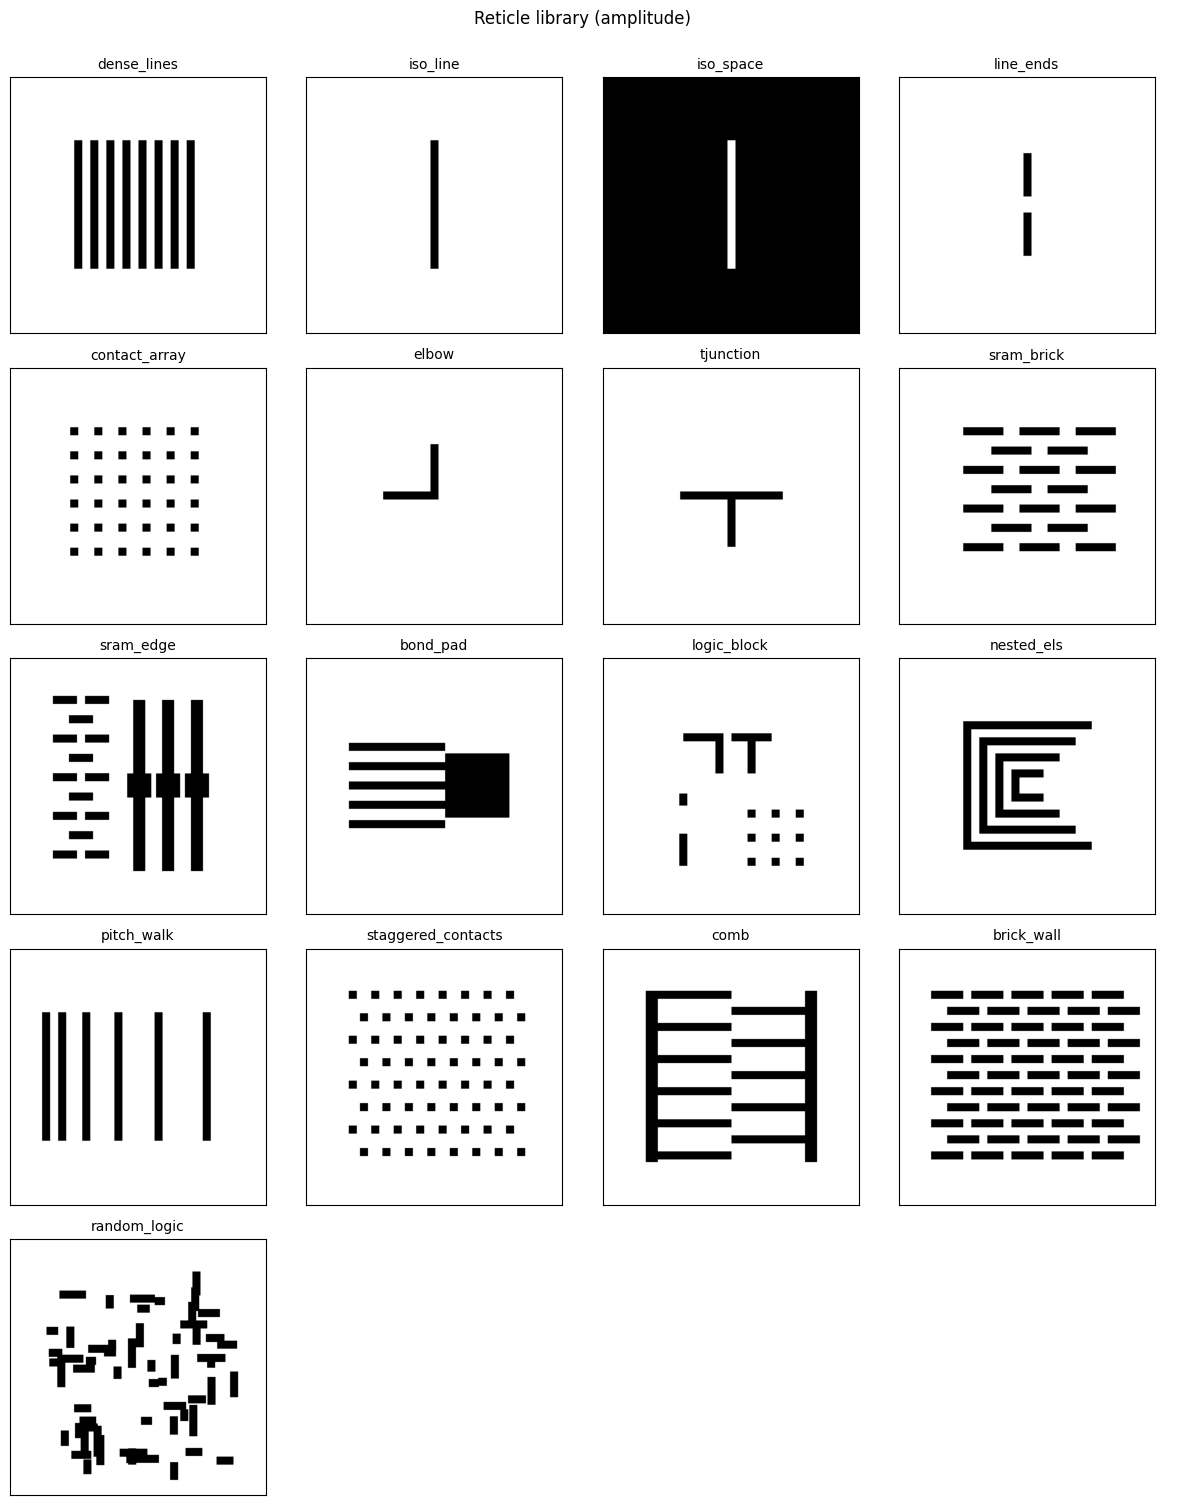

In [25]:
# --- Reticle library gallery -------------------------------------------------
# Preview every registered pattern (amplitude). Useful for choosing RETICLE and
# for the report. Auto-expands as you add patterns to RETICLE_LIBRARY.
names = list(RETICLE_LIBRARY)
ncol = 4; nrow = (len(names) + ncol - 1) // ncol
fig, ax = plt.subplots(nrow, ncol, figsize=(3.0*ncol, 3.0*nrow))
ax = ax.ravel()
for i, name in enumerate(names):
    m = to_cpu(xp.abs(make_reticle(name)))          # make_reticle returns (N,N) array
    ax[i].imshow(m, cmap="gray_r"); ax[i].set_title(name, fontsize=10)
    ax[i].set_xticks([]); ax[i].set_yticks([])
for j in range(len(names), len(ax)):
    ax[j].axis("off")
plt.suptitle("Reticle library (amplitude)", y=1.0)
plt.tight_layout(); plt.show()

In [26]:
# --- OPTIONAL: interactive reticle picker ------------------------------------
# Run this cell to pick a reticle by dropdown; it rebuilds `mask` on change.
# Skip it entirely to use the RETICLE string constant above. If ipywidgets is
# unavailable (some kernels), this degrades gracefully to a printed list.
try:
    import ipywidgets as _w
    from IPython.display import display as _display

    _dd = _w.Dropdown(options=list(RETICLE_LIBRARY), value=RETICLE,
                      description="Reticle:")
    _out = _w.Output()

    def _on_change(change):
        if change["type"] == "change" and change["name"] == "value":
            global mask, RETICLE
            RETICLE = change["new"]
            mask = make_reticle(RETICLE)
            with _out:
                _out.clear_output(wait=True)
                show_field(reticle(make_source_field(), mask),
                           title=f"Reticle: {RETICLE}")
    _dd.observe(_on_change)
    _display(_dd, _out)
    with _out:
        show_field(reticle(make_source_field(), mask), title=f"Reticle: {RETICLE}")
except Exception as e:
    print("ipywidgets not available; use the RETICLE constant instead.", e)

Dropdown(description='Reticle:', index=12, options=('dense_lines', 'iso_line', 'iso_space', 'line_ends', 'cont…

Output()

## 5c · `forward(source, mask)` — the Abbe forward model (This reports beating heart)

Both `source` and `mask` are explicit free variables (never globals), so OPC, source-optimization, and SMO are the same function with a different argument frozen. Defined here so the run section and any optimizer can call it.

Each call produces the **complete (N×N) wafer intensity image at once**.The pixels are all handled simultaneously by the FFTs inside each pass.

> The imaging math is done in the *frequency domain* via FFTs (`to_pupil` / `to_real`). An FFT transforms the whole field in one operation, so every wafer pixel is computed together in a single coherent pass. Looping pixel-by-pixel would be enormously slower and is never necessary.


Partial coherence means the illumination is an *extended* source: many independent illumination angles (source points), which don't interfere with each other. The Abbe recipe handles this by treating each source point separately:

**For each source point (kx, ky, weight):**
1. **`illuminator`** — tilt the incident plane wave to that source point's angle (one coherent illumination direction).
2. **`reticle`** — multiply by the mask (diffraction begins).
3. **`projection_lens`** — FFT → clip by the NA pupil → inverse FFT = one *coherent* aerial image (a full N×N complex field).
4. **`+ w * |f|²`** — take that image's intensity and add it, weighted, into a running sum.

Then divide by the total weight to normalize.

<br>

$$I_\text{wafer}(x,y) = \frac{1}{\sum_k w_k}\sum_{k=1}^{P} w_k \,\big|\,\text{coherent\_image}_k(x,y)\,\big|^2$$

<br>

where each $\text{coherent\_image}_k$ is the full aerial field from source point $k$.

<br>

The crucial physics is in **summing intensities $|f|^2$, never the complex fields** — because different source points are *mutually incoherent*, their intensities add, not their amplitudes. (Summing the fields would wrongly make them interfere.). So the two granularities are

- **Loop dimension:** source points (P of them, e.g. a few hundred). This is the *incoherent* sum — the essence of partial coherence.
- **Per-iteration work:** a full-field coherent imaging pass (three FFT-based stages) that computes *all* N×N wafer pixels at once.

Total cost is therefore "P coherent passes," not "N² pixel evaluations." This is exactly why the design keeps the source loop *outside* the pure stages: each stage stays a whole-field operation, and `forward` just accumulates their intensities.

`source` and `mask` are both explicit arguments (never globals), so the *same* `forward` is what every optimizer calls: OPC varies the mask, source-optimization varies the source, and SMO varies both. SMO is thus an outer loop wrapped around this function, not a rewrite of it.

In [27]:
# @title 5c.1 The forward model (Abbe partial coherence)

# --- forward(source, mask): THE forward model (Abbe partial coherence) --------
# Both source AND mask are explicit free variables — never globals. This single
# function is what every optimizer calls:
#   OPC        : optimize forward(fixed_source, mask)        over mask
#   source-opt : optimize forward(source, fixed_mask)        over source
#   SMO        : optimize forward(source, mask)              over both
# So SMO is an additive outer loop, not a teardown.
#
# Abbe method: each source point is a tilt -> coherent pass -> sum INTENSITIES
# (never fields), weighted by the source weight. xp-clean: functional accumulate.

def forward(source, mask, pupil=None):
    """Partially-coherent aerial image at the wafer.

    source : (P,3) array of (kx, ky, weight) — from a sigma-constructor or DOE.
    mask   : (N,N) complex transmission (from the reticle library).
    pupil  : (N,N) NA mask; defaults to the global PUPIL.
    Returns: (N,N) real intensity (host numpy), normalized by total source weight.
    """
    if pupil is None:
        pupil = PUPIL
    I = xp.zeros((N, N), dtype=RDTYPE)
    wsum = 0.0
    base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                 dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
    for kx, ky, w in source:
        f = illuminator(base, kx=float(kx), ky=float(ky))   # one source point
        f = reticle(f, mask)                                # diffraction
        f = projection_lens(f, pupil)                       # NA-limited imaging
        I = I + w * xp.abs(f.data)**2                       # sum intensities
        wsum += w
    return to_cpu(I / wsum)

## 6 · Pipeline  Visualizer

We push the ideal source through each stage and render the wavefront as it
emerges. Watch the **pupil** panel in the projection step — that's where the NA
discards the high diffraction orders, which is the physical origin of the
resolution limit.

### 6.0 Ideal Pipeline

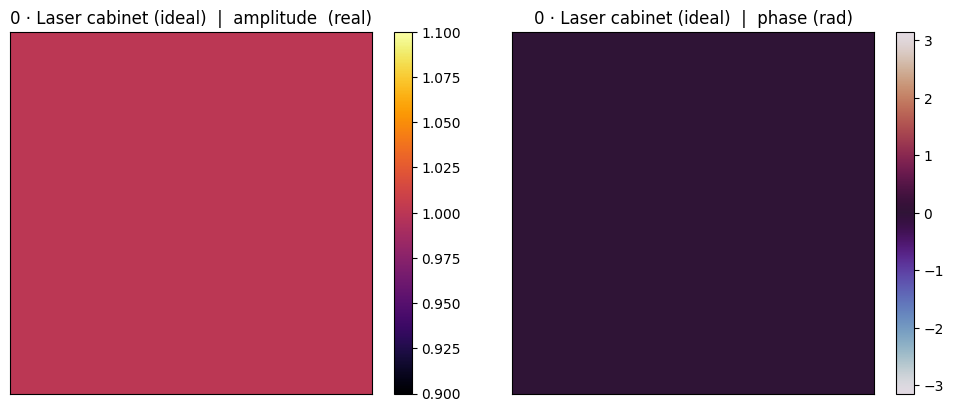

In [28]:
# @title 6.0.1 Stage 0: source
# Stage 0: source
src = make_source_field()
show_field(src, title="0 · Laser cabinet (ideal)")


In [29]:
# @title 6.0.2 Stage 1: illuminator

# Stage 1: illuminator
f1 = illuminator(src)
#show_field(f1, title="1 · After illuminator")#show_field(f1, title="1 · After illuminator")

# =====================================================================
# 6b · Post-DOE viewer (whole DOE) — pupil amplitude & phase + per-point
# ---------------------------------------------------------------------
# Dropdowns pick a DOE SHAPE and DENSITY (n). The viewer shows:
#   Row 1 — PUPIL AMPLITUDE & PHASE of the complete DOE (its native domain).
#           Amplitude = sqrt(power) binned onto the pupil; Phase = DOE phase
#           profile (0 for these amplitude-only sources).
#   Row 2 — one representative SOURCE POINT as a real-space tilted wavefront
#           (amplitude flat, phase = the linear ramp that angle imprints).
#
# PHYSICS NOTE: the complete DOE is an INCOHERENT set of angles — it has no
# single real-space complex field (only intensities sum, per Abbe). So the
# honest "amplitude & phase of the whole DOE" lives in the PUPIL (row 1);
# the real-space complex field is only meaningful per source point (row 2).
#
# Sets `doe_source` in the global namespace on every change.
# =====================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as _np
import matplotlib.pyplot as plt

_DOE_BUILDERS = {
    "conventional (disk, σ=0.7)"     : lambda n: conventional(0.7, n=n),
    "annular (σ 0.4–0.8)"            : lambda n: annular(0.4, 0.8, n=n),
    "dipole-X (σc=0.7, σr=0.2, 0°)"  : lambda n: dipole(0.7, 0.2, angle_deg=0, n=n),
    "y_dipole (σc=0.7, σr=0.2)"      : lambda n: y_dipole(0.7, 0.2, n=n),
    "quadrupole (Manhattan)"         : lambda n: quadrupole(0.7, 0.2, n=n),
    "cquad (diagonal)"               : lambda n: cquad(0.7, 0.2, n=n),
    "hexapole (6 poles, 60°)"        : lambda n: hexapole(0.7, 0.2, n=n),
    "elliptical (σx=0.8, σy=0.3)"    : lambda n: elliptical(0.8, 0.3, n=n),
    "off_axis (σc=0.7, σr=0.3, 45°)" : lambda n: off_axis(0.7, 0.3, angle_deg=45, n=n),
}

def _pupil_amp_phase(src, bins=None):
    """Bin the (kx,ky,weight) source onto a pupil grid and return (amp, phase).
    Amplitude = sqrt(binned power). Phase = arg of the (real, non-negative)
    binned field = 0 everywhere for these amplitude-only DOEs — shown for
    completeness / so phase-shaped DOEs would display correctly."""
    kx, ky, w = src[:, 0], src[:, 1], src[:, 2]
    if bins is None:
        ukx = _np.unique(_np.round(kx, 6))
        bins = int(round(2.0 / _np.min(_np.diff(ukx)))) + 1 if len(ukx) > 1 else 64
    edges = _np.linspace(-1.0, 1.0, bins + 1)
    power, _, _ = _np.histogram2d(ky, kx, bins=[edges, edges], weights=w)  # row=ky
    amp   = _np.sqrt(_np.clip(power, 0, None))
    phase = _np.angle(amp)          # 0 for real, non-negative amplitude
    return amp, phase, bins

_shape_dd = widgets.Dropdown(
    options=list(_DOE_BUILDERS), value="hexapole (6 poles, 60°)",
    description="DOE shape:", style={"description_width": "initial"},
    layout=widgets.Layout(width="360px"))
_density_dd = widgets.Dropdown(
    options=[("11 — fast", 11), ("21 — medium", 21), ("41 — fine", 41),
             ("61 — very fine (slow)", 61)],
    value=21, description="Density n:", style={"description_width": "initial"},
    layout=widgets.Layout(width="230px"))
_point_dd = widgets.Dropdown(
    options=[("centre-most point", "mid"), ("largest-σ point", "outer")],
    value="outer", description="Row-2 point:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="240px"))
_out = widgets.Output()

def _pick_point(src, which):
    r = src[:, 0]**2 + src[:, 1]**2
    return int(_np.argmax(r)) if which == "outer" else int(_np.argmin(r))

def _rebuild(*_):
    global doe_source, doe_shape_name
    doe_source = _DOE_BUILDERS[_shape_dd.value](_density_dd.value)   # sets global
    doe_shape_name = _shape_dd.value                                # human label for other cells
    amp, phase, bins = _pupil_amp_phase(doe_source)
    idx = _pick_point(doe_source, _point_dd.value)
    kx0, ky0, w0 = doe_source[idx]
    f_pt = illuminator(make_source_field(), kx=float(kx0), ky=float(ky0))
    a_pt = to_cpu(xp.abs(f_pt.data))
    p_pt = to_cpu(xp.angle(f_pt.data))

    with _out:
        clear_output(wait=True)
        fig, ax = plt.subplots(2, 2, figsize=(10, 8.6))
        # Row 1: PUPIL amplitude & phase (the whole-DOE, native domain)
        im = ax[0,0].imshow(amp, extent=[-1,1,-1,1], origin="lower", cmap="inferno")
        ax[0,0].set_title("Complete DOE · pupil AMPLITUDE  √power")
        plt.colorbar(im, ax=ax[0,0], fraction=0.046)
        im = ax[0,1].imshow(phase, extent=[-1,1,-1,1], origin="lower",
                            cmap="twilight", vmin=-_np.pi, vmax=_np.pi)
        ax[0,1].set_title("Complete DOE · pupil PHASE (rad)")
        plt.colorbar(im, ax=ax[0,1], fraction=0.046)
        for a in ax[0]:
            th = _np.linspace(0, 2*_np.pi, 200)
            a.plot(_np.cos(th), _np.sin(th), "c--", lw=1.2)
            a.set_xlabel("kx (σ)"); a.set_ylabel("ky (σ)"); a.set_aspect("equal")
        # Row 2: one source point in REAL space (amplitude flat, phase = ramp)
        im = ax[1,0].imshow(a_pt, cmap="inferno")
        ax[1,0].set_title(f"One point (kx={kx0:+.2f}, ky={ky0:+.2f}) · real-space AMPLITUDE")
        plt.colorbar(im, ax=ax[1,0], fraction=0.046)
        im = ax[1,1].imshow(p_pt, cmap="twilight", vmin=-_np.pi, vmax=_np.pi)
        ax[1,1].set_title("Same point · real-space PHASE ramp (rad)")
        plt.colorbar(im, ax=ax[1,1], fraction=0.046)
        for a in ax[1]: a.set_xticks([]); a.set_yticks([])
        plt.tight_layout(); plt.show()

        print(f"doe_source = {_shape_dd.value}, n={_density_dd.value} "
              f"→ {len(doe_source)} points, pupil grid {bins}×{bins}.")
        print("Row 1 = the whole DOE (pupil amplitude & phase — its true domain).")
        print("Row 2 = ONE illumination angle in real space: flat amplitude, phase ramp.")
        print("The complete DOE has no single real-space field (incoherent angles).")

for dd in (_shape_dd, _density_dd, _point_dd):
    dd.observe(_rebuild, names="value")

display(widgets.VBox([widgets.HBox([_shape_dd, _density_dd]), _point_dd]), _out)
_rebuild()

Output()

In [30]:
=====================================================================
# ⛔ STOP HERE — checkpoint after Stage 1 (illuminator / DOE selection)
# ---------------------------------------------------------------------
# Placed right after the Stage-1 DOE selector so a "Run all" halts here,
# letting you change the DOE (via the dropdowns above) before continuing.
#
# HOW IT WORKS: raising an exception stops the run-all chain immediately.
# Everything above (including your DOE selection) is already computed and
# stays in memory. Nothing below runs until you continue manually.
#
# TO CONTINUE: after picking your DOE, either
#   • run the cells below one-by-one (Shift+Enter), or
#   • use Runtime ▸ "Run after" (runs from the next cell onward), or
#   • comment out the `raise` line below and re-run all.
# =====================================================================

class StopForDOESelection(Exception):
    "Intentional halt — not a bug. Change the DOE above, then continue below."
    pass

_STOP_AFTER_STAGE1 = True     # set False to disable this checkpoint entirely

if _STOP_AFTER_STAGE1:
    try:
        _picked = doe_shape_name            # show what's currently selected
    except NameError:
        _picked = "(run the DOE selector cell above first)"
    print(f"⏸  Paused after Stage 1. Current DOE = {_picked}.")
    print("   Change it via the dropdowns above, then run the cells below manually")
    print("   (or Runtime ▸ Run after). Set _STOP_AFTER_STAGE1 = False to skip.")
    raise StopForDOESelection(
        "Intentional stop after Stage 1 — change the DOE, then continue below.")

SyntaxError: invalid syntax (1749346170.py, line 1)

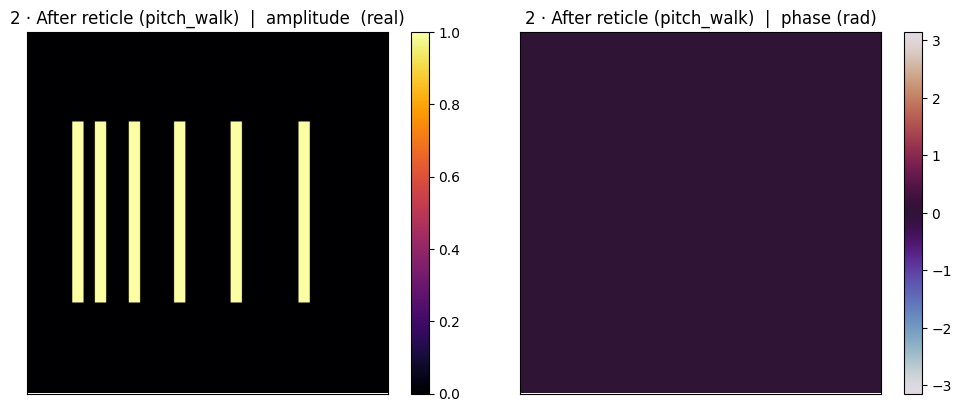

In [31]:
# @title 6.0.3 Stage 3: reticle
# Stage 3: reticle (uses the library selection `mask` from §5b)
f2 = reticle(f1, mask)
show_field(f2, title=f"2 · After reticle ({RETICLE})")

> [NOTE!] - A real DOE and Reticle will produce its own interferene patterns phase shifts. These are not considered in the current solution as we are considering a ideal solution.

## 6.1 Reading the Pupil Diffraction Diagnostic

The pupil diffraction plot shows the Fourier spectrum of the field after the reticle, overlaid with the projection lens's NA cutoff. It is read as a map of **information collected versus information lost**: every bright spot is a diffraction order carrying part of the mask's spatial-frequency content.

<br>

>NA circle marks the boundary between orders the lens collects (inside) and orders it discards (outside).

<br>

The diffraction pattern is not a target to match. It is the Fourier transform of whatever mask is loaded, so it cannot be tuned independently of the desired wafer pattern.

<br>

>What is tuned is the *relationship* between what the mask diffracts and what the pupil collects — through NA, illumination shape, mask type, and OPC.

<br>

**The plot is the instrument used to read whether the pattern's essential orders land where the lens can use them.**

## What the plot conveys

**1. Which orders survive — the resolution check.** Every bright order inside the NA circle reaches the wafer; everything outside is discarded. For a periodic feature, at least the 0 and ±1 orders must fall inside the circle to form any image of that pitch, since two interfering beams are the minimum needed to produce a fringe. If only the 0 order fits, the feature is below the resolution limit and prints as a flat blob. First check: for the finest feature, do at least the ±1 orders sit inside the circle?

**2. How close orders sit to the edge — the process margin.** Orders sitting at the rim of the NA circle indicate imaging at the very limit, where small focus or aberration errors lose them, contrast collapses, and the process window narrows. Orders comfortably inside the circle indicate robust imaging. Radial position relative to the circle is read as a proxy for process margin; orders hugging the rim are a warning that the feature is marginal and will need resolution enhancement.

**3. How much energy the surviving orders carry — the contrast.** Image contrast at the wafer arises from interference between the collected orders, and is strongest when those orders are comparable in strength. If the 0 order dominates the ±1 orders by orders of magnitude, the result is a bright background with weak modulation — low contrast and poor exposure latitude. Comparing the relative brightness of the ±1 orders to the 0 order reveals whether a contrast problem exists, and whether a phase-shift mask (which suppresses the 0 order to let the ±1 orders dominate) would help.

**4. Where energy is wasted — the illumination-shaping cue.** With conventional on-axis illumination, the ±1 orders land symmetrically and both must fit inside the circle. If they fall just outside, a larger NA is not the only remedy: tilting the illumination off-axis (annular, dipole) shifts one order toward center so it lands inside, even as the other shifts out. The position of the orders relative to the circle therefore indicates which illumination shape would pull the information-carrying orders into the pupil — for example, dipole illumination for dense lines is read directly from seeing the ±1 orders sit just outside the rim on one axis.

`Connection to OPC`

In spectral terms, OPC is the redesign of the mask so that the orders surviving the NA circle sum to the target wafer image, accepting that the high orders are always lost. The diffraction plot is where that truncation is made visible: it shows exactly which spatial-frequency information the lens discards, which is the information OPC must work around through serifs, scatter bars, and edge biasing.

Order $m$ of a pattern with pitch $p$ sits at frequency $m/p$, i.e. at pixel radius

<br>

$$r_m=\frac{m/p}{\Delta f}=m\,\frac{\mathrm{FOV}}{p},\qquad\text{captured}\iff \frac mp\le\frac{\mathrm{NA}}{\lambda}\iff m\le \frac{p\,\mathrm{NA}}{\lambda}.$$

<br>



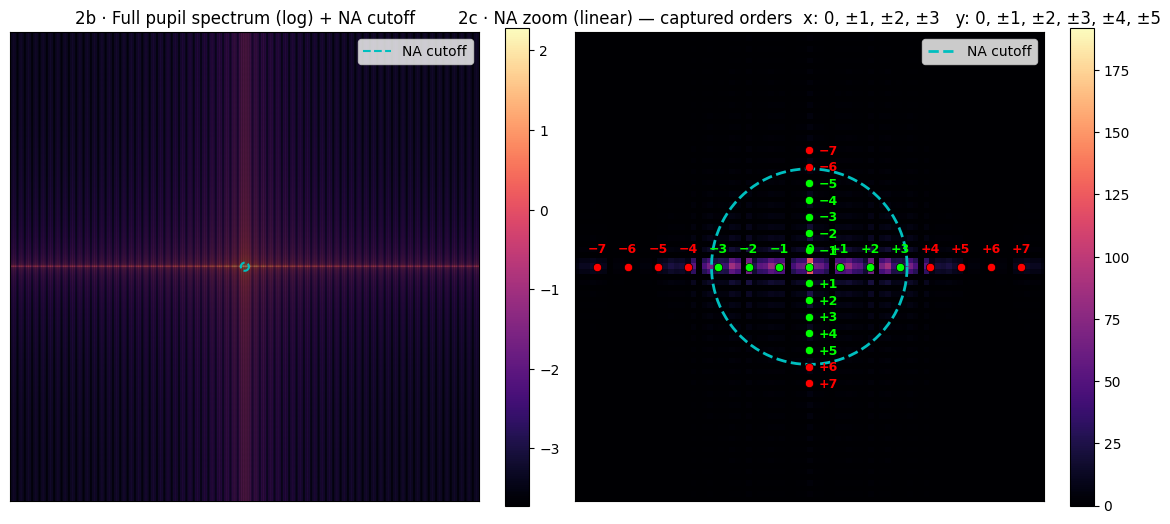

Diffraction orders for RETICLE = 'pitch_walk':
  x-axis (on-axis pitch 733.4 nm at wafer, measured):
    order ±0: radius    0.0 px   (INSIDE NA=17.6 px)
    order ±1: radius    5.5 px   (INSIDE NA=17.6 px)
    order ±2: radius   10.9 px   (INSIDE NA=17.6 px)
    order ±3: radius   16.4 px   (INSIDE NA=17.6 px)
    order ±4: radius   21.8 px   (outside NA=17.6 px)
    order ±5: radius   27.3 px   (outside NA=17.6 px)
    order ±6: radius   32.7 px   (outside NA=17.6 px)
    order ±7: radius   38.2 px   (outside NA=17.6 px)
  y-axis (on-axis pitch 1333.3 nm at wafer, measured):
    order ±0: radius    0.0 px   (INSIDE NA=17.6 px)
    order ±1: radius    3.0 px   (INSIDE NA=17.6 px)
    order ±2: radius    6.0 px   (INSIDE NA=17.6 px)
    order ±3: radius    9.0 px   (INSIDE NA=17.6 px)
    order ±4: radius   12.0 px   (INSIDE NA=17.6 px)
    order ±5: radius   15.0 px   (INSIDE NA=17.6 px)
    order ±6: radius   18.0 px   (outside NA=17.6 px)
    order ±7: radius   21.0 px   (outside NA

In [32]:
# @title 6.1.1. Diffraction spectrum at the pupil  (pattern-agnostic)
# --- Diffraction spectrum at the pupil: full view + labelled NA zoom ----------
# LEFT : full pupil (log) — all orders. RIGHT: linear zoom on the NA region,
# orders labelled green=captured / red=clipped.
#
# ROBUST ORDER DETECTION (works for ANY reticle, present or future):
# Instead of a hardcoded RETICLE_PITCHES_PX lookup (which only covered patterns
# someone remembered to register), we MEASURE the periodicity directly from the
# mask's own diffraction spectrum. Peaks along the x- and y- cuts through DC are
# found, then a HARMONICITY test confirms they form an integer-multiple comb
# before any markers are drawn. Aperiodic patterns (iso lines, logic blocks,
# bond pads) produce no false comb and are correctly labelled "no periodicity".
# A registered RETICLE_PITCHES_PX entry, if present, is used as an OVERRIDE.

spec = to_pupil(f2)
A    = to_cpu(xp.abs(spec.data))
Alog = _np.log10(A + A.max()*1e-6 + 1e-12)
theta = _np.linspace(0, 2*_np.pi, 200)
cx = cy = N // 2

# ---------------------------------------------------------------------------
def _sub_peak(half, r):
    "Parabolic sub-pixel refinement of an integer peak index r."
    if r <= 0 or r >= len(half) - 1:
        return float(r)
    y0, y1, y2 = half[r-1], half[r], half[r+1]
    d = (y0 - 2*y1 + y2)
    return r + 0.5*(y0 - y2)/d if d != 0 else float(r)

def _detect_orders_from_spectrum(A, cx, cy, axis="x", n_orders=8,
                                 rel_thresh=0.03, min_sep_px=2.0,
                                 harmonic_tol=0.15, min_harmonics=2):
    """Measure diffraction-order radii for one axis directly from spectrum A.
    Returns (orders_dict {m: radius_px}, period_px) or ({}, None) if the
    pattern is not clearly periodic along that axis. Periodicity is confirmed
    only when the detected peaks form a harmonic series."""
    line = (A[cy, :] if axis == "x" else A[:, cx]).astype(float)
    c = cx if axis == "x" else cy
    half = line[c:]                                   # DC outward, one side
    if half.size < 4 or half.max() <= 0:
        return {}, None
    thr = rel_thresh * half.max()
    peaks = [r for r in range(1, len(half)-1)
             if half[r] > thr and half[r] >= half[r-1] and half[r] >= half[r+1]]
    merged = []                                       # merge near-duplicate peaks
    for r in peaks:
        if merged and (r - merged[-1]) < min_sep_px:
            if half[r] > half[merged[-1]]:
                merged[-1] = r
        else:
            merged.append(r)
    if not merged:
        return {}, None
    r1 = _sub_peak(half, merged[0])                   # fundamental (1st order) radius
    if r1 < 1:
        return {}, None
    good = sum(1 for r in merged
               if round(r/r1) >= 1 and abs(r - round(r/r1)*r1) <= harmonic_tol*r1)
    if good < min_harmonics:                          # no real comb -> aperiodic
        return {}, None
    orders = {0: 0.0}
    for m in range(1, n_orders):
        orders[m] = m * r1
    return orders, N / r1                             # period_px = N / r1

def _order_radii_from_period(period_px, n_orders=8):
    "Registered-period fallback: order m radius = m*N/period_px."
    if period_px is None:
        return {}
    return {m: m * N / period_px for m in range(0, n_orders)}
# ---------------------------------------------------------------------------

# Prefer a REGISTERED pitch (exact, human-verified) if one exists; otherwise
# auto-detect from the spectrum so any new pattern still gets correct markers.
label_orders = True
_reg = RETICLE_PITCHES_PX.get(RETICLE, (None, None)) if "RETICLE_PITCHES_PX" in globals() else (None, None)
reg_x, reg_y = _reg

if reg_x is not None:
    orders_x = _order_radii_from_period(reg_x); period_x_px = reg_x; src_x = "registered"
else:
    orders_x, period_x_px = _detect_orders_from_spectrum(A, cx, cy, axis="x"); src_x = "measured"

if reg_y is not None:
    orders_y = _order_radii_from_period(reg_y); period_y_px = reg_y; src_y = "registered"
else:
    orders_y, period_y_px = _detect_orders_from_spectrum(A, cx, cy, axis="y"); src_y = "measured"

captured_x = [m for m, r in orders_x.items() if m > 0 and r <= pupil_radius_px]
captured_y = [m for m, r in orders_y.items() if m > 0 and r <= pupil_radius_px]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 5.2))

# LEFT: full spectrum (log)
im0 = ax[0].imshow(Alog, cmap="magma")
ax[0].plot(cx + pupil_radius_px*_np.cos(theta), cy + pupil_radius_px*_np.sin(theta),
           "c--", lw=1.5, label="NA cutoff")
ax[0].set_title("2b · Full pupil spectrum (log) + NA cutoff")
ax[0].legend(loc="upper right"); ax[0].set_xticks([]); ax[0].set_yticks([])
plt.colorbar(im0, ax=ax[0], fraction=0.046)

# RIGHT: linear zoom on the NA region, with order markers per periodic axis
zoom = 2.4 * pupil_radius_px
im1 = ax[1].imshow(A, cmap="magma", interpolation="nearest")
ax[1].plot(cx + pupil_radius_px*_np.cos(theta), cy + pupil_radius_px*_np.sin(theta),
           "c--", lw=2.0, label="NA cutoff")
if label_orders:
    for axis, orders in (("x", orders_x), ("y", orders_y)):
        for m, r in orders.items():
            if r > zoom or (m == 0 and axis == "y" and orders_x):
                continue                       # draw the 0 order only once
            col = "lime" if r <= pupil_radius_px else "red"
            for sign in ((1,) if m == 0 else (1, -1)):
                x = cx + sign*r if axis == "x" else cx
                y = cy if axis == "x" else cy + sign*r
                off = (0, 10) if axis == "x" else (14, -3)
                ax[1].plot(x, y, "o", color=col, ms=6, mec="black", mew=0.5)
                ax[1].annotate("0" if m == 0 else f"{'+' if sign>0 else '−'}{m}",
                               xy=(x, y), xytext=off, textcoords="offset points",
                               ha="center", color=col, fontsize=9, fontweight="bold")
ax[1].set_xlim(cx - zoom, cx + zoom); ax[1].set_ylim(cy + zoom, cy - zoom)
if orders_x or orders_y:
    parts = []
    if orders_x:
        parts.append("x: 0" + "".join(f", ±{m}" for m in captured_x))
    if orders_y:
        parts.append("y: 0" + "".join(f", ±{m}" for m in captured_y))
    cap_str = "   ".join(parts)
    ax[1].set_title(f"2c · NA zoom (linear) — captured orders  {cap_str}")
else:
    ax[1].set_title(f"2c · NA zoom (linear) — no order markers: "
                    f"'{RETICLE}' has no simple 1-D periodicity")
ax[1].legend(loc="upper right"); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.colorbar(im1, ax=ax[1], fraction=0.046)

plt.tight_layout(); plt.show()

if orders_x or orders_y:
    print(f"Diffraction orders for RETICLE = '{RETICLE}':")
    for axis, orders, period, srcflag in (("x", orders_x, period_x_px, src_x),
                                          ("y", orders_y, period_y_px, src_y)):
        if not orders:
            continue
        pitch_wafer_nm = period * dx_wafer * 1e9   # reticle px -> wafer nm (/M cancels)
        print(f"  {axis}-axis (on-axis pitch {pitch_wafer_nm:.1f} nm at wafer, {srcflag}):")
        for m, r in orders.items():
            print(f"    order ±{m}: radius {r:6.1f} px   "
                  f"({'INSIDE' if r <= pupil_radius_px else 'outside'} "
                  f"NA={pupil_radius_px:.1f} px)")
else:
    print(f"RETICLE = '{RETICLE}' shows no harmonic diffraction comb "
          "(aperiodic test pattern) — no order table.")

## 6.2 Optical Image on wafer - Coherence Imaging - Point light source.

This is the "before resist" picture — the actual optical image the wafer sees. It's the first place the resolution limit becomes visible: the difference between the crisp f2 mask and the blurred f3 aerial image is exactly the information the NA threw away. Everything downstream (the resist threshold, the printed contour, OPC/SMO) is trying to recover a good printed pattern from this degraded image.

>{NOTE] The CAR reacts to intensity of the wavefront which is |E|², i.e. amplitude squared. This is beacause the CAR reacts to absorbed optical energy (dose), and energy is proportional to |E|² — the intensity. Photons deliver energy per unit area at a rate set by |E|², so that's what drives the acid-generation photochemistry. The phase of E carries no energy, so the resist is blind to it;


The CAR reacts to the light intensity at the wafer plane produced by a single on-axis plane wave  passing through the full pipeline (illuminator → reticle → projection lens).

> [NOTE!] This causes low amplitude diffraction artifacts on the wafer to disappear when intensity is considered.

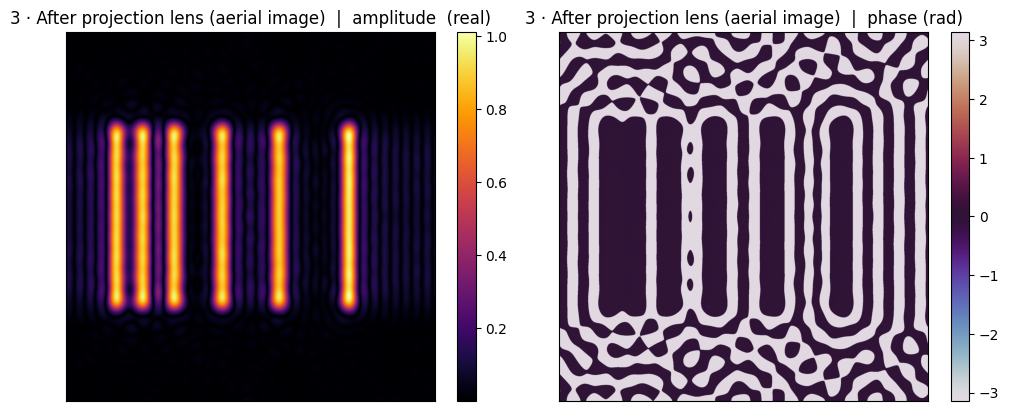

In [33]:
# @title 6.2.1  Optical Image on wafer - amplitude/phase
# Stage 3: projection lens (NA-limited)
f3 = projection_lens(f2)
show_field(f3, title="3 · After projection lens (aerial image)")


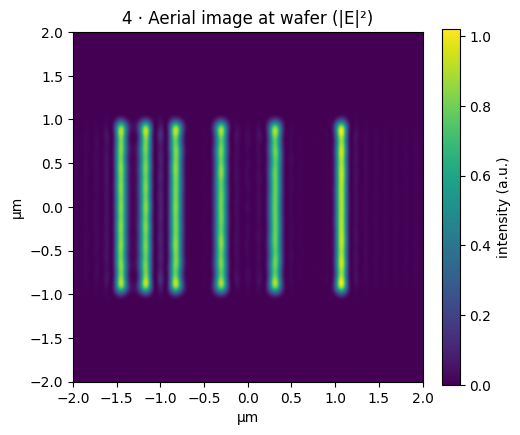

In [34]:
# @title 6.2.2  Optical Image on wafer - Intensity (CAR activation pattern)
# Stage 4: wafer
f4 = wafer(f3)
show_intensity(f4, title="4 · Aerial image at wafer (|E|²)", extent_um=FOV_WAFER*1e6)

## 6.3 Partial-coherent image via forward for selected DOE

This is the partially-coherent aerial image — the intensity at the wafer produced by an extended source (here an annular ring of illumination angles) rather than a single point.

<br>

It is computed by forward(source, mask), which runs Abbe's method: each source point illuminates the mask as its own tilted coherent pass, and the resulting intensities are summed (never the fields).

<br>

This is the physically realistic aerial image, because real illuminators always span a range of angles. Compared to the coherent image above, edges are softer and fine ringing is washed out — that smoothing is the optical signature of partial coherence.

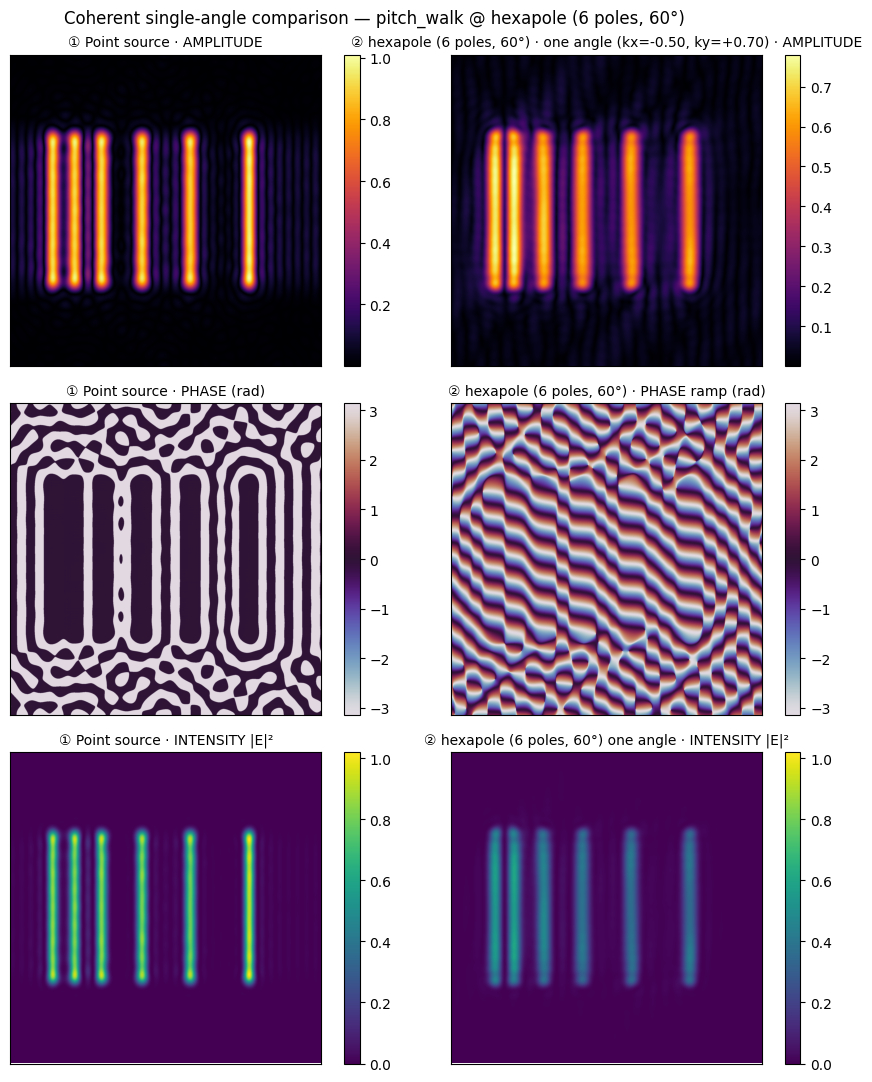

In [35]:
# @title 6.3.1 Coherent vs partially-coherent: amplitude / phase / intensity

# --- Coherent vs partially-coherent: amplitude / phase / intensity -----------
# Uses the DOE you selected in the dropdown viewer above (global `doe_source`,
# named by `doe_shape_name`). No hardcoded shape.
#
# IMPORTANT — what this figure IS and ISN'T:
#   It compares TWO single coherent ANGLES to show amplitude & phase:
#     ① POINT SOURCE (on-axis)          — one coherent angle
#     ② ONE ANGLE of the selected DOE   — one coherent angle (a tilt)
#   A single off-axis angle only SHIFTS which orders enter the NA; for 2-D /
#   asymmetric masks (e.g. sram_brick) one tilt biases orientations and can look
#   WORSE than on-axis. That is expected. The RESOLUTION BENEFIT of off-axis
#   illumination is a property of the WHOLE source summed together, and appears
#   only in the partially-coherent FULL-DOE image — shown here as the black
#   reference curve in the line-cut, and fully in forward(source, mask) (§7).
#
# PHYSICS NOTE: the full DOE image is intensity-only (incoherent sum → no single
# complex field), so only the two coherent single-angle cases get amp/phase.
import numpy as _np
import matplotlib.pyplot as plt

# ---- use the DOE selected above (fallback if the viewer wasn't run) ---------
try:
    source = doe_source
    _src_name = doe_shape_name                       # human label from selector
except NameError:
    source = annular(0.5, 0.8, n=21)
    _src_name = "annular(0.5,0.8) [default — run the DOE selector to override]"

# representative single angle of the chosen DOE (outer-most = clearest tilt)
_r2 = source[:,0]**2 + source[:,1]**2
_idx = int(_np.argmax(_r2))
kx1, ky1, _w1 = source[_idx]

def _coherent_wafer_field(kx, ky):
    "Full coherent complex field at the wafer for ONE illumination angle."
    f = illuminator(make_source_field(), kx=float(kx), ky=float(ky))
    f = reticle(f, mask)
    f = projection_lens(f)
    return f.data

# ① on-axis point (coherent)
E0 = _coherent_wafer_field(0.0, 0.0)
amp0, ph0, I0 = to_cpu(xp.abs(E0)), to_cpu(xp.angle(E0)), to_cpu(xp.abs(E0)**2)
# ② one angle of the selected DOE (coherent)
E1 = _coherent_wafer_field(kx1, ky1)
amp1, ph1, I1 = to_cpu(xp.abs(E1)), to_cpu(xp.angle(E1)), to_cpu(xp.abs(E1)**2)
# full DOE (partially coherent) — reference for the line-cut only
I_pc = forward(source, mask)

_pt = f"{_src_name} · one angle (kx={kx1:+.2f}, ky={ky1:+.2f})"
ext = [-FOV_WAFER/2*1e6, FOV_WAFER/2*1e6]*2
fig, ax = plt.subplots(3, 2, figsize=(9.5, 11))

def _show(a, img, ttl, cmap="inferno", vmin=None, vmax=None, phase=False):
    im = a.imshow(img, cmap=("twilight" if phase else cmap),
                  vmin=(-_np.pi if phase else vmin),
                  vmax=(_np.pi if phase else vmax), extent=ext)
    a.set_title(ttl, fontsize=10); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)

# Row 0 — amplitude
_show(ax[0,0], amp0, "① Point source · AMPLITUDE")
_show(ax[0,1], amp1, f"② {_pt} · AMPLITUDE")
# Row 1 — phase
_show(ax[1,0], ph0, "① Point source · PHASE (rad)", phase=True)
_show(ax[1,1], ph1, f"② {_src_name} · PHASE ramp (rad)", phase=True)
# Row 2 — intensity (shared scale)
_vmax = max(I0.max(), I1.max(), I_pc.max())
_show(ax[2,0], I0, "① Point source · INTENSITY |E|²", cmap="viridis", vmin=0, vmax=_vmax)
_show(ax[2,1], I1, f"② {_src_name} one angle · INTENSITY |E|²", cmap="viridis", vmin=0, vmax=_vmax)

plt.suptitle(f"Coherent single-angle comparison — {RETICLE} @ {_src_name}", fontsize=12)
plt.tight_layout(); plt.show()


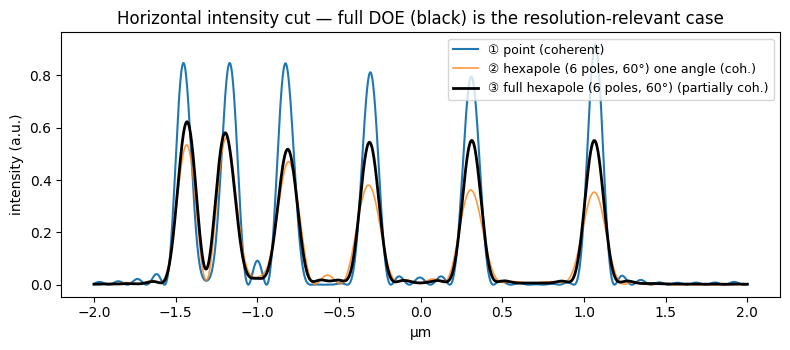

Source = hexapole (6 poles, 60°) (69 angles).
① and ② are SINGLE coherent angles (amp/phase shown). A single off-axis
angle only shifts orders — for 2-D masks it can look WORSE than on-axis.
The resolution benefit is collective: it appears in ③ the FULL-DOE curve
(black) and in forward(source, mask) — NOT in any one angle.


In [36]:
# ---- reference line-cut: where the DOE's real benefit shows up --------------
row = I0.shape[0] // 2
xax = _np.linspace(ext[0], ext[1], I0.shape[1])
plt.figure(figsize=(8.0, 3.6))
plt.plot(xax, I0[row],   label="① point (coherent)",              lw=1.5)
plt.plot(xax, I1[row],   label=f"② {_src_name} one angle (coh.)", lw=1.2, alpha=0.8)
plt.plot(xax, I_pc[row], label=f"③ full {_src_name} (partially coh.)", lw=2.0, color="k")
plt.title("Horizontal intensity cut — full DOE (black) is the resolution-relevant case")
plt.xlabel("µm"); plt.ylabel("intensity (a.u.)"); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"Source = {_src_name} ({len(source)} angles).")
print("① and ② are SINGLE coherent angles (amp/phase shown). A single off-axis")
print("angle only shifts orders — for 2-D masks it can look WORSE than on-axis.")
print("The resolution benefit is collective: it appears in ③ the FULL-DOE curve")
print("(black) and in forward(source, mask) — NOT in any one angle.")

## 7 · Resist model, and Source-Mask Optimization (SMO)

This section closes the loop. First it upgrades the `wafer` stage with a real **resist threshold** (a sigmoid dose-to-clear), so we can finally ask *what actually prints*. Then it implements **SMO** — co-optimizing the **DOE (source)** and the **mask (OPC/ILT)** together against a target pattern.

Both optimizers call the same `forward(source, mask)` locked earlier: the mask step holds the source fixed (that's OPC/ILT), the source step holds the mask fixed (that's DOE design), and alternating them is SMO. The result is a *designed illumination* and a *corrected mask* that print closer to target than either could alone.

### 7.1 · Resist threshold model (real `wafer` stage)

Aerial intensity → printed pattern via a sigmoid at the dose-to-clear threshold.

The image is **dose-normalized** so an open frame = intensity 1.0, making the threshold a meaningful fraction.

The sigmoid (vs. a hard cut) is differentiable (derivative of a constant is 0, so the derivative of a step function is 0). The SMO needs a differentiable function.

This overrides the placeholder `wafer` from §5 above.

In [37]:
# @title 7.1.1 Stage 4 (real): Wafer / CAR resist threshold model

# --- Stage 4 (real): Wafer / CAR resist threshold model ----------------------
# The aerial image is continuous intensity. The PRINTED pattern is where that
# intensity crosses the resist's dose-to-clear THRESHOLD. We use a SIGMOID
# (smooth step) rather than a hard cutoff: it is differentiable (SMO needs that)
# and physically models finite resist contrast.
#
#   printed(x) = sigmoid( STEEPNESS * (I_norm(x) - THRESHOLD) )
#
# DOSE NORMALIZATION: with the unitary FFT pair (norm="ortho") a clear mask
# under any in-pupil source point images to intensity 1.0 exactly, so the
# open-frame mean is ~1.0 (measured ≈0.99; the ~1% deficit is spectral leakage
# of tilts that fall between frequency bins, clipped at the pupil edge).
# FIX(#2): the "~0.1" formerly blamed on the FFT convention was really an
# effect of finding #1 — M x-too-steep tilts threw the 0th order of most
# source points outside the pupil. We keep the normalization, so THRESHOLD stays an
# exact dose-to-clear fraction for any source shape or future apodization.

# open-frame reference intensity (clear mask), under a chosen reference source.
def _open_frame_norm(source=None):
    if source is None:
        source = conventional(0.7, n=9)
    clear = xp.ones((N, N), dtype=CDTYPE)
    I_open = forward(source, clear)
    return float(_np.mean(I_open))          # scalar normalizer

OPEN_FRAME_I = _open_frame_norm()           # ≈1.0 (≈0.99) after FIX(#1)

RESIST_THRESHOLD = 0.30     # dose-to-clear, as a fraction of open-frame intensity
RESIST_STEEPNESS = 8.0      # sigmoid sharpness in NORMALIZED units

def normalize_dose(I):
    "Scale aerial intensity so open-frame mean = 1.0 (dose-to-clear meaningful)."
    return I / OPEN_FRAME_I

def resist(I, threshold=RESIST_THRESHOLD, steepness=RESIST_STEEPNESS,
           normalized=False):
    """Aerial intensity -> printed pattern in [0,1] via a sigmoid threshold.
    If `normalized` is False, dose-normalizes first. Pure/functional, xp-clean."""
    In = I if normalized else normalize_dose(I)
    return 1.0 / (1.0 + _np.exp(-steepness * (In - threshold)))

def print_pattern(source, mask, threshold=RESIST_THRESHOLD, pupil=None):
    """'What you get on the wafer': partially-coherent aerial image -> printed
    resist pattern in [0,1], dose-normalized."""
    I = forward(source, mask, pupil=pupil)
    return resist(I, threshold=threshold)


def wafer(f, threshold=RESIST_THRESHOLD):
    """Stage-4 wafer: complex aerial Field -> printed resist pattern in [0,1].
    (Earlier this was a pass-through stub; now it applies the resist model.)"""
    assert f.domain == "real"
    I = to_cpu(xp.abs(f.data)**2)
    return resist(I, threshold=threshold)

## 8 · The SMO/OPC engine


### 8.1 OPC (Optical Proximity Correction)

<br>

**Goal:** modify the *mask* so the printed wafer pattern matches the target, compensating for the blurring the optics introduce. The source (illumination) is held **fixed**.

<br>

**How it works (as implemented here — an ILT-style gradient loop):**
1. Run the forward model `forward(source, mask)` → aerial intensity → resist → printed pattern.
2. Measure the error between printed and target (`pattern_error` / edge-placement error).
3. Compute the **mask gradient** (adjoint/ILT method after Poonawala & Milne): how each mask pixel should change to reduce the error.
4. Nudge the mask pixels down that gradient. Because the mask is relaxed to continuous [0,1] via a sigmoid, steps stay in-bounds and differentiable.
5. Repeat until the printed pattern is close enough.

The result is an **OPC'd mask** — biased edges, serifs, scatter bars, or (in full ILT) curvilinear shapes — that *pre-distorts* the mask so the optics blur it back into the desired shape. OPC is not a separate optical stage; it's an outer loop that repeatedly calls the same `forward()` with the mask as the variable.

<br>

`Flowchart - ` **OPC loop (mask only, source fixed)**

<br>

```mermaid
flowchart TD
    A["Target pattern"] --> B["Current mask"]
    B --> C["forward(source, mask)<br/>aerial intensity"]
    C --> D["Resist threshold<br/>printed pattern"]
    D --> E["Measure error<br/>printed vs target (EPE)"]
    E --> F{"Error small<br/>enough?"}
    F -- No --> G["Mask gradient (ILT/adjoint)<br/>which pixels to change"]
    G --> H["Update mask pixels"]
    H --> C
    F -- Yes --> I["OPC'd mask"]

### 8.2 SMO (Source-Mask Optimization)

<br>

**Goal:** co-optimize *both* the **source (DOE)** and the **mask (OPC)** together against the target — jointly finding the best illumination shape and the best mask, which print better than optimizing either alone.

<br>

**How it works (alternating scheme):**
- **(A) Mask step** — fix the source, gradient-descend the mask pixels. This *is* OPC/ILT (the loop above).
- **(B) Source step** — fix the mask, optimize the per-point source weights (which illumination angles are on and how bright). Since the image is *linear* in the source weights ($I=\sum_k w_k I_k$), this gradient is a cheap projection.
- **Alternate** A and B for several outer iterations. Both steps call the *same* `forward()`.

<br>

**After the loop (manufacturability projections):**
- **Binarization (STE):** the mask is forced to strict {0,1} (chrome-on-glass), using a straight-through estimator so gradients still flow.
- **MRC (Mask Rule Check):** morphological opening + closing removes sub-minimum features the mask shop can't make.
- **Source polish + DOE projection:** a short source-only refinement, then smoothing/quantizing the source so a real programmable illuminator (mirror array / aperture) could deliver it.

The result is a **designed illumination (DOE) + a corrected mask** that together print closest to target. SMO = OPC (mask step) + DOE design (source step), alternated.

<br>

OPC optimizes the mask alone. SMO adds a source-optimization step and alternates the two. Both are **outer loops around the one `forward(source, mask)` model** — the mask step holds the source fixed, the source step holds the mask fixed, and neither rewrites the optics.

`Flowchart-` **SMO loop (source + mask, alternating)**

```mermaid
flowchart TD
    A["Target pattern"] --> B["Init source (DOE)<br/>+ init mask"]
    B --> C["Outer iteration"]
    C --> D["(A) MASK STEP<br/>fix source, descend mask = OPC/ILT"]
    D --> E["(B) SOURCE STEP<br/>fix mask, optimize source weights = DOE design"]
    E --> F{"More outer<br/>iterations?"}
    F -- Yes --> C
    F -- No --> G["Binarize mask (STE)<br/>strict 0/1 chrome-on-glass"]
    G --> H["MRC<br/>opening + closing (min feature size)"]
    H --> I["Source polish<br/>DOE settles vs final mask"]
    I --> J["DOE projection<br/>smooth + quantize to real hardware"]
    J --> K["Designed DOE + corrected mask"]
```

*Both loops evaluate the same forward(source, mask). In the mask step the mask is the variable; in the source step the source weights are. SMO is OPC plus a source step, alternated, with manufacturability projections at the end.*

### 8.3 Mask Optimization via Gradient Decent

`What the sigmoid defines`

There are **two separate sigmoids** in this code, each defining a different thing. Both are smooth (differentiable) for the same reason — gradient descent — but they model different physics.

<br>

**Sigmoid 1 — the RESIST threshold (dose-to-clear)***

Defined in §8:

<br>

$$z(x) = \frac{1}{1 + e^{-s\,(I_\text{norm}(x) - t)}}$$

<br>

This defines the **resist's response curve**: how the continuous aerial *intensity* becomes a printed *pattern*. It's a soft version of "resist clears where dose exceeds a threshold."

- **What it defines:** the mapping intensity → printed (0 = resist stays, 1 = resist clears).
- **$t$ (threshold ≈ 0.30):** the **dose-to-clear** — the fraction of open-frame intensity at which the resist switches. It sets *where* the printed edge lands.
- **$s$ (steepness = 8.0):** the **contrast** — how sharply the resist transitions from unexposed to cleared. High $s$ → nearly a hard step (crisp edges); low $s$ → gradual (soft edges). This models real resist's finite chemical contrast.
- **The physical meaning:** a real CAR doesn't switch infinitely sharply; there's a transition zone. The sigmoid *is* that dose-response curve. So here the sigmoid defines actual physics (resist contrast), and being differentiable is a convenient bonus for SMO.

<br>

**Sigmoid 2 — the MASK relaxation (optimization variable)**

Defined in the SMO engine:

<br>

$$m = \sigma(\beta\,\theta), \qquad \sigma(x) = \frac{1}{1+e^{-x}}$$

<br>

> [!NOTE] This is **not physics** — it's a mathematical trick to make the binary mask optimizable. The mask must ultimately be {0,1}, but you can't gradient-descend a discrete variable. So the code optimizes an unconstrained real variable $\theta$ and squashes it through a sigmoid into $[0,1]$.

- **What it defines:** the map from the free optimization variable $\theta$ to a mask transmission in $[0,1]$.
- **Why a sigmoid:** it (a) keeps the mask in-bounds (always between 0 and 1, never negative or >1), and (b) is differentiable, so $\partial m/\partial\theta = m(1-m)$ exists and gradients can flow to $\theta$.
- **Its role in the straight-through estimator:** the *forward* pass uses a hard threshold ($m>0.5 \to$ strict 0/1, what actually gets manufactured), but the *backward* pass pretends the transfer was this smooth sigmoid so gradient information still flows. So sigmoid 2 defines the **differentiable stand-in** for the binary mask.

**Summary**

- **Resist sigmoid** defines *how much dose prints* — a real dose-response curve, parameterized by threshold (where the edge is) and steepness (resist contrast).
- **Mask sigmoid** defines *the differentiable relaxation of the binary mask* — a purely computational device so gradient descent can optimize an ultimately-discrete mask.

Both are sigmoids because gradient descent needs derivatives; but one encodes genuine resist physics, the other is an optimization convenience. If your question was about "the SMO sigmoid," it's usually the **resist** one being differentiated (its $z$-vs-$I$ curve is what the loss flows back through), with the **mask** sigmoid handling the discrete-variable problem.


Alternating optimization. **Mask step (OPC/ILT):** relax the mask to continuous [0,1] via `mask = sigmoid(θ)` and gradient-descend θ using the adjoint of the imaging operators (Poonawala–Milne form), summed over source points. **Source step (DOE):** the image is *linear* in the source weights, so the weight gradient is a simple projection — weights stay ≥0 and renormalized, keeping a physical source. Both steps call `forward()`.

> **Binary-mask mode.** Real chrome-on-glass masks are strict binary — every
> pixel is either fully opaque ($m{=}0$) or fully transparent ($m{=}1$). Plain
> ILT relaxes this to $m \in [0,1]$ so the mask is a differentiable variable;
> the raw result is grayscale, which is not manufacturable as a simple
> two-level reticle. Instead of running soft ILT and thresholding at the end
> (which introduces a discontinuous jump the optimizer never saw), the engine
> uses a **straight-through estimator** (Bengio & Courville, 2013):
>
> * **Forward pass** always uses the hard-thresholded mask
>   $m = \mathbb{1}\{\sigma(\theta) > 0.5\} \in \{0,1\}$ — so every gradient
>   step is evaluated on exactly the mask that will be delivered. What you
>   optimize is what you get. No last-mile surprise.
> * **Backward pass** pretends the θ→m transfer is the smooth sigmoid, so
>   the chain rule gives $dm/d\theta = \sigma(\theta)\,(1-\sigma(\theta))$.
>   This keeps gradient information flowing to pixels already at either rail,
>   so any pixel can flip back later if that would improve the print.
>
> After the outer loop, a short **source-only polish** lets the DOE settle
> against the final binary mask configuration. Set `binarize=False` in the
> `smo(...)` call to recover the raw grayscale ILT solution (useful for
> comparison, or for emulating an attenuated PSM).


### 8.5 Loss Function

The SMO gradient descent minimizes **mean-squared error (MSE)** between the printed pattern and the target — a pixel-wise L2 loss to get the `pattern_error`

<br>

$$L = \frac{1}{N_\text{pix}} \sum_{\text{pixels}} \big(z(x,y) - \text{target}(x,y)\big)^2 = \text{mean}\big[(z - \text{target})^2\big]$$

<br>

where:
- **$z$** = the printed pattern from the resist sigmoid — a continuous value in [0,1] per pixel (≈1 where resist clears, ≈0 where it stays).
- **target** = the desired pattern, also in [0,1].
- The mean of the squared per-pixel difference is a single scalar — the number gradient descent drives toward zero.

<br>

In code this is literally

`pattern_error(printed, target) = np.mean(d*d)`
<br> with <br>
`d = printed - target`.

MSE is chosen partly because its derivative is trivial. Differentiating $L$ w.r.t. the printed pattern $z$:

<br>

$$\frac{\partial L}{\partial z} = \frac{2}{N_\text{pix}}\,(z - \text{target})$$

<br>

which is exactly the code line
<br>`dL_dz = (2.0 / z.size) * (z - target)`<br>

That gradient is then chained backward through the resist sigmoid and the optics (adjoint FFT) to reach the mask pixels and source weights. Because MSE is smooth and convex in $z$, the backward pass is stable and cheap.

The demo also prints `edge_px` / EPE (`edge_error_px`), computed as the count of pixels where the thresholded print disagrees with the target

<br>

$\sum |p - \text{target}|$ at level 0.5

<br>

This is the **litho-meaningful readout** — how far edges are misplaced — but it is *not* what the gradient descends. EPE involves a hard threshold (non-differentiable), so it can't be optimized directly. It's reported to *monitor* progress in physical terms, while MSE on the soft sigmoid output is what the gradient actually minimizes.

### 8.6 Loss Function to create Free Form DOEs

Using a Traditional Loss Function to a DOE SMO source step could only *remove* power from the starting DOE, never *add* it — so the optimized source was always a **sub-shape of the selected DOE**. There were two compounding causes in v15 and lower:

1. **Multiplicative weight update.** The source step updated weights as
   `wsrc = np.maximum(wsrc * step, 0.0)`, where `step` is a positive multiplier.
   Multiplying can only *scale* a weight — a point at weight 0 stays 0 forever
   (`0 × anything = 0`), and no point can appear that wasn't already lit. The
   active set can only shrink.
2. **Candidate set = the DOE's own points only.** The engine started from
   `src = source_init.copy()`, so the only pupil locations it ever considered
   were the initial DOE's points. Locations outside the ring/poles were not in
   the array at all, so they could never be turned on.

Together these guarantee: SMO carves a subset out of the initial DOE and never grows a genuinely new shape.

A new `freeform=True` mode changes two things, mirroring the two causes:

1. **Full-pupil candidate seeding.** Instead of using only the DOE's points, freeform lays a dense candidate grid across the *entire* pupil (`freeform_n × freeform_n`, clipped to the unit disc). Every candidate gets a tiny non-zero floor weight (`freeform_floor`, default 1e-3); the chosen DOE's points are seeded bright (weight 1) by nearest-candidate matching. So the starting DOE becomes a **warm-start seed**, and every pupil location is now a live optimization variable.

2. **Additive weight update.** The source step switches from multiplicative to additive:
```
wsrc = np.maximum(wsrc + source_lr * (-grad_w / gscale), 0.0)
```
Descending `-grad_w` can *raise* a near-zero weight (addition), not merely scale it down. A floor point the gradient favours grows from ~0 into a real pole; a point it disfavours decays to 0. The support can now both grow and shrink → true free-form.

Both source-step blocks were patched (the main outer-loop step and the post-binarization polish), so freeform behaviour is consistent across the whole run. The stock multiplicative path is preserved for `freeform=False` (default), so existing behaviour is unchanged unless you opt in.

> [!Computational Cost] Free-form enlarges the candidate count P (the whole pupil, not just the DOE), and SMO cost scales with P (each source step is P coherent passes). Start with `freeform_n=21` while exploring and raise it for final runs; the GPU/complex64/batching speedups discussed earlier apply directly, since the extra cost is simply more `forward`-style passes.





In [38]:
# @title 8.6 SMO: Source-Mask Optimization engine with Gradient Decent

### 8.6 · SMO Engine — co-design DOE + OPC'd mask

Pick `SMO_TARGET`, run, and read off two deliverables: a **designed DOE** (structured source weights) and an **OPC'd mask** (ILT transmission with assist features). Keep `RESOLUTION="fast"` and a modest source `n` while exploring — SMO calls `forward()` many times.

In [39]:
# @title 8.6.1 SMO: Source-Mask Optimization engine with Gradient Decent

# --- SMO: Source-Mask Optimization engine ------------------------------------
# Co-optimizes the SOURCE (DOE = per-point weights) and the MASK (OPC = pixel
# transmission) to minimize pattern_error(printed, target). Alternating scheme:
#
#   repeat:
#     (A) MASK step  : fix source, gradient-descend the mask pixels   (= OPC/ILT)
#     (B) SOURCE step: fix mask,   optimize the source weights        (= DOE design)
#
# This is the standard alternating SMO. Both steps call the SAME forward() — the
# whole point of the locked contract. Gradients use the adjoint approximation:
#
# MASK gradient (ILT, after Poonawala & Milne):
#   For a single coherent system h, image I = |h * m|^2 and printed z = sigmoid(I).
#   dL/dm ≈ Re{ conj( h_adj * [ (dL/dz · dz/dI) · (h * m) ] ) }
#   With partial coherence we sum this over source points (each a tilted system).
#   We relax the binary mask to continuous [0,1] via a sigmoid of an unconstrained
#   variable θ (mask = sigmoid(β·θ)), so steps stay in-bounds and differentiable.
#
# SOURCE gradient:
#   The image is LINEAR in the source weights: I = Σ_k w_k I_k(mask), where I_k is
#   the coherent image from source point k. So dI/dw_k = I_k, and the weight
#   gradient is a simple projection — no extra forward passes needed if we cache
#   the per-point images. Weights are kept ≥0 and renormalized (a valid source).
#
# BINARY-MASK MODE (binarize=True, DEFAULT):
#   Real chrome-on-glass masks are strict binary — every pixel is either fully
#   opaque or fully transparent. We use a "straight-through estimator" (STE):
#     * FORWARD pass: mask = (sigmoid(θ) > 0.5) — strict {0,1}, so we optimize
#       exactly what we'll deliver. No last-mile surprise, no grayscale ILT
#       solution to translate to hardware.
#     * BACKWARD pass: the θ gradient is chained as if the mask were the
#       smooth sigmoid — dm/dθ = m_soft·(1−m_soft) — so gradient information
#       still flows to pixels currently on either rail (the "straight-through"
#       trick from Bengio/Courville 2013). Committed pixels still get finite
#       gradients so they can flip back if that would help.
#   After the outer loop, a short source-only polish lets the DOE (which was
#   co-optimized against the binary mask throughout) settle to the final
#   configuration. Set binarize=False for the raw grayscale ILT solution
#   (useful for comparison / attenuated-PSM emulation).
#
# MASK RULE CHECK (MRC, mmfs_px=3 DEFAULT):
#   Real mask shops publish an MMFS (Minimum Mask Feature Size) — a floor on
#   the smallest feature the mask writer can produce, chrome can hold on to,
#   and inspection can qualify. On dry-193 masks that's typically 100-150 nm
#   on the mask for main features and 60-80 nm for SRAFs. STE has no built-in
#   floor and cheerfully produces single-pixel islands (31 nm mask), which no
#   real reticle process could manufacture. We enforce MMFS by post-processing
#   the STE binary mask with a morphological opening + closing at kernel size
#   `mmfs_px` (in mask pixels — see §8.3.1 below for the physical meaning):
#     * OPENING (erode → dilate): removes clear features narrower than the
#       kernel. Kills single-pixel islands, thin slivers.
#     * CLOSING (dilate → erode): fills chrome specks and narrow gaps under
#       the same kernel size. Cleans up "cracked" edges.
#   Then the source polish runs on the MRC'd mask so the DOE compensates for
#   what the cleanup removed. Set mmfs_px=1 (or None) to disable.
#
# DOE MANUFACTURABILITY (source_smooth, source_levels — see §8.3.2):
#   The DUV laser puts out constant power — you cannot dial its intensity
#   per pupil location. What the SMO source plot represents is WHERE that
#   fixed power gets redirected to. There are two physically realizable ways
#   to shape a non-uniform pupil, and the engine supports both via
#   `source_levels`:
#     (i) APERTURE-BASED (`source_levels=2`, DEFAULT): a physical stop with
#         cut-outs. Each pupil region is either fully lit or fully dark;
#         total power divides equally among lit regions. Truly binary — the
#         honest, hardware-independent model. This is what a plain
#         chrome-on-glass pupil aperture would give.
#    (ii) MIRROR ARRAY (`source_levels`=5–8): FlexRay-class programmable
#         illuminator (~2000 tiltable mirrors). "Brighter" pupil regions
#         have MORE MIRRORS pointing there — the per-mirror power is fixed.
#         Multiple discrete brightness levels represent different mirror
#         counts. Still a uniform laser, just more granular hardware.
#   Both paths start with the same k-space Gaussian smoothing (σ = mean
#   nearest-neighbor spacing) to kill isolated single-point spikes before
#   quantization. Small edge-error cost, but the output pupil is something
#   real hardware could actually deliver.

def _coherent_image_field(kx, ky, mask, pupil):
    "Complex aerial field for ONE source point (no |.|^2). Needed for gradients."
    base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                 dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
    f = illuminator(base, kx=float(kx), ky=float(ky))
    f = reticle(f, mask)
    f = projection_lens(f, pupil)
    return f.data            # complex (N,N)

def _sigmoid(x):
    return 1.0 / (1.0 + _np.exp(-x))

def smo(target, source_init, mask_init,
        n_outer=8, n_mask_steps=12, mask_lr=0.4,
        n_source_steps=1, threshold=RESIST_THRESHOLD, steepness=RESIST_STEEPNESS,
        pupil=None, verbose=True,
        preview_every=1, preview_full=False,
        chunk=None, dtype=_np.complex64,
        # --- binary-mask mode (see header) -----------------------------------
        binarize=True, binarize_polish_steps=2,
        # --- mask rule check (MRC) -------------------------------------------
        mmfs_px=3,
        # --- DOE manufacturability projection (source side) ------------------
        source_smooth=True, source_smooth_sigma=None, source_levels=2,
        # --- FREEFORM SOURCE (v17): let the DOE GROW, not just shrink -------
        freeform=False, freeform_n=21, freeform_floor=1e-3, source_lr=0.15):
    """Alternating Source-Mask Optimization with strict-binary mask (default).

    chunk : process source points in groups of this size instead of storing all
            P fields at once. None = one-at-a-time (lowest RAM). A value like 32
            or 64 batches that many fields (more RAM, better GPU throughput).
    dtype : complex64 (default, validated) or complex64 to HALVE memory — verify
            results against complex64 before trusting the faster path.
    binarize : True (default) → mask is strict {0,1} throughout (straight-through
               estimator; forward uses hard mask, backward uses soft gradient).
               False → raw grayscale ILT (mask ∈ [0,1]).
    binarize_polish_steps : source-only refinement steps after the outer loop,
               with the binary mask fixed. Each step is P coherent passes
               (cheap). Set 0 to skip.
    source_smooth : if True, apply k-space Gaussian smoothing to the DOE
               weights after the source polish. Kills isolated spikes so the
               pupil map looks like what a real programmable illuminator
               (~2000 mirror pixels) could deliver.
    source_smooth_sigma : kernel σ in normalized-pupil (σ) units. None ⇒
               auto = mean nearest-neighbor spacing of the source points
               (preserves poles because the pole-to-pole distance is >> σ).
    source_levels : quantize the smoothed weights to this many discrete
               levels. Two physical interpretations:
                 2 (default) = BINARY APERTURE. Each source point is either
                   fully "on" or "off"; total power divided equally among the
                   "on" points. Matches an aperture-based illuminator (physical
                   stop with cut-outs). The laser is uniform — this is the
                   only interpretation that doesn't assume a mirror array.
                 5–8 = mirror-array simulation (FlexRay-class hardware). Extra
                   levels mean "more mirrors pointing here" for that pupil
                   region — still a uniform laser, just more/fewer mirrors.
               Set None or 1 to disable quantization (theoretical only).
    mmfs_px  : Minimum Mask Feature Size in mask pixels. Enforced by morphological
               opening + closing after binarization, before the source polish.
                 2 = 62.5 nm mask  (loose — matches SRAF minimum only)
                 3 = 93.75 nm mask (default — typical dry-193 process)
                 5 = 156 nm mask   (conservative — older / cheaper mask lines)
               Set None or 1 to disable MRC.
    Returns: (source_opt, mask_opt, history).
    """
    if pupil is None:
        pupil = PUPIL
    src = source_init.copy().astype(_np.float64)
    # --- FREEFORM SEEDING ---------------------------------------------------
    # The stock source step is MULTIPLICATIVE (w := w*step), so a point at w=0
    # stays 0 forever and the candidate set = only the initial DOE's points.
    # Result: SMO can only carve a SUB-SHAPE of the starting DOE. To get a TRUE
    # freeform, we (a) replace the candidate set with a FULL-PUPIL grid so every
    # pupil location is available, seeding the chosen DOE's points bright and all
    # others at a tiny floor, and (b) switch the source update to ADDITIVE below
    # so gradients can RAISE floor points from ~0 (add), not only scale them down.
    if freeform:
        g = _np.linspace(-1.0, 1.0, freeform_n)
        GKX, GKY = _np.meshgrid(g, g)
        GKX, GKY = GKX.ravel(), GKY.ravel()
        inside = (GKX**2 + GKY**2) <= 1.0            # candidates fill the pupil
        gkx, gky = GKX[inside], GKY[inside]
        w0 = _np.full(gkx.shape[0], float(freeform_floor))
        # seed: give the initial DOE's points a bright weight by nearest-candidate
        for (skx, sky, sw) in source_init:
            j = int(_np.argmin((gkx - skx)**2 + (gky - sky)**2))
            w0[j] = max(w0[j], 1.0)
        src = _np.stack([gkx, gky, w0 / w0.sum()], axis=1).astype(_np.float64)
    P = src.shape[0]
    kx, ky = src[:, 0], src[:, 1]
    rdtype = _np.float32 if dtype == _np.complex64 else _np.float64

    m = (to_cpu(xp.abs(mask_init)) > 0.5).astype(_np.float64)
    theta = _np.where(m > 0.5, 1.5, -1.5)
    history = []
    _BASE = xp.ones((N, N), dtype=dtype)            # hoisted, reused everywhere

    def _mask_ste():
        """Return the mask used by the forward pass. With binarize=True this is
        the hard threshold; otherwise it's the smooth sigmoid. `m_soft` is
        always returned as-is for the STE chain rule dm/dθ = m_soft(1−m_soft)."""
        m_soft = _sigmoid(theta)
        if binarize:
            m_fwd_cpu = (m_soft > 0.5).astype(_np.float64)
        else:
            m_fwd_cpu = m_soft
        return m_soft, m_fwd_cpu

    # --- live preview plumbing (unchanged) -----------------------------------
    _disp_handle = None
    if preview_every:
        try:
            from IPython.display import display
            _disp_handle = display("SMO starting…", display_id="smo_preview")
        except Exception:
            _disp_handle = None

    def _render_preview(outer_idx):
        if not preview_every or _disp_handle is None:
            return
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        z = print_pattern(src, mask_c, threshold=threshold, pupil=pupil)
        epe = edge_error_px(z, target)
        if preview_full:
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(z, cmap="gray_r", vmin=0, vmax=1)
            ax[0].set_title(f"CAR develop @ outer {outer_idx}  (edge {epe:.0f}px)")
            ax[1].imshow(to_cpu(xp.abs(mask_c)), cmap="gray_r")
            ax[1].set_title("mask (OPC/ILT)")
            ax[2].scatter(src[:,0], src[:,1], c=src[:,2], cmap="viridis", s=40)
            th = _np.linspace(0, 2*_np.pi, 120)
            ax[2].plot(_np.cos(th), _np.sin(th), "c--"); ax[2].set_aspect("equal")
            ax[2].set_xlim(-1.1,1.1); ax[2].set_ylim(-1.1,1.1); ax[2].set_title("DOE")
            for a in ax[:2]: a.set_xticks([]); a.set_yticks([])
        else:
            fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))
            ax[0].imshow(target, cmap="gray_r", vmin=0, vmax=1); ax[0].set_title("target")
            ax[1].imshow(z, cmap="gray_r", vmin=0, vmax=1)
            ax[1].set_title(f"CAR develop @ outer {outer_idx}  (edge {epe:.0f}px)")
            for a in ax: a.set_xticks([]); a.set_yticks([])
        plt.tight_layout(); _disp_handle.update(fig); plt.close(fig)

    def _field(k, mask_c):
        "One source point's complex field (uses hoisted BASE, chosen dtype)."
        f = illuminator(Field(_BASE, dx_reticle, WAVELENGTH, "real"),
                        kx=float(kx[k]), ky=float(ky[k]))
        f = reticle(f, mask_c)
        f = projection_lens(f, pupil)
        return f.data

    _render_preview(0)

    for outer in range(n_outer):
        # ---------------- (A) MASK STEP: O(1)-in-P memory ---------------------
        w = src[:, 2] / src[:, 2].sum()
        for _ in range(n_mask_steps):
            m_soft, m_fwd = _mask_ste()                     # STE: hard fwd, soft grad
            mask_c = xp.asarray(m_fwd, dtype=dtype)         # (N,N) forward mask
            # Pass 1: running-sum the aerial intensity I — store NO fields.
            I = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                I = I + w[k] * xp.abs(_field(k, mask_c))**2
            I = to_cpu(I)
            z = _sigmoid(steepness * (I / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            dz_dI = steepness * z * (1.0 - z) / OPEN_FRAME_I
            g_I = xp.asarray(dL_dz * dz_dI, dtype=rdtype)
            # Pass 2: recompute each field, accumulate the mask gradient.
            dL_dm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                fld = _field(k, mask_c)
                gk = (w[k] * g_I) * fld
                sp = to_pupil(Field(gk, dx_reticle, WAVELENGTH, "real"))
                sp = sp.copy_with(data=sp.data * pupil)
                adj = to_real(sp).data
                inc = illuminator(Field(_BASE, dx_reticle, WAVELENGTH, "real"),
                                  kx=float(kx[k]), ky=float(ky[k])).data
                dL_dm = dL_dm + 2.0 * xp.real(xp.conj(inc) * adj)
            dL_dm = to_cpu(dL_dm)
            # STE chain rule: forward used m_fwd (hard if binarize), but we
            # pretend the θ→m transfer is the smooth sigmoid so gradient
            # information still flows even after a pixel is fully committed.
            #   dm_soft/dθ = m_soft · (1 − m_soft)
            dm_dtheta = m_soft * (1.0 - m_soft)
            g_theta = dL_dm * dm_dtheta
            theta -= mask_lr * (g_theta / (_np.abs(g_theta).max() + 1e-12))
            theta = _np.clip(theta, -6.0, 6.0)

        # ---------------- (B) SOURCE STEP: stream grad_w ----------------------
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        # FIX(#7): removed a dead pre-pass that running-summed I with the OLD
        # weights and never read it — one wasted full pass of P coherent
        # propagations per outer iteration. The loop below recomputes Inorm
        # with the CURRENT weights, which is the value actually used.
        for _ in range(n_source_steps):
            wsrc = src[:, 2]
            Inorm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                Inorm = Inorm + (wsrc[k] / wsrc.sum()) * xp.abs(_field(k, mask_c))**2
            z = _sigmoid(steepness * (to_cpu(Inorm) / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            g_I = xp.asarray(dL_dz * steepness * z * (1.0 - z) / OPEN_FRAME_I,
                             dtype=rdtype)
            # grad_w streamed: recompute each image, project — no (P,N,N) array.
            grad_w = _np.array([ float(to_cpu(xp.sum(g_I * xp.abs(_field(k, mask_c))**2)))
                                 for k in range(P) ])
            if freeform:
                # ADDITIVE update: descend -grad_w so a near-zero point can GROW.
                gscale = _np.abs(grad_w).max() + 1e-12
                wsrc = _np.maximum(wsrc + source_lr * (-grad_w / gscale), 0.0)
            else:
                # stock MULTIPLICATIVE update (can only shrink the support)
                step = _np.exp(-0.5 * grad_w / (_np.abs(grad_w).max() + 1e-12))
                wsrc = _np.maximum(wsrc * step, 0.0)
            if wsrc.sum() <= 0: wsrc = _np.ones_like(wsrc)
            src[:, 2] = wsrc / wsrc.sum()

        # ---------------- bookkeeping + preview -------------------------------
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        I_final = forward(src, mask_c, pupil=pupil)
        z_final = _sigmoid(steepness * (I_final / OPEN_FRAME_I - threshold))
        err = pattern_error(z_final, target)
        epe = edge_error_px(z_final, target)
        history.append(dict(outer=outer, loss=err, epe_px=epe))
        if verbose:
            print(f"  outer {outer+1:2d}/{n_outer}: loss={err:.5f}  edge_px={epe:.0f}")
        if preview_every and ((outer + 1) % preview_every == 0):
            _render_preview(outer + 1)

    # ------------------------------------------------------------------------
    # Final: with STE the forward mask is already strict {0,1} throughout. We
    # now (a) apply MRC (morphological opening+closing at kernel mmfs_px) and
    # (b) run a short source-only polish so the DOE settles against the final,
    # MRC-compliant mask configuration.
    # ------------------------------------------------------------------------
    if binarize:
        mask_bin_cpu = (_sigmoid(theta) > 0.5).astype(_np.float64)

        # --- MRC (Mask Rule Check) via morphology --------------------------
        if mmfs_px is not None and mmfs_px > 1:
            from scipy.ndimage import binary_opening, binary_closing
            k = int(mmfs_px)
            kernel = _np.ones((k, k), _np.uint8)
            m_uint = mask_bin_cpu.astype(_np.uint8)
            m_open = binary_opening(m_uint, structure=kernel)
            m_mrc  = binary_closing(m_open, structure=kernel).astype(_np.uint8)
            n_flipped = int((m_uint != m_mrc).sum())
            if verbose:
                nm_mask  = k * (dx_reticle * 1e9)
                nm_wafer = k * (dx_wafer   * 1e9)
                print(f"  MRC (mmfs_px={k}): min feature = {nm_mask:.1f} nm mask "
                      f"= {nm_wafer:.2f} nm wafer; {n_flipped}/{m_uint.size} "
                      f"pixels flipped by opening+closing")
            mask_bin_cpu = m_mrc.astype(_np.float64)

        mask_bin = xp.asarray(mask_bin_cpu, dtype=dtype)

        # Edge error entering the polish (after MRC, before DOE settles)
        I_pre = forward(src, mask_bin, pupil=pupil)
        z_pre = _sigmoid(steepness * (I_pre / OPEN_FRAME_I - threshold))
        epe_pre = edge_error_px(z_pre, target)
        # Source-only polish: DOE fine-tune with the binary MRC'd mask fixed.
        for _p in range(binarize_polish_steps):
            wsrc = src[:, 2]
            Inorm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                Inorm = Inorm + (wsrc[k] / wsrc.sum()) * xp.abs(_field(k, mask_bin))**2
            z = _sigmoid(steepness * (to_cpu(Inorm) / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            g_I = xp.asarray(dL_dz * steepness * z * (1.0 - z) / OPEN_FRAME_I,
                             dtype=rdtype)
            grad_w = _np.array([ float(to_cpu(xp.sum(g_I * xp.abs(_field(k, mask_bin))**2)))
                                 for k in range(P) ])
            if freeform:
                # ADDITIVE update: descend -grad_w so a near-zero point can GROW.
                gscale = _np.abs(grad_w).max() + 1e-12
                wsrc = _np.maximum(wsrc + source_lr * (-grad_w / gscale), 0.0)
            else:
                # stock MULTIPLICATIVE update (can only shrink the support)
                step = _np.exp(-0.5 * grad_w / (_np.abs(grad_w).max() + 1e-12))
                wsrc = _np.maximum(wsrc * step, 0.0)
            if wsrc.sum() <= 0: wsrc = _np.ones_like(wsrc)
            src[:, 2] = wsrc / wsrc.sum()
        # Report post-polish loss/edge
        I_final = forward(src, mask_bin, pupil=pupil)
        z_final = _sigmoid(steepness * (I_final / OPEN_FRAME_I - threshold))
        epe_final = edge_error_px(z_final, target)
        loss_final = pattern_error(z_final, target)
        # HOTFIX: `outer` is INTEGER (n_outer, natural continuation of the
        # sequence) — the polish is tagged with a separate `phase` field, so
        # the convergence-curve cell can still do `h["outer"]+1` uniformly.
        history.append(dict(outer=n_outer, loss=loss_final, epe_px=epe_final,
                            phase='polish'))
        if verbose and binarize_polish_steps > 0:
            print(f"  + {binarize_polish_steps} source polish steps: "
                  f"edge_px {epe_pre:.0f} → {epe_final:.0f}")

        # ------------------------------------------------------------------
        # DOE manufacturability projection (post-polish)
        # ------------------------------------------------------------------
        # Real programmable illuminators (ASML FlexRay etc.) are mirror arrays
        # with ~2000 pixels and a small number of tilt states per pixel — the
        # delivered pupil map is smooth + quantized, not a point-spike list.
        # The raw SMO source can have isolated spikes and continuous weights,
        # neither of which matches physical hardware. Two projections here:
        #
        #   (i) k-space Gaussian smoothing with σ = mean nearest-neighbor
        #       spacing. Each point's new weight is a Gaussian-weighted
        #       average of its neighbors. Local roughness → gone. Large-scale
        #       structure (poles, annular ring) → preserved because the
        #       pole-to-pole distance is much larger than σ.
        #  (ii) level quantization: snap the smoothed weights to N equally-
        #       spaced levels between 0 and w_max, matching finite mirror
        #       tilt states. Zeros mean "mirror off".
        #
        # Both are applied to the source POST source-polish and don't touch
        # the mask — the mask is already MRC-clean and adapted to the polished
        # source, so we accept the small edge-error cost of projecting the
        # source onto realizable hardware. Edge error before/after reported.
        w = src[:, 2].astype(_np.float64).copy()
        kx_s = src[:, 0].astype(_np.float64)
        ky_s = src[:, 1].astype(_np.float64)
        n_pts = len(w)
        did_smooth = did_quantize = False
        sigma_used = None; levels_used = None

        if source_smooth and n_pts >= 2:
            d2 = ((kx_s[:, None] - kx_s[None, :])**2 +
                  (ky_s[:, None] - ky_s[None, :])**2)
            if source_smooth_sigma is None:
                # mean nearest-neighbor spacing (excludes self at d=0)
                d2_masked = d2.copy(); _np.fill_diagonal(d2_masked, _np.inf)
                sigma_used = float(_np.sqrt(d2_masked.min(axis=1)).mean())
            else:
                sigma_used = float(source_smooth_sigma)
            if sigma_used > 0:
                K = _np.exp(-d2 / (2.0 * sigma_used**2))
                w = (K @ w) / K.sum(axis=1)
                did_smooth = True

        if source_levels is not None and int(source_levels) > 1 and w.max() > 0:
            levels_used = int(source_levels)
            levels = _np.linspace(0.0, w.max(), levels_used)
            idx = _np.argmin(_np.abs(w[:, None] - levels[None, :]), axis=1)
            w = levels[idx]
            did_quantize = True

        if w.sum() > 0:
            src[:, 2] = w / w.sum()
        # else: leave as-is (degenerate case)

        # Edge error after DOE projection (mask unchanged)
        I_doe = forward(src, mask_bin, pupil=pupil)
        z_doe = _sigmoid(steepness * (I_doe / OPEN_FRAME_I - threshold))
        epe_doe = edge_error_px(z_doe, target)
        loss_doe = pattern_error(z_doe, target)
        history.append(dict(outer=n_outer, loss=loss_doe, epe_px=epe_doe,
                            phase='doe_project'))
        if verbose and (did_smooth or did_quantize):
            n_active = int((_np.asarray(src[:, 2]) > 1e-12).sum())
            bits = []
            if did_smooth:
                bits.append(f"smooth σ={sigma_used:.3f} (mean-nn spacing)")
            if did_quantize:
                bits.append(f"quantize→{levels_used} levels")
            print(f"  DOE project ({', '.join(bits)}): "
                  f"edge_px {epe_final:.0f} → {epe_doe:.0f}   "
                  f"active mirrors {n_active}/{n_pts}")

        mask_opt = mask_bin
    else:
        mask_opt = xp.asarray(_sigmoid(theta), dtype=dtype)

    return src, mask_opt, history


### 8.7 SMO for selected Reticle/DOE pair `without` FreeForm DOEs

This is where we execute the complete SMO engine to get the OPC mask and Freeform DOE

Because we have FreeForm DOEs, the starting shape is much less important.

SMO (freeform) seed source = hexapole (6 poles, 60°)  (69 points).


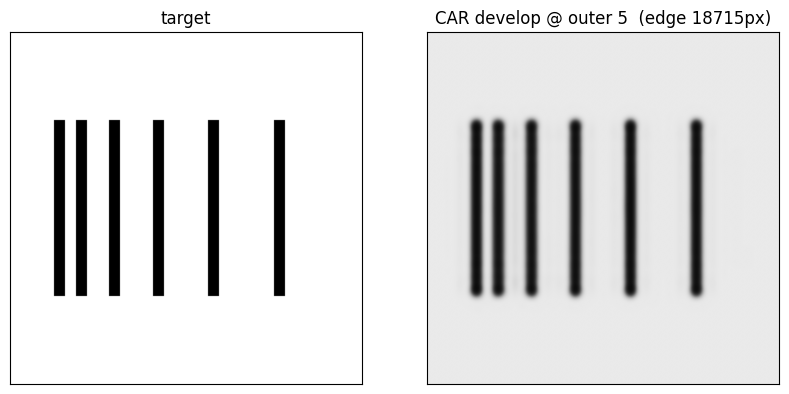

  outer  1/5: loss=0.01917  edge_px=23630
  outer  2/5: loss=0.01874  edge_px=22579
  outer  3/5: loss=0.01841  edge_px=19755
  outer  4/5: loss=0.01821  edge_px=18626
  outer  5/5: loss=0.01802  edge_px=18715
  MRC (mmfs_px=3): min feature = 23.4 nm mask = 5.86 nm wafer; 946/4194304 pixels flipped by opening+closing
  + 2 source polish steps: edge_px 18657 → 19507
  DOE project (smooth σ=0.100 (mean-nn spacing), quantize→2 levels): edge_px 19507 → 19464   active mirrors 15/69

mask_opt unique values: [0. 1.]
binary? True
freeform source: 69 candidates, 15 active after optimization (seed had 69). Growth beyond the seed = true free-form.


In [40]:
# @title 8.7.1 SMO Run onselected Reticle/DOE pair
# --- SMO demo (FREEFORM): let the DOE grow into a true free-form source -------
# Same driver as before, but with freeform=True so the source can ADD new pupil
# regions, not just carve a sub-shape out of the starting DOE.
#
# The starting DOE (from your Stage-1 selection) now acts only as a SEED / warm
# start — the optimizer is free to move power anywhere in the pupil.

SMO_TARGET = RETICLE
target     = make_target(SMO_TARGET)

try:
    src_start = doe_source
    _picked   = doe_shape_name
except NameError:
    src_start = quadrupole(0.7, 0.2, n=11)
    _picked   = "quadrupole(0.7,0.2,n=11) [default]"

mask_start = make_reticle(SMO_TARGET)
print(f"SMO (freeform) seed source = {_picked}  ({len(src_start)} points).")

printed_before = print_pattern(src_start, mask_start)

mmfs_px = 3
source_smooth = True
source_levels = 2

src_opt, mask_opt, history = smo(
    target, src_start, mask_start,
    n_outer=5, n_mask_steps=12, mask_lr=0.4,
    binarize=True, binarize_polish_steps=2,
    mmfs_px=mmfs_px,
    source_smooth=source_smooth, source_levels=source_levels,
    # --- FREEFORM SOURCE -----------------------------------------------------
    freeform=False,        # <-- the source can now GROW anywhere in the pupil
    freeform_n=21,        # candidate-grid density over the FULL pupil (21x21)
    freeform_floor=1e-3,  # tiny non-zero seed on every candidate so it can rise
    source_lr=0.15,       # additive source step size
    preview_every=1, preview_full=False)

_mvals = _np.unique(to_cpu(xp.abs(mask_opt)))
print(f"\nmask_opt unique values: {_mvals}")
print(f"binary? {set(_mvals.round(6).tolist()) <= {0.0, 1.0}}")

printed_after = print_pattern(src_opt, mask_opt)

# how much did the source change vs the seed?
_n_active = int((_np.asarray(src_opt[:,2]) > 1e-3).sum())
print(f"freeform source: {len(src_opt)} candidates, {_n_active} active after optimization "
      f"(seed had {len(src_start)}). Growth beyond the seed = false, no free-form.")

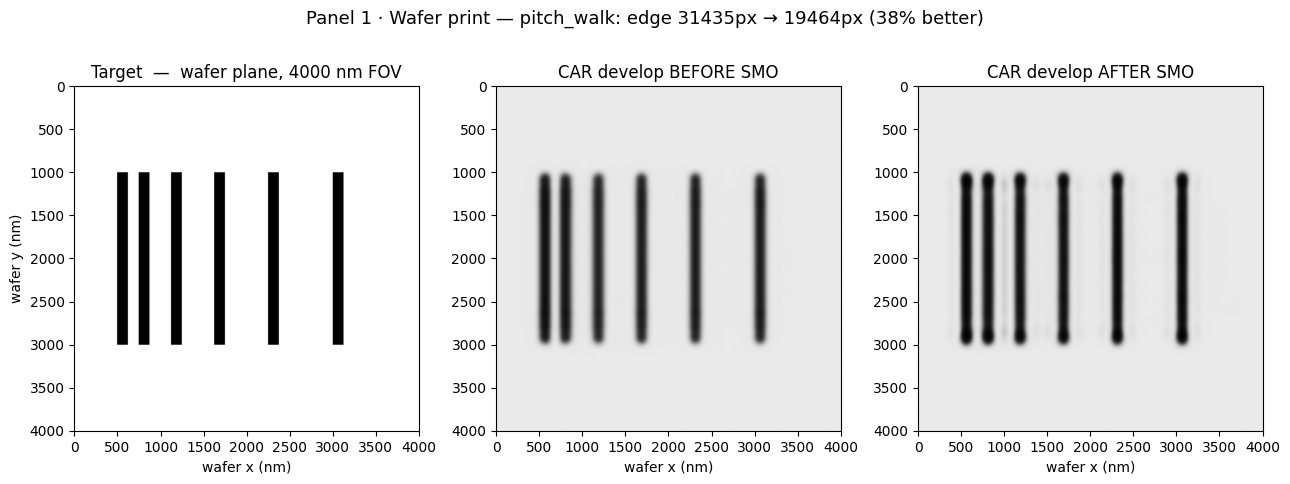

In [41]:
# @title 8.7.1a · Panel 1 — Target / Printed BEFORE / Printed AFTER (wafer plane)
# Three wafer-plane images: the target, the print before SMO, and after SMO.
_W_wafer   = N * dx_wafer * 1e9
_ext_wafer = [0.0, _W_wafer, _W_wafer, 0.0]      # [left,right,bottom,top], top-down

fig, ax = plt.subplots(1, 3, figsize=(13, 4.6))

ax[0].imshow(target,         cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[0].set_title(f"Target  —  wafer plane, {_W_wafer:.0f} nm FOV")
ax[1].imshow(printed_before, cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[1].set_title("CAR develop BEFORE SMO")
ax[2].imshow(printed_after,  cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[2].set_title("CAR develop AFTER SMO")

ax[0].set_ylabel("wafer y (nm)")
for _a in ax: _a.set_xlabel("wafer x (nm)")

eb = edge_error_px(printed_before, target)
ea = edge_error_px(printed_after,  target)
plt.suptitle(f"Panel 1 · Wafer print — {SMO_TARGET}: edge {eb:.0f}px → {ea:.0f}px "
             f"({100*(eb-ea)/max(eb,1):.0f}% better)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

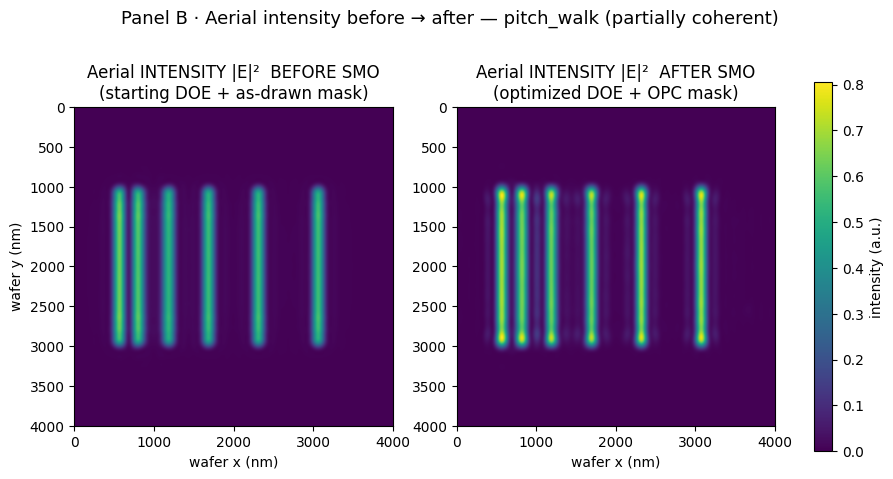

Both panels share one color scale, so brightness is directly comparable.
Amplitude & phase are omitted by physics: each full-DOE image is an
incoherent sum of many angles — no single complex field, only intensity.


In [42]:
# @title 8.7.1b · SMO result — aerial INTENSITY BEFORE vs AFTER (bottom panel)
# The partially-coherent aerial intensity |E|^2 at the wafer, for the starting
# source+mask (BEFORE) and the optimized source+mask (AFTER). Both are the Abbe
# incoherent sum over all DOE angles.
#
# PHYSICS NOTE: each source here is a FULL DOE — an incoherent sum of many
# illumination angles. After summing intensities there is NO single complex
# field, so AMPLITUDE and PHASE are NOT defined for either image. Only intensity
# exists. (Amplitude/phase are meaningful only for one coherent angle; see 6.3.1.)
# Hence this panel is intensity-only, by physics, not by omission.

_I_before = forward(src_start, mask_start, pupil=PUPIL)     # partially-coherent |E|^2
_I_after  = forward(src_opt,   mask_opt,   pupil=PUPIL)

_W_wafer = N * dx_wafer * 1e9
_ext = [0.0, _W_wafer, _W_wafer, 0.0]
_vmax = max(float(_I_before.max()), float(_I_after.max()))  # shared scale => fair compare

fig, ax = plt.subplots(1, 2, figsize=(10, 4.8))
im0 = ax[0].imshow(_I_before, cmap="viridis", extent=_ext, vmin=0, vmax=_vmax)
ax[0].set_title("Aerial INTENSITY |E|²  BEFORE SMO\n(starting DOE + as-drawn mask)")
im1 = ax[1].imshow(_I_after,  cmap="viridis", extent=_ext, vmin=0, vmax=_vmax)
ax[1].set_title("Aerial INTENSITY |E|²  AFTER SMO\n(optimized DOE + OPC mask)")

ax[0].set_ylabel("wafer y (nm)")
for _a in ax: _a.set_xlabel("wafer x (nm)")
plt.colorbar(im1, ax=ax, fraction=0.046, label="intensity (a.u.)")
plt.suptitle(f"Panel B · Aerial intensity before → after — {SMO_TARGET} "
             f"(partially coherent)", y=1.03, fontsize=13)
plt.show()

print("Both panels share one color scale, so brightness is directly comparable.")
print("Amplitude & phase are omitted by physics: each full-DOE image is an")
print("incoherent sum of many angles — no single complex field, only intensity.")

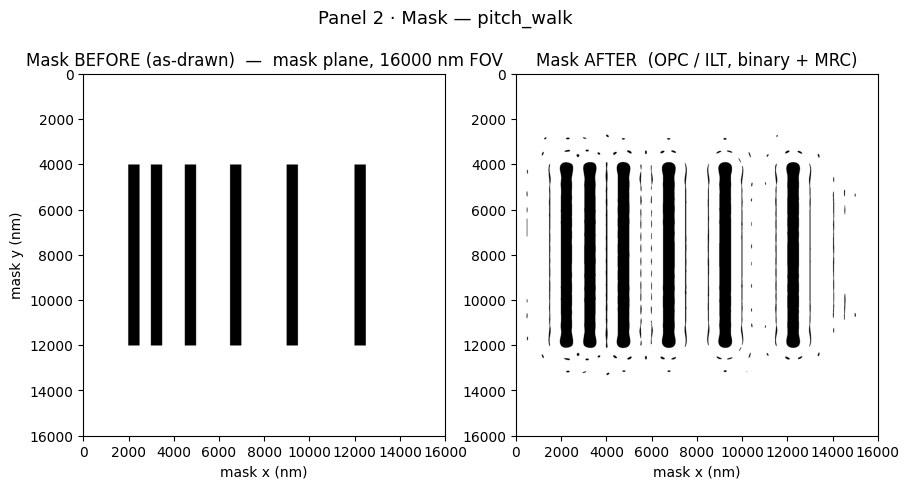

In [43]:
# @title 8.7.2b · Panel 2 — Mask BEFORE / AFTER (mask plane)
# The as-drawn reticle vs the OPC/ILT-optimized mask.
_W_mask   = N * dx_reticle * 1e9
_ext_mask = [0.0, _W_mask, _W_mask, 0.0]

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))

ax[0].imshow(to_cpu(xp.abs(mask_start)), cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
ax[0].set_title(f"Mask BEFORE (as-drawn)  —  mask plane, {_W_mask:.0f} nm FOV")

ax[1].imshow(to_cpu(xp.abs(mask_opt)),   cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
_is_bin = set(_np.unique(to_cpu(xp.abs(mask_opt))).round(6).tolist()) <= {0.0, 1.0}
_after_tag = "OPC / ILT, binary + MRC" if _is_bin else "OPC / ILT"
ax[1].set_title(f"Mask AFTER  ({_after_tag})")

ax[0].set_ylabel("mask y (nm)")
for _a in ax: _a.set_xlabel("mask x (nm)")

plt.suptitle(f"Panel 2 · Mask — {SMO_TARGET}", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

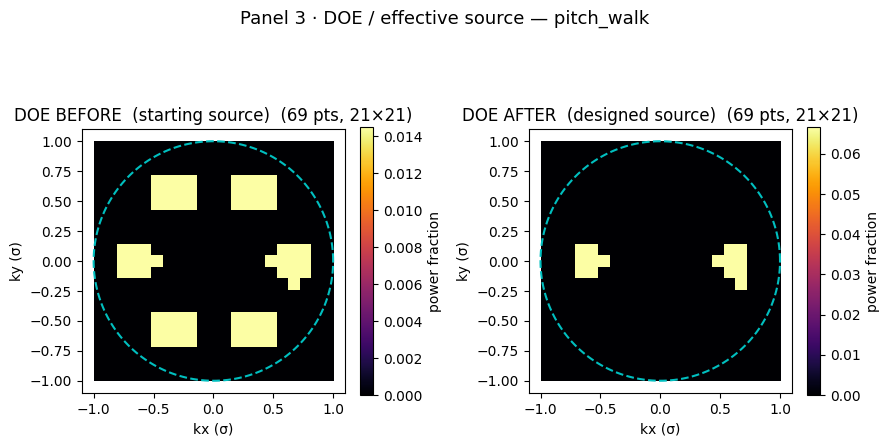

In [44]:
# @title 8.7.2c · Panel 3 — DOE (effective source) BEFORE / AFTER
# Starting DOE (seed) vs the designed source after SMO, in the pupil plane.
fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))

show_source_pupil_ax(src_start, ax[0], title="DOE BEFORE  (starting source)")
show_source_pupil_ax(src_opt,   ax[1], title="DOE AFTER  (designed source)")

plt.suptitle(f"Panel 3 · DOE / effective source — {SMO_TARGET}", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

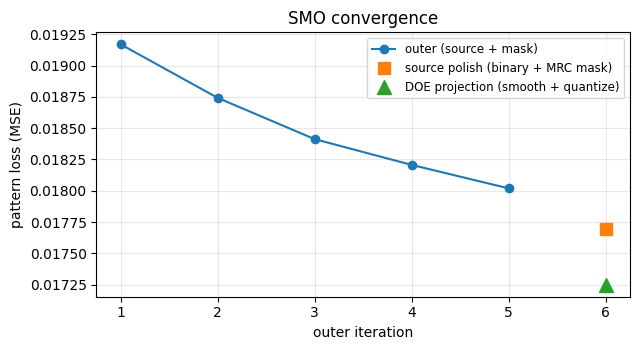

In [45]:
# @title 8.7.3 SMO convergence curve (Gradient Decent)

# --- SMO convergence curve ---------------------------------------------------
# FIX(#5): the figure styling that used to live here has moved up into the
# result-figure cell, where it can actually take effect.
# Three phases now appear in `history`:
#   1. outer iterations   — source + mask co-optimization (blue circles)
#   2. source polish      — source-only with binary + MRC mask fixed (orange
#                            square) — see §8.3.1
#   3. DOE projection     — post-polish source smoothing + level quantization
#                            (green triangle) — see §8.3.2
# The projection point typically shows a small step up in loss vs the polish
# — that's the manufacturability cost of projecting the DOE onto realizable
# hardware. That step is the "as-close-to-reality-as-possible" price.
_main    = [h for h in history if h.get("phase") not in ("polish", "doe_project")]
_polish  = [h for h in history if h.get("phase") == "polish"]
_project = [h for h in history if h.get("phase") == "doe_project"]

plt.figure(figsize=(6.5, 3.6))
plt.plot([h["outer"]+1 for h in _main],
         [h["loss"]    for h in _main],
         "o-", label="outer (source + mask)")
if _polish:
    plt.plot([h["outer"]+1 for h in _polish],
             [h["loss"]    for h in _polish],
             "s", markersize=9, color="tab:orange",
             label="source polish (binary + MRC mask)")
if _project:
    plt.plot([h["outer"]+1 for h in _project],
             [h["loss"]    for h in _project],
             "^", markersize=10, color="tab:green",
             label="DOE projection (smooth + quantize)")
if _polish or _project:
    plt.legend(loc="best", fontsize=8.5)
plt.xlabel("outer iteration"); plt.ylabel("pattern loss (MSE)")
plt.title("SMO convergence"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


The convergence curve plots the loss (and edge error) at successive stages of the SMO run. The x-axis is the sequence of stages; there are three kinds of point, logged into `history` with different `phase` tags.

* Reading the curve
- **Downhill `outer` points** = gradient descent working (mask + source co-optimized against a smooth objective).
- **`source polish` point** = recovery after the mask is forced binary + MRC'd.
- **`DOE projection` point** = the final, hardware-realizable result (expect a small penalty vs the ideal).

So the curve tells a story: descend to a good ideal solution (outer), then pay a small, partially-recovered cost to make both mask and source **manufacturable** (polish, then projection). The last point is the number that actually matters for a real process.

### 8.8 SMO for selected Reticle/DOE pair with FreeForm DOEs

This is where we execute the complete SMO engine to get the OPC mask and Freeform DOE

Because we have FreeForm DOEs, the starting shape is much less important.

SMO (freeform) seed source = hexapole (6 poles, 60°)  (69 points).


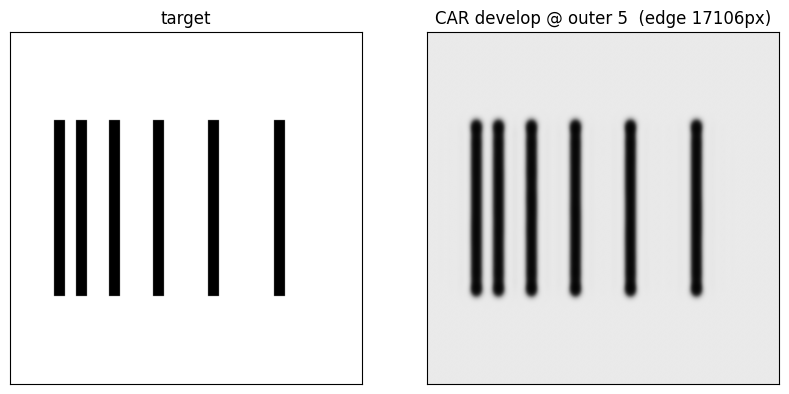

  outer  1/5: loss=0.01707  edge_px=27550
  outer  2/5: loss=0.01619  edge_px=24223
  outer  3/5: loss=0.01585  edge_px=20434
  outer  4/5: loss=0.01584  edge_px=17124
  outer  5/5: loss=0.01585  edge_px=17106
  MRC (mmfs_px=3): min feature = 23.4 nm mask = 5.86 nm wafer; 3/4194304 pixels flipped by opening+closing
  + 2 source polish steps: edge_px 17110 → 16757
  DOE project (smooth σ=0.100 (mean-nn spacing), quantize→2 levels): edge_px 16757 → 22909   active mirrors 87/313

mask_opt unique values: [0. 1.]
binary? True
freeform source: 313 candidates, 87 active after optimization (seed had 69). Growth beyond the seed = true free-form.


In [46]:
# @title 8.8.1 SMO Run onselected Reticle/DOE pair
# --- SMO demo (FREEFORM): let the DOE grow into a true free-form source -------
# Same driver as before, but with freeform=True so the source can ADD new pupil
# regions, not just carve a sub-shape out of the starting DOE.
#
# The starting DOE (from your Stage-1 selection) now acts only as a SEED / warm
# start — the optimizer is free to move power anywhere in the pupil.

SMO_TARGET = RETICLE
target     = make_target(SMO_TARGET)

try:
    src_start = doe_source
    _picked   = doe_shape_name
except NameError:
    src_start = quadrupole(0.7, 0.2, n=11)
    _picked   = "quadrupole(0.7,0.2,n=11) [default]"

mask_start = make_reticle(SMO_TARGET)
print(f"SMO (freeform) seed source = {_picked}  ({len(src_start)} points).")

printed_before = print_pattern(src_start, mask_start)

mmfs_px = 3
source_smooth = True
source_levels = 2

src_opt, mask_opt, history = smo(
    target, src_start, mask_start,
    n_outer=5, n_mask_steps=12, mask_lr=0.4,
    binarize=True, binarize_polish_steps=2,
    mmfs_px=mmfs_px,
    source_smooth=source_smooth, source_levels=source_levels,
    # --- FREEFORM SOURCE -----------------------------------------------------
    freeform=True,        # <-- the source can now GROW anywhere in the pupil
    freeform_n=21,        # candidate-grid density over the FULL pupil (21x21)
    freeform_floor=1e-3,  # tiny non-zero seed on every candidate so it can rise
    source_lr=0.15,       # additive source step size
    preview_every=1, preview_full=False)

_mvals = _np.unique(to_cpu(xp.abs(mask_opt)))
print(f"\nmask_opt unique values: {_mvals}")
print(f"binary? {set(_mvals.round(6).tolist()) <= {0.0, 1.0}}")

printed_after = print_pattern(src_opt, mask_opt)

# how much did the source change vs the seed?
_n_active = int((_np.asarray(src_opt[:,2]) > 1e-3).sum())
print(f"freeform source: {len(src_opt)} candidates, {_n_active} active after optimization "
      f"(seed had {len(src_start)}). Growth beyond the seed = true free-form.")

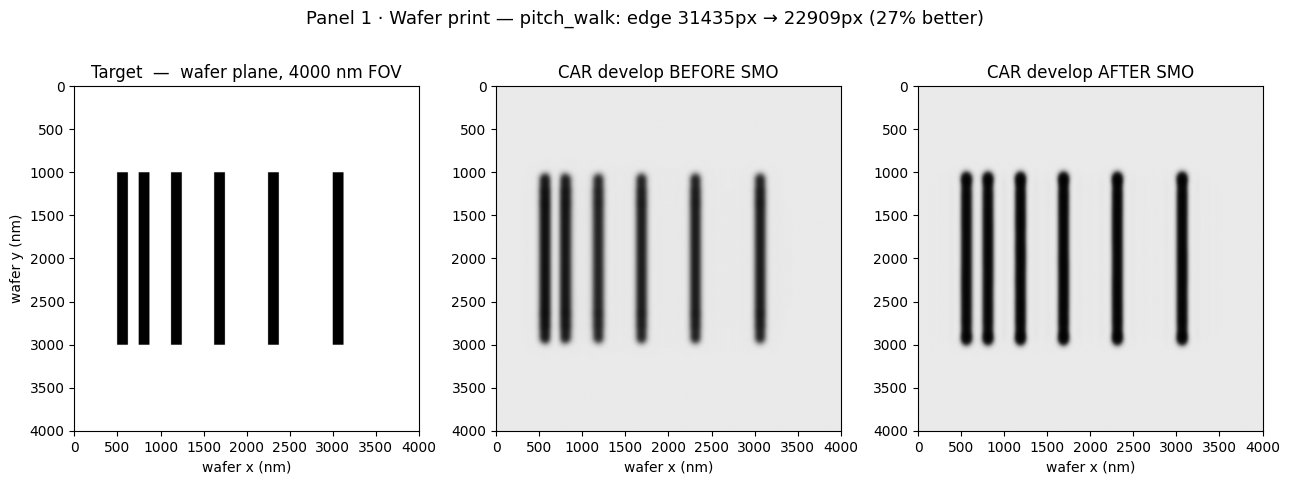

In [47]:
# @title 8.8.1a · Panel 1 — Target / Printed BEFORE / Printed AFTER (wafer plane)
# Three wafer-plane images: the target, the print before SMO, and after SMO.
_W_wafer   = N * dx_wafer * 1e9
_ext_wafer = [0.0, _W_wafer, _W_wafer, 0.0]      # [left,right,bottom,top], top-down

fig, ax = plt.subplots(1, 3, figsize=(13, 4.6))

ax[0].imshow(target,         cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[0].set_title(f"Target  —  wafer plane, {_W_wafer:.0f} nm FOV")
ax[1].imshow(printed_before, cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[1].set_title("CAR develop BEFORE SMO")
ax[2].imshow(printed_after,  cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[2].set_title("CAR develop AFTER SMO")

ax[0].set_ylabel("wafer y (nm)")
for _a in ax: _a.set_xlabel("wafer x (nm)")

eb = edge_error_px(printed_before, target)
ea = edge_error_px(printed_after,  target)
plt.suptitle(f"Panel 1 · Wafer print — {SMO_TARGET}: edge {eb:.0f}px → {ea:.0f}px "
             f"({100*(eb-ea)/max(eb,1):.0f}% better)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

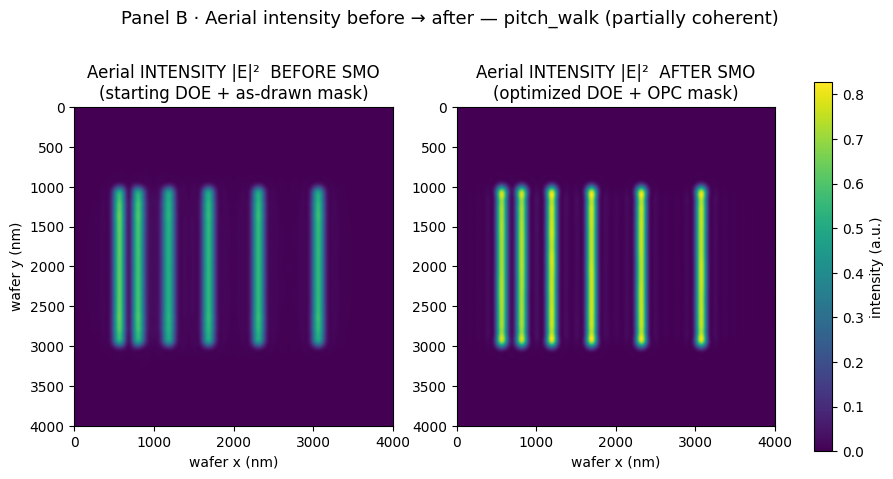

Both panels share one color scale, so brightness is directly comparable.
Amplitude & phase are omitted by physics: each full-DOE image is an
incoherent sum of many angles — no single complex field, only intensity.


In [48]:
# @title 8.8.1b · SMO result — aerial INTENSITY BEFORE vs AFTER (bottom panel)
# The partially-coherent aerial intensity |E|^2 at the wafer, for the starting
# source+mask (BEFORE) and the optimized source+mask (AFTER). Both are the Abbe
# incoherent sum over all DOE angles.
#
# PHYSICS NOTE: each source here is a FULL DOE — an incoherent sum of many
# illumination angles. After summing intensities there is NO single complex
# field, so AMPLITUDE and PHASE are NOT defined for either image. Only intensity
# exists. (Amplitude/phase are meaningful only for one coherent angle; see 6.3.1.)
# Hence this panel is intensity-only, by physics, not by omission.

_I_before = forward(src_start, mask_start, pupil=PUPIL)     # partially-coherent |E|^2
_I_after  = forward(src_opt,   mask_opt,   pupil=PUPIL)

_W_wafer = N * dx_wafer * 1e9
_ext = [0.0, _W_wafer, _W_wafer, 0.0]
_vmax = max(float(_I_before.max()), float(_I_after.max()))  # shared scale => fair compare

fig, ax = plt.subplots(1, 2, figsize=(10, 4.8))
im0 = ax[0].imshow(_I_before, cmap="viridis", extent=_ext, vmin=0, vmax=_vmax)
ax[0].set_title("Aerial INTENSITY |E|²  BEFORE SMO\n(starting DOE + as-drawn mask)")
im1 = ax[1].imshow(_I_after,  cmap="viridis", extent=_ext, vmin=0, vmax=_vmax)
ax[1].set_title("Aerial INTENSITY |E|²  AFTER SMO\n(optimized DOE + OPC mask)")

ax[0].set_ylabel("wafer y (nm)")
for _a in ax: _a.set_xlabel("wafer x (nm)")
plt.colorbar(im1, ax=ax, fraction=0.046, label="intensity (a.u.)")
plt.suptitle(f"Panel B · Aerial intensity before → after — {SMO_TARGET} "
             f"(partially coherent)", y=1.03, fontsize=13)
plt.show()

print("Both panels share one color scale, so brightness is directly comparable.")
print("Amplitude & phase are omitted by physics: each full-DOE image is an")
print("incoherent sum of many angles — no single complex field, only intensity.")

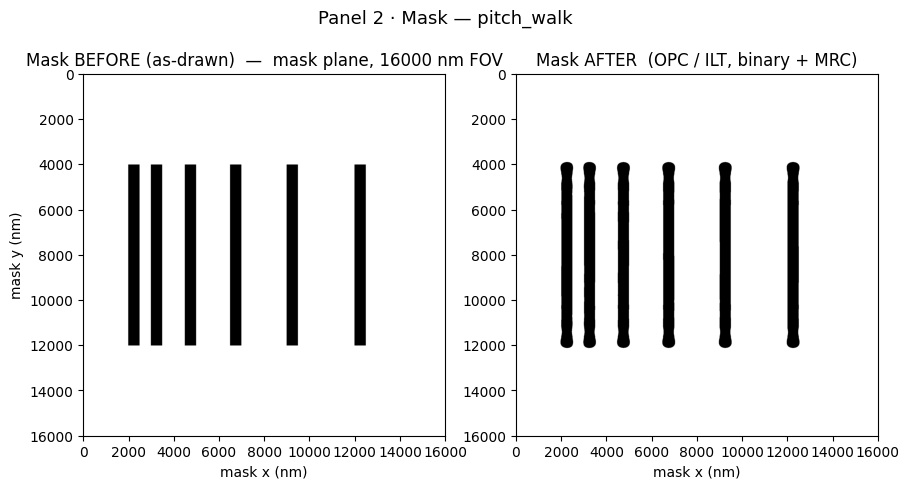

In [49]:
# @title 8.8.2b · Panel 2 — Mask BEFORE / AFTER (mask plane)
# The as-drawn reticle vs the OPC/ILT-optimized mask.
_W_mask   = N * dx_reticle * 1e9
_ext_mask = [0.0, _W_mask, _W_mask, 0.0]

fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))

ax[0].imshow(to_cpu(xp.abs(mask_start)), cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
ax[0].set_title(f"Mask BEFORE (as-drawn)  —  mask plane, {_W_mask:.0f} nm FOV")

ax[1].imshow(to_cpu(xp.abs(mask_opt)),   cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
_is_bin = set(_np.unique(to_cpu(xp.abs(mask_opt))).round(6).tolist()) <= {0.0, 1.0}
_after_tag = "OPC / ILT, binary + MRC" if _is_bin else "OPC / ILT"
ax[1].set_title(f"Mask AFTER  ({_after_tag})")

ax[0].set_ylabel("mask y (nm)")
for _a in ax: _a.set_xlabel("mask x (nm)")

plt.suptitle(f"Panel 2 · Mask — {SMO_TARGET}", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

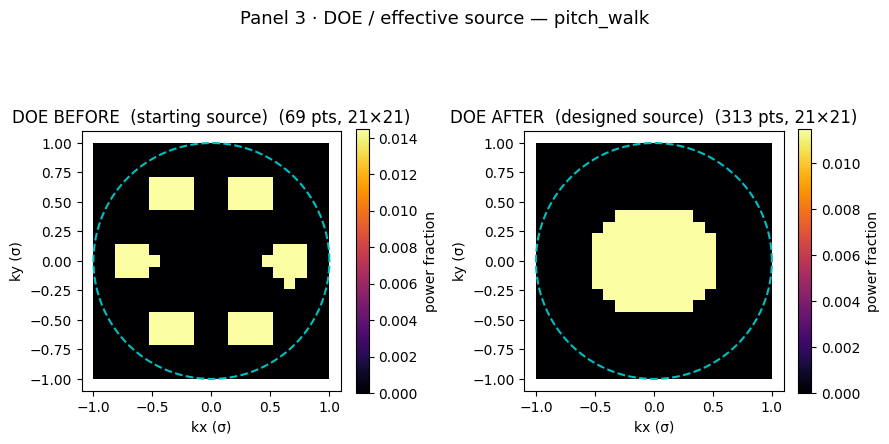

In [50]:
# @title 8.8.2c · Panel 3 — DOE (effective source) BEFORE / AFTER
# Starting DOE (seed) vs the designed source after SMO, in the pupil plane.
fig, ax = plt.subplots(1, 2, figsize=(9, 4.6))

show_source_pupil_ax(src_start, ax[0], title="DOE BEFORE  (starting source)")
show_source_pupil_ax(src_opt,   ax[1], title="DOE AFTER  (designed source)")

plt.suptitle(f"Panel 3 · DOE / effective source — {SMO_TARGET}", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

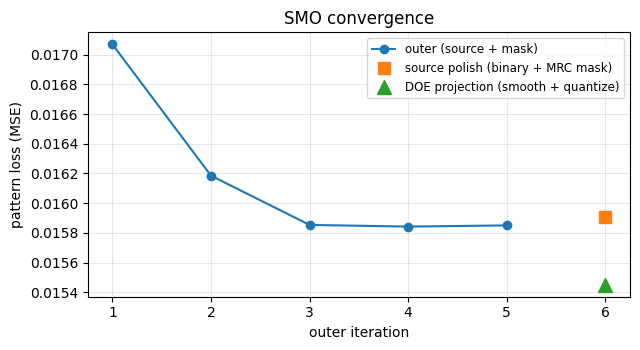

In [51]:
# @title 8.8.3 SMO convergence curve (Gradient Decent)

# --- SMO convergence curve ---------------------------------------------------
# FIX(#5): the figure styling that used to live here has moved up into the
# result-figure cell, where it can actually take effect.
# Three phases now appear in `history`:
#   1. outer iterations   — source + mask co-optimization (blue circles)
#   2. source polish      — source-only with binary + MRC mask fixed (orange
#                            square) — see §8.3.1
#   3. DOE projection     — post-polish source smoothing + level quantization
#                            (green triangle) — see §8.3.2
# The projection point typically shows a small step up in loss vs the polish
# — that's the manufacturability cost of projecting the DOE onto realizable
# hardware. That step is the "as-close-to-reality-as-possible" price.
_main    = [h for h in history if h.get("phase") not in ("polish", "doe_project")]
_polish  = [h for h in history if h.get("phase") == "polish"]
_project = [h for h in history if h.get("phase") == "doe_project"]

plt.figure(figsize=(6.5, 3.6))
plt.plot([h["outer"]+1 for h in _main],
         [h["loss"]    for h in _main],
         "o-", label="outer (source + mask)")
if _polish:
    plt.plot([h["outer"]+1 for h in _polish],
             [h["loss"]    for h in _polish],
             "s", markersize=9, color="tab:orange",
             label="source polish (binary + MRC mask)")
if _project:
    plt.plot([h["outer"]+1 for h in _project],
             [h["loss"]    for h in _project],
             "^", markersize=10, color="tab:green",
             label="DOE projection (smooth + quantize)")
if _polish or _project:
    plt.legend(loc="best", fontsize=8.5)
plt.xlabel("outer iteration"); plt.ylabel("pattern loss (MSE)")
plt.title("SMO convergence"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


The convergence curve plots the loss (and edge error) at successive stages of the SMO run. The x-axis is the sequence of stages; there are three kinds of point, logged into `history` with different `phase` tags.

* Reading the curve
- **Downhill `outer` points** = gradient descent working (mask + source co-optimized against a smooth objective).
- **`source polish` point** = recovery after the mask is forced binary + MRC'd.
- **`DOE projection` point** = the final, hardware-realizable result (expect a small penalty vs the ideal).

So the curve tells a story: descend to a good ideal solution (outer), then pay a small, partially-recovered cost to make both mask and source **manufacturable** (polish, then projection). The last point is the number that actually matters for a real process.

##9 · SMO sweep — try every starting pupil, pick the winner (Without Free Form)


This reduces computation where the final DOE is a subset of the starting DOE. But it allows for brute force approachs.

Different starting pupils bias the SMO toward different local minima. A dipole
start locks in a two-pole DOE early; an annular start lets the optimizer keep
more angular content and might discover a quadrupole is better; a conventional
start is fully symmetric and hardest to break. The best starting pupil depends
on the target — there's no universal answer.

`smo_sweep()` runs SMO on every constructor in the library at fixed `n=11`
(so each candidate source has ~15–30 points), collects the final edge error
of each, and returns the winner along with all results for comparison. The
visualizer `show_smo_sweep()` renders each starting pupil beside its final
optimized DOE so you can see how much the optimizer moved from each start.

**Restriction to `n=11`.** Total sweep runtime = 9 candidates × one SMO run.
At `n=11` each SMO takes 3–5 minutes on CPU (dominated by the outer loop's
forward passes over the ~15–30 source points); nine sweeps takes 25–45 min.
Bumping `n` to 21 quadruples the point count and pushes the sweep past two
hours, which is why the runner refuses `n≠11` by default. Change the internal
check if you accept the wait, or run on GPU where each SMO takes ~30 s.


In [52]:
# @title 9.1 SMO sweeper (without Freeform support)
# --- SMO sweep: try every starting pupil at n=11, pick the winner ------------
# See §8.5 for the rationale. Runs SMO nine times (one per candidate starting
# pupil) and reports which start converges to the lowest edge_px. Restricted
# to n_pupil=11 to keep the total sweep time under an hour on CPU.

def smo_sweep(target, mask_start, candidates=None, n_pupil=61,
              n_outer=5, n_mask_steps=12, mask_lr=0.4,
              binarize=True, binarize_polish_steps=2, mmfs_px=3,
              source_smooth=True, source_levels=2, verbose=True):
    """Run SMO on every starting pupil in `candidates`, return the winner.

    Returns
    -------
    best     : dict with keys name, src_start, src_opt, mask_opt, history,
               final_edge_px — the candidate with the lowest final edge_px.
    results  : list of the same dicts, sorted best-first.

    Restricted to n_pupil=11 for total-sweep-time reasons (see §8.5); raise
    a ValueError otherwise so the restriction is explicit.
    """
    if n_pupil != 11:
        raise ValueError(
            f"smo_sweep is restricted to n_pupil=11 for total sweep runtime "
            f"(9 SMOs × ~3–5 min each on CPU). Got {n_pupil}. Change the "
            f"internal check if you accept the wait, or run on GPU.")

    if candidates is None:
        candidates = {
            "conventional_07": conventional(0.7, n=n_pupil),
            "annular_04_08":   annular(0.4, 0.8, n=n_pupil),
            "x_dipole":        dipole(0.7, 0.2, angle_deg=0, n=n_pupil),
            "y_dipole":        y_dipole(0.7, 0.2, n=n_pupil),
            "quadrupole":      quadrupole(0.7, 0.2, n=n_pupil),
            "cquad":           cquad(0.7, 0.2, n=n_pupil),
            "hexapole":        hexapole(0.7, 0.2, n=n_pupil),
            "elliptical":      elliptical(0.8, 0.3, n=n_pupil),
            "off_axis_45":     off_axis(0.7, 0.3, angle_deg=45, n=n_pupil),
        }

    results = []
    n_cand = len(candidates)
    import time as _time
    t_all = _time.perf_counter()
    for i, (name, src_start) in enumerate(candidates.items()):
        n_pts = src_start.shape[0]
        if verbose:
            print(f"[{i+1:>2d}/{n_cand}] {name:<20s} ({n_pts:>3d} src pts) ... ",
                  end="", flush=True)
        t0 = _time.perf_counter()
        src_opt, mask_opt, history = smo(
            target, src_start, mask_start,
            n_outer=n_outer, n_mask_steps=n_mask_steps, mask_lr=mask_lr,
            binarize=binarize, binarize_polish_steps=binarize_polish_steps,
            mmfs_px=mmfs_px, source_smooth=source_smooth,
            source_levels=source_levels,
            preview_every=0, verbose=False)
        dt = _time.perf_counter() - t0
        final_edge = history[-1]['epe_px']
        results.append({
            "name": name, "src_start": src_start,
            "src_opt": src_opt, "mask_opt": mask_opt,
            "history": history, "final_edge_px": final_edge,
        })
        if verbose:
            print(f"final edge_px = {final_edge:>6.0f}   ({dt:>5.1f}s)")

    results.sort(key=lambda r: r["final_edge_px"])
    best = results[0]
    if verbose:
        print(f"\ntotal sweep time: {(_time.perf_counter()-t_all)/60:.1f} min")
        print("=" * 60)
        print("SMO SWEEP RESULTS (best → worst)")
        print("=" * 60)
        for r in results:
            tag = "  <-- BEST" if r is best else ""
            print(f"  {r['name']:<20s}  edge_px = {r['final_edge_px']:>6.0f}{tag}")
    return best, results


def show_smo_sweep(results, best=None):
    """Grid: for each candidate, its starting pupil (left) and the SMO-designed
    DOE it converged to (right). Winner is starred."""
    if best is None:
        best = results[0]
    n = len(results)
    fig, ax = plt.subplots(n, 2, figsize=(9.0, 3.1 * n))
    if n == 1: ax = ax.reshape(1, 2)
    th = _np.linspace(0, 2 * _np.pi, 200)
    for i, r in enumerate(results):
        star = "★ " if r is best else "  "
        # starting pupil
        w0 = r["src_start"][:, 2] / r["src_start"][:, 2].sum()
        ax[i, 0].scatter(r["src_start"][:, 0], r["src_start"][:, 1],
                         c=w0, cmap="viridis", s=70, vmin=0, vmax=w0.max())
        ax[i, 0].plot(_np.cos(th), _np.sin(th), "c--", lw=0.8)
        ax[i, 0].set_aspect("equal")
        ax[i, 0].set_xlim(-1.1, 1.1); ax[i, 0].set_ylim(-1.1, 1.1)
        ax[i, 0].set_title(f"{star}Start: {r['name']}  ({r['src_start'].shape[0]} pts)",
                           fontsize=10)
        # final DOE
        w1 = r["src_opt"][:, 2] / r["src_opt"][:, 2].sum()
        ax[i, 1].scatter(r["src_opt"][:, 0], r["src_opt"][:, 1],
                         c=w1, cmap="viridis", s=70, vmin=0, vmax=w1.max())
        ax[i, 1].plot(_np.cos(th), _np.sin(th), "c--", lw=0.8)
        ax[i, 1].set_aspect("equal")
        ax[i, 1].set_xlim(-1.1, 1.1); ax[i, 1].set_ylim(-1.1, 1.1)
        ax[i, 1].set_title(f"{star}Final DOE — edge_px = {r['final_edge_px']:.0f}",
                           fontsize=10)
    plt.suptitle("SMO sweep — starting pupil (left) → final DOE (right); ★ = winner",
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.show()

# --- Sweep example: try every starting pupil, then re-run §8.4 with winner ---
# WARNING: sweep is 25–45 min on CPU (nine SMOs at n=11); ~1 min on GPU.
#
# Set RUN_SWEEP = True to actually run the sweep. Default is False so the
# cell can be re-run without accidentally starting a long computation.
# The cell prints a banner in both states so you always know which path
# it took — no more silent "did the sweep run?" ambiguity.

RUN_SWEEP = True   # <-- CHANGE TO True TO RUN THE SWEEP

if RUN_SWEEP:
    print("=" * 68)
    print(" STARTING SMO SWEEP  —  9 pupils × ~3–5 min each = 25–45 min CPU")
    print("=" * 68)
    best_result, all_results = smo_sweep(
        target, mask_start,
        n_pupil=11,           # fixed by smo_sweep; do not change
        n_outer=5, n_mask_steps=12, mask_lr=0.4,
        binarize=True, binarize_polish_steps=2, mmfs_px=3,
        source_smooth=True, source_levels=2)

    # Adopt the winning starting pupil for the §8.5.1 rerun below.
    src_start   = best_result['src_start']
    winner_name = best_result['name']
    n_pts_win   = src_start.shape[0]

    print()
    print("=" * 68)
    print(f" SWEEP COMPLETE.  Winner: '{winner_name}'  "
          f"({n_pts_win} pts,  edge_px = {best_result['final_edge_px']:.0f})")
    print(f" `best_result` and `src_start` are now set in this kernel.")
    print(f" Next: run the §8.5.1 cells below to execute §8.4 with this pupil.")
    print("=" * 68)
else:
    print("=" * 68)
    print(" RUN_SWEEP = False  —  sweep is DISABLED, nothing to do.")
    print("")
    print(" To enable:")
    print("   1. Change  RUN_SWEEP = False  to  RUN_SWEEP = True  (line above).")
    print("   2. Re-run THIS cell.  Sweep takes 25–45 min on CPU (~1 min GPU).")
    print("   3. Then run the §8.5.1 cells below.")
    print("")
    print(" Without a sweep, §8.5.1 will fall back to §8.4's default `src_start`")
    print(" (dipole 0.7, 0.2, n=11 → 4 pts) — that's the intended fallback,")
    print(" not a failure, but it means the sweep did not happen.")
    print("=" * 68)


 STARTING SMO SWEEP  —  9 pupils × ~3–5 min each = 25–45 min CPU
[ 1/9] conventional_07      ( 37 src pts) ... final edge_px =  20020   ( 33.3s)
[ 2/9] annular_04_08        ( 38 src pts) ... final edge_px =  16962   ( 33.9s)
[ 3/9] x_dipole             (  4 src pts) ... final edge_px =  14250   ( 19.0s)
[ 4/9] y_dipole             (  4 src pts) ... final edge_px =  62306   ( 19.0s)
[ 5/9] quadrupole           (  8 src pts) ... final edge_px =  23048   ( 21.1s)
[ 6/9] cquad                ( 16 src pts) ... final edge_px =  14330   ( 24.6s)
[ 7/9] hexapole             ( 12 src pts) ... final edge_px =  19868   ( 22.6s)
[ 8/9] elliptical           ( 19 src pts) ... final edge_px =  19168   ( 25.3s)
[ 9/9] off_axis_45          (  4 src pts) ... final edge_px =  13957   ( 18.9s)

total sweep time: 3.6 min
SMO SWEEP RESULTS (best → worst)
  off_axis_45           edge_px =  13957  <-- BEST
  x_dipole              edge_px =  14250
  cquad                 edge_px =  14330
  annular_04_08       

### 9.2 · Rerun with optimal DOE

The cells below are a copy of §8.4's Run SMO / result figure / convergence
cells, structured so §8.5.1 works in every combination of the two flags:

| sweep ran? | `REUSE_SWEEP` | behavior |
|:-----------|:-------------:|:---------|
| yes        | `False` (default) | re-executes `smo(...)` with the winner's starting pupil — same params as §8.4, ~3–5 min on CPU |
| yes        | `True`  | reuses the sweep's already-computed `src_opt` / `mask_opt` / `history` — instant |
| no         | either  | falls back to §8.4's default `src_start` (dipole) and runs smo() normally; `REUSE_SWEEP=True` is ignored and noted |

So you can run §8.5.1 standalone (equivalent to §8.4), or after the sweep to
run §8.4 with the winning pupil, and `REUSE_SWEEP=True` short-circuits the
redundant SMO call when the sweep already produced the answer.


In [53]:
# @title 9.3 Run SMO with optimal DOE
# --- §8.5.1 · Run SMO — copy of §8.4 -----------------------------------------
# Runs the same SMO + result-figure + convergence pipeline as §8.4. If the
# sweep in §8.5 has run, `src_start` comes from the winning starting pupil;
# otherwise this cell falls back to §8.4's default dipole and runs smo()
# normally, so §8.5.1 works standalone too.
#
# REUSE_SWEEP controls whether to re-execute smo() or reuse the sweep's
# precomputed result (only meaningful when the sweep has actually run):
#   False (default) → re-execute smo() (matches "letting the complete OPC
#                     run again"). Same params as §8.4. ~3–5 min on CPU.
#   True            → skip the redo and use sweep's src_opt/mask_opt/history
#                     directly. Instant. Ignored if no sweep result exists.

REUSE_SWEEP = True

# Which src_start to use? Winner from sweep if available, else §8.4 default.
_has_sweep = ('best_result' in dir()) and (best_result is not None)
if _has_sweep:
    src_start   = best_result['src_start']
    winner_name = best_result['name']
    print("=" * 68)
    print(f" §8.5.1: USING SWEEP WINNER  —  '{winner_name}' "
          f"({src_start.shape[0]} pts)")
    print(f" (Sweep completed with edge_px = "
          f"{best_result['final_edge_px']:.0f})")
    print("=" * 68)
else:
    src_start   = dipole(0.7, 0.2, angle_deg=0, n=11)   # §8.4 default
    winner_name = "dipole (§8.4 default)"
    print("=" * 68)
    print(" §8.5.1: NO SWEEP RESULT IN MEMORY  —  fallback to §8.4 default.")
    print(f"   src_start = dipole(0.7, 0.2, n=11) → {src_start.shape[0]} pts")
    print()
    print(" If you wanted to sweep first, here's the recipe:")
    print("   1. Scroll UP to the §8.5 sweep example cell.")
    print("   2. Change  RUN_SWEEP = False  →  RUN_SWEEP = True.")
    print("   3. Re-run that cell (25–45 min CPU, ~1 min GPU).")
    print("   4. Wait for the 'SWEEP COMPLETE' banner.")
    print("   5. Then re-run this §8.5.1 cell.")
    if REUSE_SWEEP:
        print()
        print("   NOTE: REUSE_SWEEP=True has no effect — no sweep result to reuse.")
        print("   smo() will run below with the fallback src_start.")
    print("=" * 68)

# baseline print (before optimization) — same as §8.4
printed_before = print_pattern(src_start, mask_start)

# --- MRC + DOE-realism knobs — same defaults as §8.4 -------------------------
mmfs_px       = 3
source_smooth = True
source_levels = 2

# Pixel → nm scale line — same as §8.4
print(f"scale: 1 mask px = {dx_reticle*1e9:.2f} nm mask = {dx_wafer*1e9:.3f} nm wafer   "
      f"|   mmfs_px={mmfs_px} → MRC minimum = "
      f"{mmfs_px*dx_reticle*1e9:.1f} nm mask ({mmfs_px*dx_wafer*1e9:.2f} nm wafer)")

# --- run SMO (or reuse) ------------------------------------------------------
if _has_sweep and REUSE_SWEEP:
    print("REUSE_SWEEP=True — reusing sweep's precomputed src_opt/mask_opt/history.")
    src_opt  = best_result['src_opt']
    mask_opt = best_result['mask_opt']
    history  = best_result['history']
else:
    src_opt, mask_opt, history = smo(
        target, src_start, mask_start,
        n_outer=5, n_mask_steps=12, mask_lr=0.4,
        binarize=True,                # strict-binary mask output
        binarize_polish_steps=2,      # source-only refinement after MRC
        mmfs_px=mmfs_px,              # morphological MRC — see §8.3.1
        source_smooth=source_smooth,  # k-space smoothing — see §8.3.2
        source_levels=source_levels,  # discrete brightness levels (2 = binary)
        preview_every=1,
        preview_full=False)

# --- sanity check: mask is truly binary --------------------------------------
_mvals = _np.unique(to_cpu(xp.abs(mask_opt)))
print(f"\nmask_opt unique values: {_mvals}")
print(f"binary? {set(_mvals.round(6).tolist()) <= {0.0, 1.0}}   "
      f"(count {len(_mvals)}; expected 2 for strict binary)")

# optimized print (after co-optimization)
printed_after = print_pattern(src_opt, mask_opt)


 §8.5.1: USING SWEEP WINNER  —  'off_axis_45' (4 pts)
 (Sweep completed with edge_px = 13957)
scale: 1 mask px = 7.81 nm mask = 1.953 nm wafer   |   mmfs_px=3 → MRC minimum = 23.4 nm mask (5.86 nm wafer)
REUSE_SWEEP=True — reusing sweep's precomputed src_opt/mask_opt/history.

mask_opt unique values: [0. 1.]
binary? True   (count 2; expected 2 for strict binary)


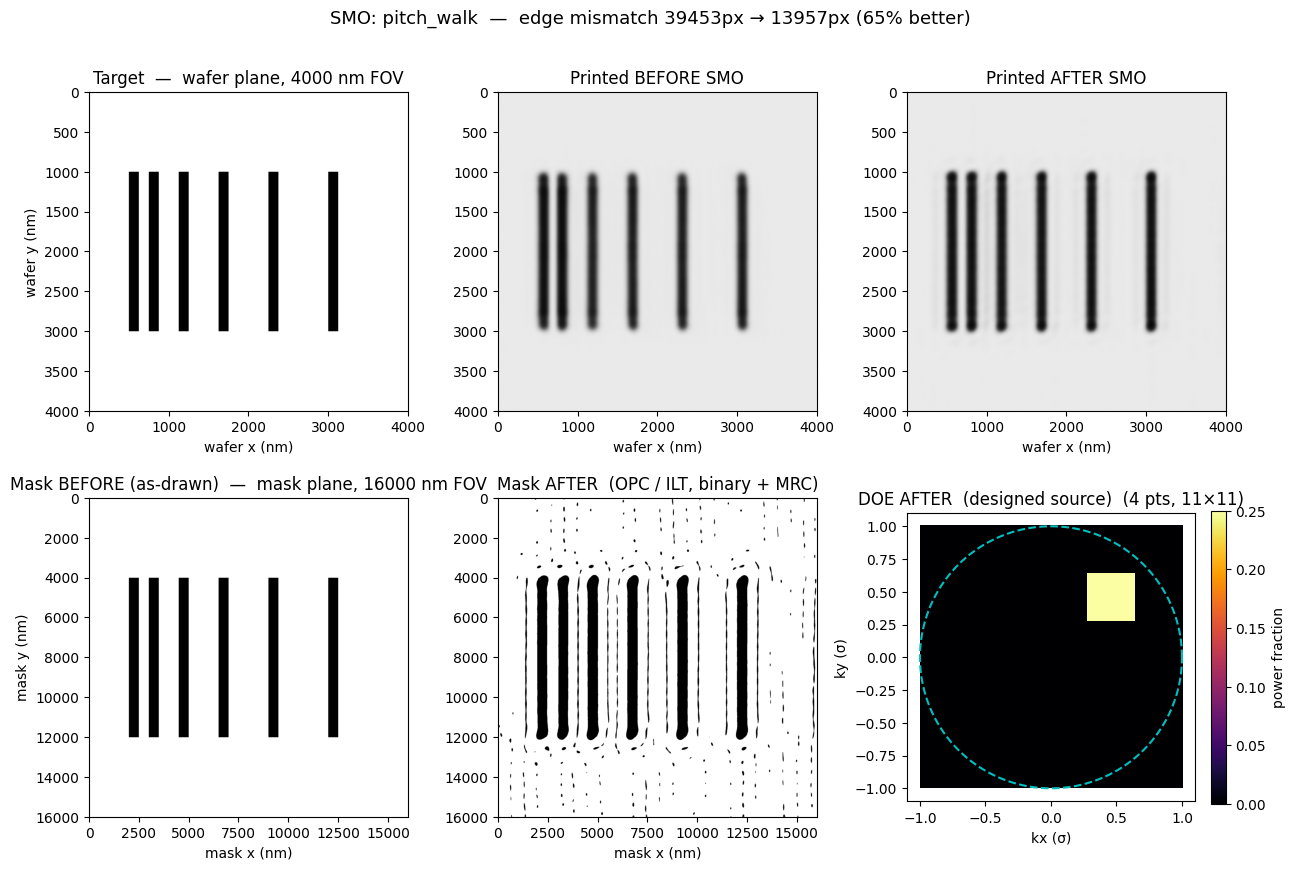

In [54]:
# @title 9.3.1 Run SMO Engine

# --- §8.5.1 result figure — verbatim copy of §8.4 -----------------------------
# Uses src_opt/mask_opt/printed_before/printed_after from the §8.5.1 demo
# cell above. If you edit §8.4's version, mirror the edit here (or refactor
# both to call a shared draw function).

# --- Visualize the SMO result: print quality, designed DOE, OPC'd mask -------
# FIX(#5): this figure used to be SPLIT ACROSS TWO CELLS. Colab's inline backend
# renders and closes a figure when its cell finishes, so the follow-up cell's
# suptitle / tick cleanup landed on a NEW empty figure and never appeared on
# these panels. Everything that touches `fig` now lives in this one cell.
# FIX(#6): removed the duplicate draws — Mask BEFORE/AFTER were imshow'd twice,
# and ax[1,2] was painted twice (a scatter + colorbar underneath, then
# show_source_pupil_ax + a second colorbar on top).
#
# NEW: all spatial panels now carry nm axes so you can read feature sizes
# directly off the ticks. Wafer plane (target/printed) spans N * dx_wafer
# nanometres; mask plane spans N * dx_reticle nanometres (4x larger).
fig, ax = plt.subplots(2, 3, figsize=(13, 8.6))

# Physical extents in nm (extent order = [left, right, bottom, top]; using
# top-down origin to preserve current visual orientation of the arrays).
_W_wafer = N * dx_wafer   * 1e9
_W_mask  = N * dx_reticle * 1e9
_ext_wafer = [0.0, _W_wafer, _W_wafer, 0.0]
_ext_mask  = [0.0, _W_mask,  _W_mask,  0.0]

ax[0,0].imshow(target,         cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[0,0].set_title(f"Target  —  wafer plane, {_W_wafer:.0f} nm FOV")
ax[0,1].imshow(printed_before, cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[0,1].set_title("Printed BEFORE SMO")
ax[0,2].imshow(printed_after,  cmap="gray_r", vmin=0, vmax=1, extent=_ext_wafer)
ax[0,2].set_title("Printed AFTER SMO")

ax[1,0].imshow(to_cpu(xp.abs(mask_start)), cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
ax[1,0].set_title(f"Mask BEFORE (as-drawn)  —  mask plane, {_W_mask:.0f} nm FOV")
ax[1,1].imshow(to_cpu(xp.abs(mask_opt)),   cmap="gray_r", vmin=0, vmax=1, extent=_ext_mask)
_is_bin = set(_np.unique(to_cpu(xp.abs(mask_opt))).round(6).tolist()) <= {0.0, 1.0}
_after_tag = "OPC / ILT, binary + MRC" if _is_bin else "OPC / ILT"
ax[1,1].set_title(f"Mask AFTER  ({_after_tag})")
show_source_pupil_ax(src_opt, ax[1,2])       # rasterized DOE pupil, one colorbar

# Axis labels: outer edges only, to avoid clutter
ax[0,0].set_ylabel("wafer y (nm)")
ax[1,0].set_ylabel("mask y (nm)")
for _a in [ax[0,0], ax[0,1], ax[0,2]]:  _a.set_xlabel("wafer x (nm)")
for _a in [ax[1,0], ax[1,1]]:           _a.set_xlabel("mask x (nm)")

eb = edge_error_px(printed_before, target)
ea = edge_error_px(printed_after,  target)
plt.suptitle(f"SMO: {SMO_TARGET}  —  edge mismatch {eb:.0f}px → {ea:.0f}px "
             f"({100*(eb-ea)/max(eb,1):.0f}% better)", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


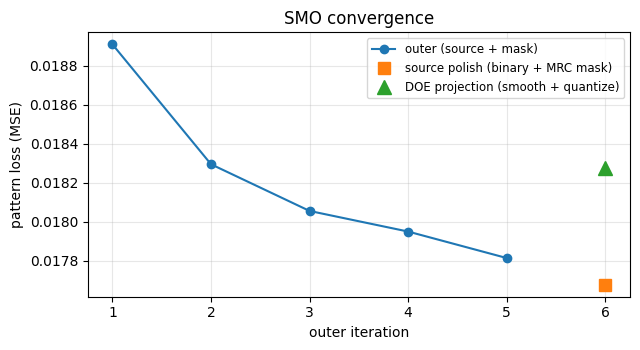

In [55]:
# @title 9.3.2 convergence curve for SMO
# --- §8.5.1 convergence curve — verbatim copy of §8.4 -------------------------
# Uses `history` from the §8.5.1 demo cell above.

# --- SMO convergence curve ---------------------------------------------------
# FIX(#5): the figure styling that used to live here has moved up into the
# result-figure cell, where it can actually take effect.
# Three phases now appear in `history`:
#   1. outer iterations   — source + mask co-optimization (blue circles)
#   2. source polish      — source-only with binary + MRC mask fixed (orange
#                            square) — see §8.3.1
#   3. DOE projection     — post-polish source smoothing + level quantization
#                            (green triangle) — see §8.3.2
# The projection point typically shows a small step up in loss vs the polish
# — that's the manufacturability cost of projecting the DOE onto realizable
# hardware. That step is the "as-close-to-reality-as-possible" price.
_main    = [h for h in history if h.get("phase") not in ("polish", "doe_project")]
_polish  = [h for h in history if h.get("phase") == "polish"]
_project = [h for h in history if h.get("phase") == "doe_project"]

plt.figure(figsize=(6.5, 3.6))
plt.plot([h["outer"]+1 for h in _main],
         [h["loss"]    for h in _main],
         "o-", label="outer (source + mask)")
if _polish:
    plt.plot([h["outer"]+1 for h in _polish],
             [h["loss"]    for h in _polish],
             "s", markersize=9, color="tab:orange",
             label="source polish (binary + MRC mask)")
if _project:
    plt.plot([h["outer"]+1 for h in _project],
             [h["loss"]    for h in _project],
             "^", markersize=10, color="tab:green",
             label="DOE projection (smooth + quantize)")
if _polish or _project:
    plt.legend(loc="best", fontsize=8.5)
plt.xlabel("outer iteration"); plt.ylabel("pattern loss (MSE)")
plt.title("SMO convergence"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


The convergence curve plots the loss (and edge error) at successive stages of the SMO run. The x-axis is the sequence of stages; there are three kinds of point, logged into `history` with different `phase` tags.

* Reading the curve
- **Downhill `outer` points** = gradient descent working (mask + source co-optimized against a smooth objective).
- **`source polish` point** = recovery after the mask is forced binary + MRC'd.
- **`DOE projection` point** = the final, hardware-realizable result (expect a small penalty vs the ideal).

So the curve tells a story: descend to a good ideal solution (outer), then pay a small, partially-recovered cost to make both mask and source **manufacturable** (polish, then projection). The last point is the number that actually matters for a real process.

## 10 · Legend (Understanding the SMO output & convergence)

A reference for reading what the SMO run prints and plots. Two parts:

- (A) every number in the text output
- (B) the three convergence stages.

###10.1 A - Reading the printed output

Example run:

```
loss=0.01707  edge_px=27550
MRC (mmfs_px=3):
  min feature = 23.4 nm
  mask = 5.86 nm wafer
  3/4194304 pixels flipped by opening+closing
+ 2 source polish steps: edge_px 17110 → 16757
DOE project (smooth σ=0.100 (mean-nn spacing), quantize→2 levels):
  edge_px 16757 → 22909   active mirrors 87/313
freeform source: 313 candidates, 87 active after optimization (seed had 69).
```

**The two headline numbers**

- **`loss=0.01707`** — the quantity minimized: mean-squared error between the printed (soft, resist-sigmoid) pattern and the target, averaged over all pixels. It is dimensionless. Lower values indicate a better fit of the solution, but the values are comparable only within the same run.

- **`edge_px=27550`** — edge-placement metric: number of pixels where the *thresholded* print disagrees with the target (an XOR area). Physically meaningful ("how many pixels
are wrong"), but NOT what the gradient minimizes — the hard threshold isn't differentiable. It is Reported to track progress. Being a raw pixel count, it scales with pattern size and grid resolution, so compare only within one run.

**MRC block — Mask Rule Check (mask manufacturability)**

After the gradient loop the mask is binarized to {0,1} and cleaned to obey a minimum-feature rule (a mask shop can't print arbitrarily thin slivers).
`mmfs_px=3` = a 3-pixel rule kernel.

- **`min feature = 23.4 nm`** — smallest feature now guaranteed, in *wafer* nm
  (3 px × wafer pixel size). Nothing narrower survives.
- **`mask = 5.86 nm wafer`** — size of one mask pixel at the wafer (one reticle pixel  ÷ 4× demag). The mask grid resolution.
- **`3/4194304 pixels flipped by opening+closing`** — MRC is a morphological *opening
  then closing* (remove tiny nubs, fill tiny gaps). Only 3 of ~4.19M pixels (a 2048²
  grid) changed — the optimized mask was already almost rule-clean. A large number
  here would mean a choppy mask that MRC had to heavily repair.

- **`+ 2 source polish steps: edge_px 17110 → 16757`** - Binarizing + MRC perturbs the image off the smooth optimum. The **source polish** is a
short, source-only optimization (2 steps) that re-tunes *only the DOE weights* against
the now-fixed manufacturable mask, letting the illumination compensate. Edge error
drops 17110 → 16757 — the polish recovers some of what binarization cost. (These
numbers differ from the headline 27550 because they're measured at this later,
binarized stage.)

- **`DOE project (...): edge_px 16757 → 22909   active mirrors 87/313`**

> The ideal continuous DOE isn't buildable; a real programmable illuminator has finite resolution and discrete brightness. Two operations force it onto hardware:

- >**`smooth σ=0.100 (mean-nn spacing)`** — k-space Gaussian smoothing removes isolated
  spikes; kernel width = the mean nearest-neighbour spacing of the source points.
- >**`quantize→2 levels`** — snap weights to 2 brightness levels (2 = binary aperture;
  more = grayscale mirror-array).
- >**`edge_px 16757 → 22909`** — error *rises*. Expected and honest: constraining the
  source to hardware-legal shapes costs fidelity. **This 22909 is the realizable
  result** — the print you'd actually get, not the theoretical optimum.
- >**`active mirrors 87/313`** — after projection, 87 of 313 candidate points carry  real power (the rest quantized to zero). The effective hardware source.

**`freeform source: 313 candidates, 87 active (seed had 69)`**

- **`313 candidates`** — freeform seeded a full-pupil grid of 313 possible points, not
  just the starting DOE's points.
- **`seed had 69`** — your selected starting DOE had 69 lit points. `if active is more than seed, the pupil had freeform growth`
- **`87 active`** — after optimization, 87 points carry power — *more* than 69. That  growth (and power moving to points not in the seed) is the signature of **true
  freeform**: the source added new pupil regions instead of only shrinking the seed.
  Under a multiplicative-only update this could never exceed the seed's support.




### 10.2 B  SMO convergence — the three stages

The convergence plot has three phases. See `smo_convergence_stages.png`.

![SMO convergence stages](smo_convergence_stages.png)





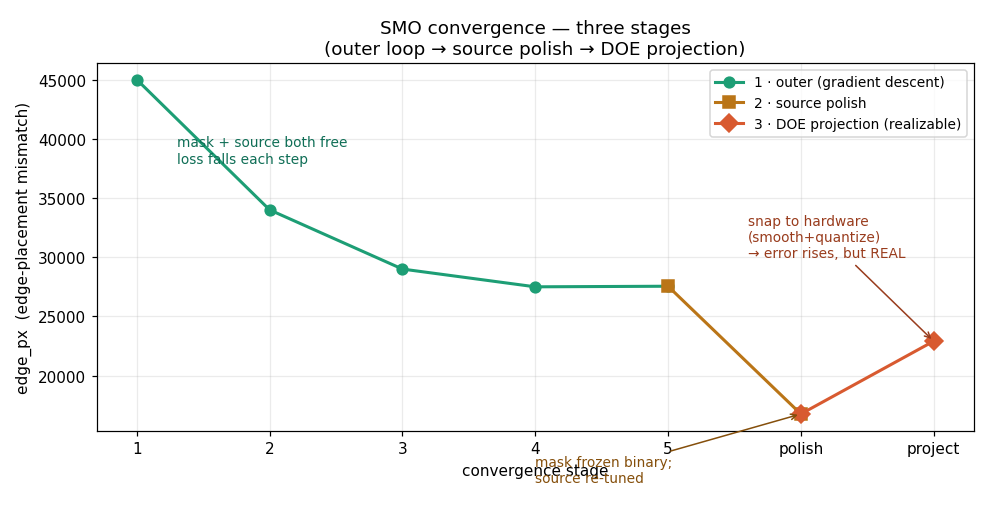

1. **outer  (the gradient-descent loop)**

> Each `outer` point is one full alternating SMO iteration: a **mask step** (fix source,
descend the mask = OPC/ILT) then a **source step** (fix mask, optimize the DOE weights).
Both mask and source are free. The plotted loss is `pattern_error` (MSE printed-vs-
target) and it should fall from iteration 1 toward N. **This is the true optimization**
— `everything after is manufacturability cleanup.`

2. **source polish  (`phase='polish'`)**
After the loop, the mask is frozen to a binary, MRC-cleaned pattern. That hard step nudges the image off the smooth optimum, so the **source polish** re-optimizes *only*
the DOE weights against the fixed mask, letting the illumination absorb some of the binarization damage. Expect a partial recovery of edge error.

3. DOE projection  (`phase='doe_project'`)
The final step makes the *source* buildable: k-space smoothing (kill spikes) then quantization to a few discrete levels (2 = binary aperture, more = mirror-array). This forces the ideal continuous DOE onto hardware-legal shapes, so edge error typically **rises** — the small, honest price of manufacturability. **This last point is the realizable result**: the print you'd actually get on a real tool.

**Reading the curve in one line**
- Descend to a good ideal solution (outer, error falls) → freeze and clean the mask,
- recover with a source-only polish (error dips back) →
- snap the source onto real hardware (error rises to its realizable value).

The green→amber→coral progression is
*ideal optimum → recovered → manufacturable*, and the final coral point is the number that actually matters.